# Lección 8.4 · Anotación genómica: de un ensamblaje a una lista de genes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-08-ensamblaje/8.4_anotacion_genomica.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 8 — Ensamblaje y anotación de genomas** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 1.2 (ORFs), 4.3 (HMM y Viterbi), 7.2 (mapeo) y 8.3 (SPAdes y QUAST) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Distinguir** la anotación **estructural** (dónde están los genes) de la **funcional** (qué hacen) y **describir**
   el flujo completo de anotación de un genoma.
2. **Calcular** con la ecuación geométrica cuán largo puede ser un ORF por azar y **reproducir** con datos reales de
   *E. coli* K-12 la separación entre ORFs reales y ORFs de un genoma barajado.
3. **Construir** un modelo de uso de codones **autoentrenado** y **puntuar** un fragmento en bits por codón
   (log-odds), y **generalizarlo** a cadenas de Márkov de **fase** de orden $m$.
4. **Evaluar** clasificadores de ADN codificante con **curvas ROC** y explicar por qué el orden del modelo importa
   sobre todo frente a los "genes sombra".
5. **Anotar** el ensamblaje *de novo* del clon del experimento de Lenski con **Prodigal** (vía `pyrodigal`) y con un
   predictor propio, y **medir** su sensibilidad, precisión y exactitud del codón de inicio frente a RefSeq.
6. **Programar** un pequeño **HMM generalizado** de exones e intrones con señales de empalme y decodificar con
   **Viterbi** el gen humano *TP53*.
7. **Enmascarar** regiones de baja complejidad y **explicar** cómo integran evidencia AUGUSTUS, BRAKER, Prokka y Bakta.

## 🗺️ Mapa de la clase

1. Qué significa anotar: estructura y función
2. Genes procariotas: marcos abiertos de lectura y el modelo geométrico
3. El sabor del ADN codificante: log-odds de codones
4. Periodicidad de tres y cadenas de Márkov de fase (🎬 animación)
5. De los modelos a los predictores: GeneMark, Glimmer y Prodigal
6. 🧪 Aplicación real: anotar el ensamblaje *de novo* del clon del LTEE
7. Genes eucariotas: HMM generalizados y Viterbi en *TP53* (🎬 animación)
8. Enmascarar repeticiones
9. Evidencia externa: RNA-seq, proteínas, AUGUSTUS y BRAKER
10. Anotación procariota automatizada: Prokka y Bakta, y el mapa del genoma
11. Ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección **«Anotación genómica»** del capítulo 8 del libro. Usamos su notación y sus
> ejemplos resueltos, con las mismas cifras: ecuaciones 8.16 (ORFs), 8.17 (log-odds), 8.18 (Márkov de fase) y 8.19
> (Viterbi).

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, json, math, shutil, subprocess, tempfile, time
import matplotlib as mpl
from collections import Counter, defaultdict
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Wedge, Circle

try:
    import pyrodigal
except ImportError:
    %pip install -q pyrodigal
    import pyrodigal

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (NCBI, UCSC);
    3) copia de respaldo en el repositorio de GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=90) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

def read_fasta(name):
    """Diccionario {identificador: secuencia en mayúsculas} de un FASTA comprimido del curso."""
    text = gzip.decompress(course_bytes(name)).decode()
    recs, cur = {}, None
    for line in text.splitlines():
        if line.startswith(">"):
            cur = line[1:].split()[0]
            recs[cur] = []
        elif cur is not None:
            recs[cur].append(line.strip().upper())
    return {k: "".join(v) for k, v in recs.items()}

def read_table(name):
    return pd.read_csv(io.BytesIO(course_bytes(name)), sep="\t", comment="#", compression="gzip")

COMP = str.maketrans("ACGTNacgtn", "TGCANtgcan")
def revcomp(s):
    return s.translate(COMP)[::-1]

# Codificación numérica: A=0, C=1, G=2, T=3 (cualquier otra letra → 0, no aparecen en estos datos)
LUT = np.zeros(256, dtype=np.int64)
for i, b in enumerate("ACGT"):
    LUT[ord(b)] = i
def encode(s):
    return LUT[np.frombuffer(s.encode(), dtype=np.uint8)]

STOPS = ("TAA", "TAG", "TGA")
print("pyrodigal", pyrodigal.__version__, "· listo para la Lección 8.4")

Entorno listo ✔  |  Colab: False
pyrodigal 3.7.1 · listo para la Lección 8.4


## 1. Qué significa anotar: estructura y función

Lea esta línea:

<p align="center"><code>ELQUEMUCHOABARCAPOCOAPRIETAYXQWZKTRBLAMPENCIAHJXV</code></p>

Sin que nadie le haya dicho dónde termina cada palabra, usted separa el refrán del principio ("el que mucho abarca,
poco aprieta") y reconoce que el final es ruido. Lo consigue porque **conoce el español**: sabe qué combinaciones de
letras son frecuentes (`QUE`, `CHO`), cuáles son casi imposibles (`XQWZ`) y qué forma tiene una palabra. Un programa
de predicción génica hace lo mismo con el ADN. No sabe biología; sabe **estadística**: aprende cómo "suena" el ADN
codificante de un organismo y busca los tramos que suenan así, respetando una **gramática** (un gen empieza con un
codón de inicio, no contiene codones de parada en su marco y, en eucariotas, sus intrones empiezan por `GT` y terminan
en `AG`).

En la lección 8.3 ensamblamos el genoma del clon del experimento de evolución a largo plazo de Lenski (LTEE,
SRR2584863): 93 contigs, 4,55 Mb, sin una sola etiqueta. Un laboratorio clínico que recibe un aislado de un brote
está exactamente en esa situación. **Anotar** es convertir ese texto sin puntuación en un recurso biológico, y
tiene dos niveles:

| Nivel | Pregunta | Ejemplo de resultado | Herramientas típicas |
|---|---|---|---|
| **Estructural** | ¿**Dónde** están los genes, sus exones, codones de inicio y parada, los ARNr y ARNt, las repeticiones? | `contig_1  4 518–5 447  +  CDS` | Prodigal, GeneMark, AUGUSTUS, RepeatMasker, barrnap, tRNAscan-SE |
| **Funcional** | ¿**Qué** hace cada gen? | "treonina sintasa", EC 4.2.3.1, GO:0009088 | BLAST/DIAMOND contra bases curadas, InterProScan, eggNOG |

El resultado se guarda en **GFF3** o **GenBank** (lección 2.1). La diferencia entre procariotas y
eucariotas está sobre todo en la predicción estructural: en *E. coli* alrededor del **88 %** del genoma codifica
proteínas, en genes continuos y apretados; en el genoma humano, poco más del 1 %, repartido en exones separados por
intrones y rodeado de un mar de repeticiones.

La siguiente figura reproduce el flujo típico de anotación (figura 8.11 del libro).

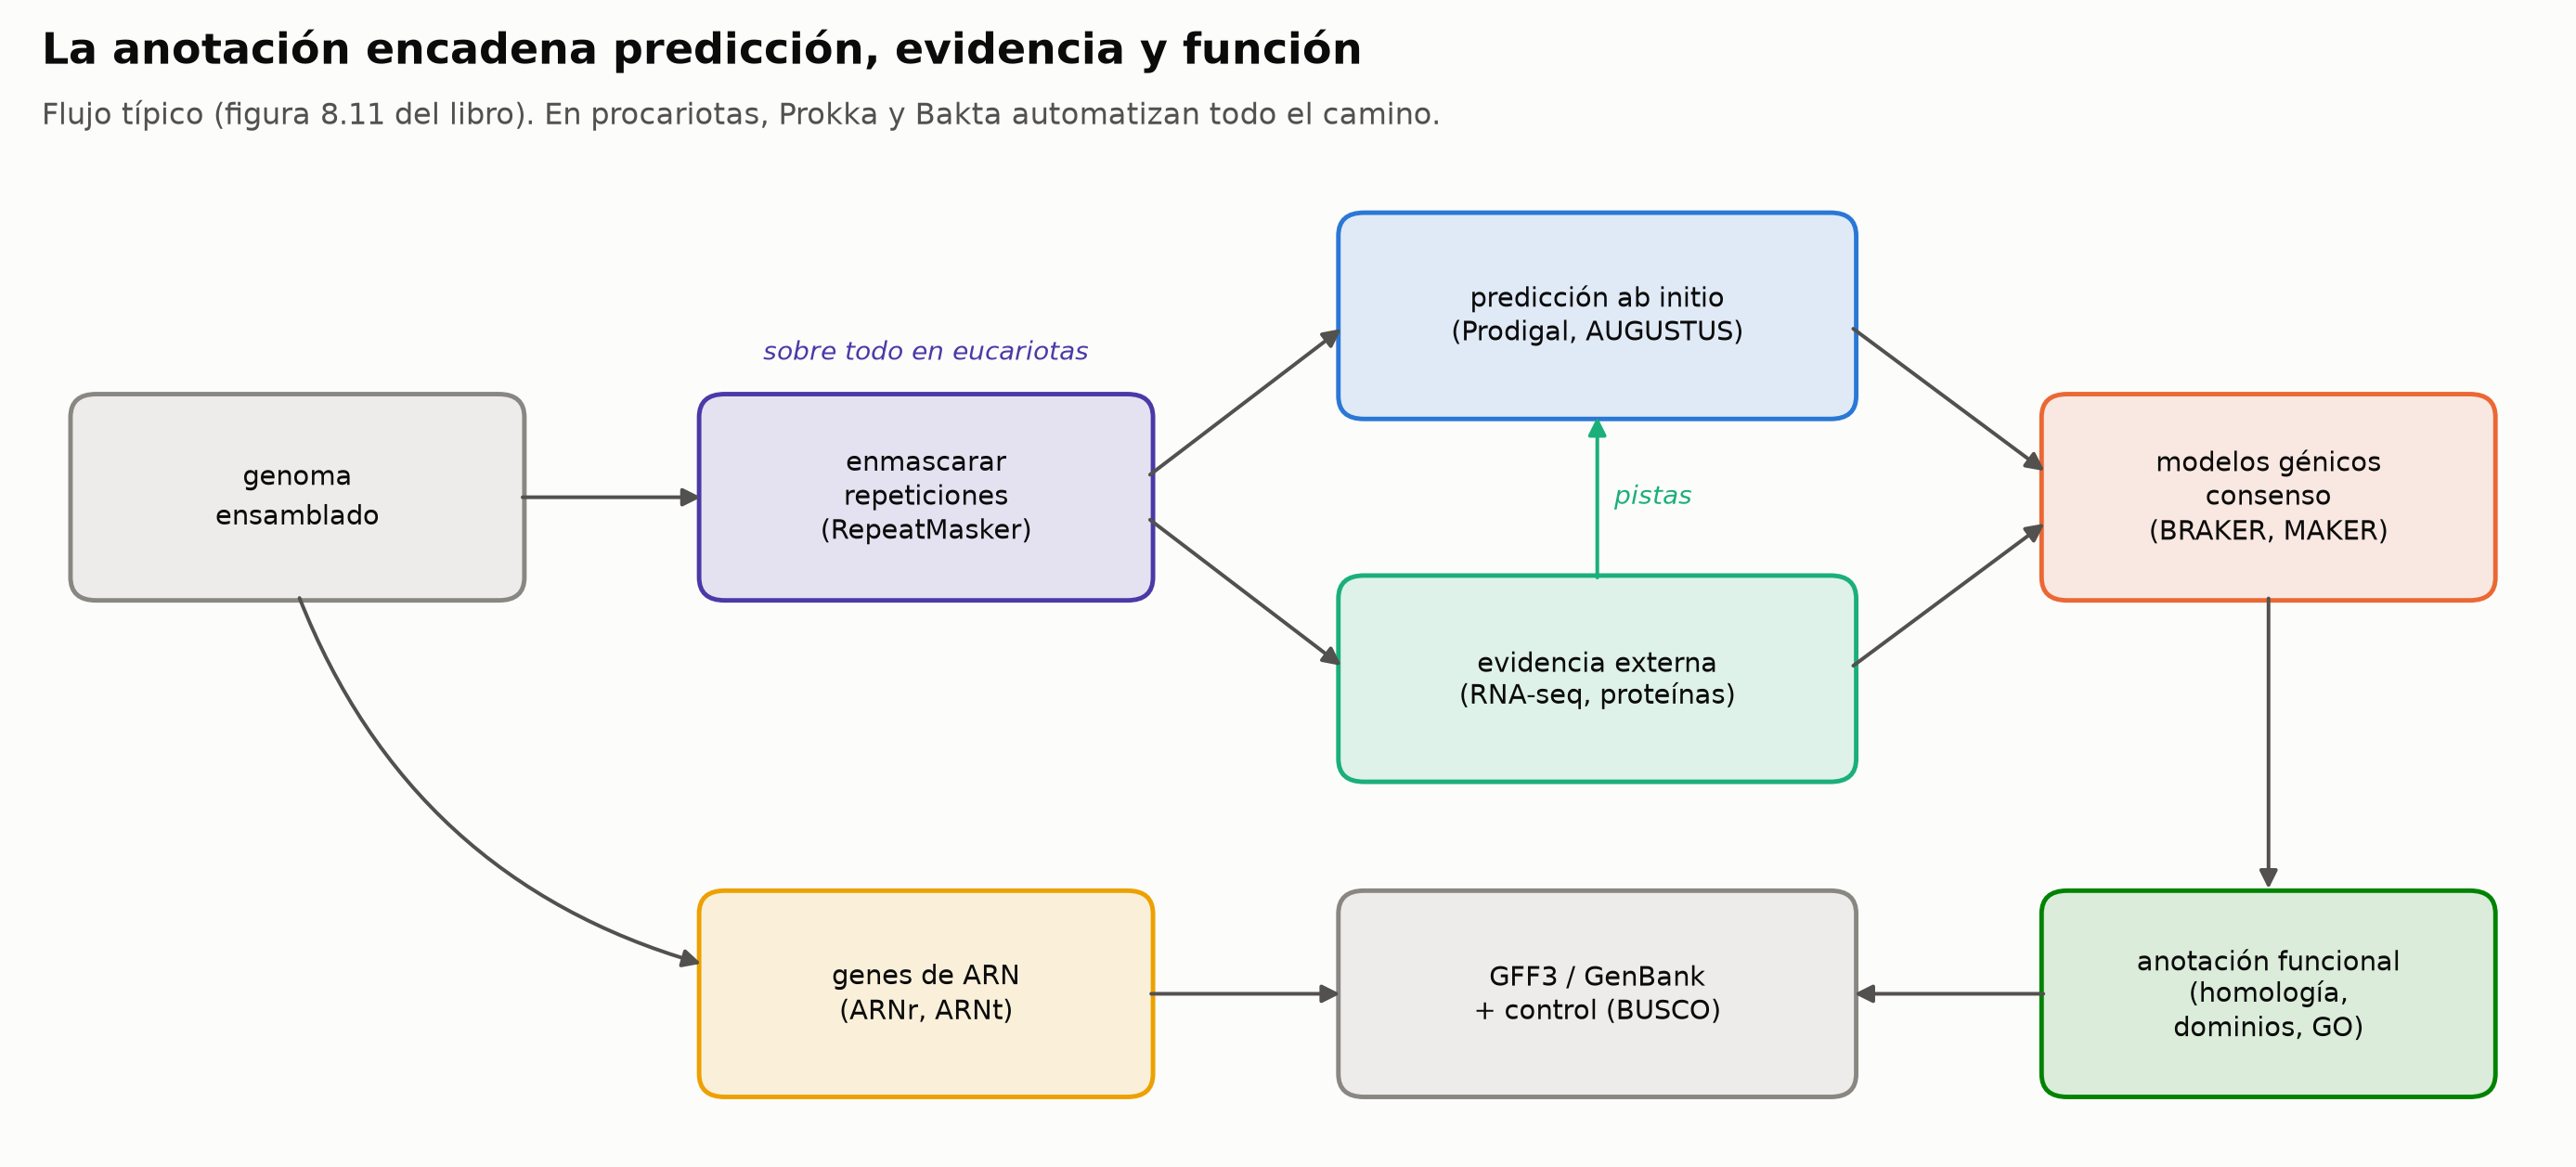

In [2]:
fig, ax = plt.subplots(figsize=(12.5, 5.6))
ax.set_xlim(-1.3, 10.6); ax.set_ylim(-3.4, 2.5); ax.axis("off")

def box(x, y, text, color, w=2.05, h=1.0):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc=mpl.colors.to_rgba(color, 0.13), ec=color, lw=1.6))
    ax.text(x, y, text, ha="center", va="center", fontsize=9.6, color=ec.INK, linespacing=1.25)

def arrow(p, q, style="-|>", rad=0.0, color=ec.INK_2):
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle=style, mutation_scale=13, color=color, lw=1.3,
                                 connectionstyle=f"arc3,rad={rad}", shrinkA=2, shrinkB=2))

box(0, 0, "genoma\nensamblado", ec.MUTED)
box(2.95, 0, "enmascarar\nrepeticiones\n(RepeatMasker)", ec.VIOLET)
box(6.1, 0.95, "predicción ab initio\n(Prodigal, AUGUSTUS)", ec.BLUE, w=2.35)
box(6.1, -0.95, "evidencia externa\n(RNA-seq, proteínas)", ec.AQUA, w=2.35)
box(9.25, 0, "modelos génicos\nconsenso\n(BRAKER, MAKER)", ec.ORANGE)
box(9.25, -2.6, "anotación funcional\n(homología,\ndominios, GO)", ec.GREEN)
box(6.1, -2.6, "GFF3 / GenBank\n+ control (BUSCO)", ec.MUTED, w=2.35)
box(2.95, -2.6, "genes de ARN\n(ARNr, ARNt)", ec.YELLOW)
arrow((1.03, 0), (1.92, 0))
arrow((3.98, 0.1), (4.92, 0.9)); arrow((3.98, -0.1), (4.92, -0.9))
arrow((7.28, 0.9), (8.22, 0.12)); arrow((7.28, -0.9), (8.22, -0.12))
arrow((6.1, -0.45), (6.1, 0.45), color=ec.AQUA)
ax.text(6.18, 0.0, "pistas", fontsize=9, color=ec.AQUA, va="center", style="italic")
arrow((9.25, -0.5), (9.25, -2.08)); arrow((8.22, -2.6), (7.28, -2.6)); arrow((3.98, -2.6), (4.92, -2.6))
arrow((0, -0.5), (1.92, -2.45), rad=0.25)
ax.text(2.95, 0.72, "sobre todo en eucariotas", ha="center", fontsize=9, color=ec.VIOLET, style="italic")
ax.text(-1.2, 2.45, "La anotación encadena predicción, evidencia y función", fontsize=15, fontweight="bold",
        color=ec.INK, va="top")
ax.text(-1.2, 2.08, "Flujo típico (figura 8.11 del libro). En procariotas, Prokka y Bakta automatizan todo el camino.",
        fontsize=10.5, color=ec.INK_2, va="top")
plt.show()

> 🔎 **Qué observamos.** El flujo tiene dos ramas que convergen. La rama superior busca **dónde** están los genes
> (primero se enmascaran las repeticiones, para que una transposasa no se tome por un gen del huésped; después se
> combinan predicción estadística y evidencia experimental). La rama inferior busca los genes de **ARN** con modelos
> propios. Al final, la anotación **funcional** asigna nombres por homología y el conjunto se valida.

En esta clase recorremos el flujo de izquierda a derecha, pero empezamos por el corazón del problema: **reconocer
un gen en una secuencia desnuda**.

---

## 2. Genes procariotas: marcos abiertos de lectura

En la lección 1.2 construimos un buscador de ORFs y lo aplicamos a *Mycoplasma genitalium*. Recordemos la definición
del libro (definición 8.5):

> **Marco abierto de lectura (ORF).** Tramo de ADN que, leído en uno de los **seis** marcos posibles (tres por
> hebra), comienza en un codón de inicio (`ATG`, y en bacterias también `GTG` o `TTG`) y continúa sin codones de
> parada (`TAA`, `TAG`, `TGA`) hasta el primero que aparece en ese marco.

Todo gen bacteriano es un ORF, pero no todo ORF es un gen: en cualquier secuencia aparecen ORFs **por azar**. La
pregunta clave es **cuán largos** pueden ser esos ORFs casuales.

### Un cálculo a mano

Piense en una ruleta con 64 casillas, una por codón, de las cuales **3** son "parada". Si todas las casillas fueran
igual de probables, cada giro caería en parada con probabilidad $p = 3/64 = 0{,}0469$. ¿Cuál es la probabilidad de
girar **100 veces seguidas sin** caer en parada? Cada giro "sobrevive" con probabilidad $1-p$, y los giros son
independientes:

$$
(1 - 0{,}0469)^{100} = 0{,}9531^{100} \approx e^{100 \ln 0{,}9531} = e^{-4{,}80} \approx 0{,}0082 .
$$

Menos de 1 en 100. Pero el genoma no tiene bases equiprobables: *E. coli* tiene 50,8 % de GC, y los codones de parada
son ricos en A y T. La probabilidad correcta suma la de los tres codones de parada usando las frecuencias reales de
las bases.

### La ecuación 8.16 del libro

$$
\Pr(\text{ORF aleatorio} \ge n \text{ codones}) = (1-p)^{n},
\qquad
p = \sum_{xyz\,\in\,\{\texttt{TAA},\texttt{TAG},\texttt{TGA}\}} f_x\, f_y\, f_z .
$$

| Símbolo | Significado |
|---|---|
| $p$ | probabilidad de que un codón al azar sea de parada, dada la composición de bases |
| $f_x$ | frecuencia de la base $x$ en el genoma |
| $n$ | longitud del ORF en codones |

Es una **ley geométrica**: la misma que describe cuántas veces hay que lanzar un dado hasta sacar un seis. Calculémosla
con el genoma de *E. coli* K-12 MG1655, la cepa de laboratorio de referencia (4 641 652 pb).

> 🤔 **Antes de ejecutar, prediga:** con 50,8 % de GC, ¿$p$ será mayor o menor que $3/64 = 0{,}0469$?

In [3]:
NCBI = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={}&rettype=fasta&retmode=text"
eco = list(read_fasta("NC_000913.3.fasta.gz").values())[0]
G = len(eco)
freq = {b: eco.count(b) / G for b in "ACGT"}
p_stop = sum(freq[a] * freq[b] * freq[c] for a, b, c in STOPS)

print(f"E. coli K-12 MG1655: {G:,} pb · GC = {freq['G'] + freq['C']:.4f}")
print("Frecuencias de bases:", {b: round(f, 4) for b, f in freq.items()})
for c in STOPS:
    print(f"  P({c}) = {freq[c[0]]:.4f} × {freq[c[1]]:.4f} × {freq[c[2]]:.4f} = {freq[c[0]]*freq[c[1]]*freq[c[2]]:.5f}")
print(f"p = P(parada | codón al azar) = {p_stop:.4f}  → un codón de parada cada {1/p_stop:.1f} codones")
for n in (100, 300):
    print(f"P(ORF aleatorio ≥ {n} codones) = (1 − p)^{n} = {(1 - p_stop)**n:.2e}")

E. coli K-12 MG1655: 4,641,652 pb · GC = 0.5079
Frecuencias de bases: {'A': 0.2462, 'C': 0.2542, 'G': 0.2537, 'T': 0.2459}
  P(TAA) = 0.2459 × 0.2462 × 0.2462 = 0.01490
  P(TAG) = 0.2459 × 0.2462 × 0.2537 = 0.01536
  P(TGA) = 0.2459 × 0.2537 × 0.2462 = 0.01536
p = P(parada | codón al azar) = 0.0456  → un codón de parada cada 21.9 codones
P(ORF aleatorio ≥ 100 codones) = (1 − p)^100 = 9.38e-03
P(ORF aleatorio ≥ 300 codones) = (1 − p)^300 = 8.25e-07


> 🔎 **Qué observamos.** $p = 0{,}0456$, algo **menor** que $3/64$: como el genoma es un poco más rico en G+C que en
> A+T, los codones de parada (dos A/T de cada tres bases) son un poco más raros. Un codón de parada cada 22 en
> promedio. La probabilidad de un ORF casual de 100 codones es 0,0094; la de uno de 300, $8\times10^{-7}$.

### ORFs reales frente a un genoma barajado

El modelo geométrico es una predicción; pongámosla a prueba. **Barajamos** el genoma base a base (misma composición,
cero estructura) y contamos los ORFs en ambos. Para que sea rápido, el buscador está vectorizado con numpy: en lugar
de recorrer codón a codón (como en la lección 1.2), marca todas las posiciones de parada y de `ATG` a la vez y, para
cada parada, busca con `searchsorted` el primer `ATG` después de la parada anterior del mismo marco. Así obtenemos,
como en el libro, **el ORF más largo que termina en cada codón de parada** (de `ATG` a parada, seis marcos, $\ge 30$
codones).

In [4]:
STOP_CODES = [3*16 + 0*4 + 0, 3*16 + 0*4 + 2, 3*16 + 2*4 + 0]      # TAA, TAG, TGA en base 4
ATG_CODE = 0*16 + 3*4 + 2

def find_orfs(seq, min_codons=30):
    """ORFs de ATG a parada en los 6 marcos (el más largo por codón de parada).
    Devuelve una tabla con hebra, inicio y fin (0-based, semiabierto, en coordenadas de esa hebra)
    y longitud en codones (sin contar la parada)."""
    rows = []
    for strand, s in ((1, seq), (-1, revcomp(seq))):
        x = encode(s)
        n = len(x) - 2
        code = x[:n] * 16 + x[1:n + 1] * 4 + x[2:n + 2]       # cada posición → número de su codón (0–63)
        is_stop, is_atg = np.isin(code, STOP_CODES), code == ATG_CODE
        for f in range(3):
            st = np.flatnonzero(is_stop[f::3])                  # índices de codón (en ese marco) de las paradas
            at = np.flatnonzero(is_atg[f::3])
            prev = np.r_[-1, st[:-1]]                           # parada anterior del mismo marco
            j = np.searchsorted(at, prev + 1)                   # primer ATG tras la parada anterior
            first = np.where(j < len(at), at[np.minimum(j, len(at) - 1)], 1 << 60)
            ok = (first < st) & (st - first >= min_codons)
            for a, b in zip(first[ok], st[ok]):
                rows.append((strand, f + 3 * a, f + 3 * b, b - a))
    return pd.DataFrame(rows, columns=["strand", "start", "end", "codons"])

t0 = time.time()
orf_real = find_orfs(eco)
rng = np.random.default_rng(8)
shuffled = np.frombuffer(eco.encode(), dtype=np.uint8).copy()
rng.shuffle(shuffled)
shuffled = shuffled.tobytes().decode()
orf_shuf = find_orfs(shuffled)
print(f"(tiempo: {time.time() - t0:.1f} s)")

summary = pd.DataFrame({"umbral (codones)": [30, 100, 200, 300, 500]})
summary["ORFs reales"] = [int((orf_real.codons >= t).sum()) for t in summary["umbral (codones)"]]
summary["ORFs barajados"] = [int((orf_shuf.codons >= t).sum()) for t in summary["umbral (codones)"]]
summary["esperados (≈ barajados₃₀ × (1−p)^(n−30))"] = [round(len(orf_shuf) * (1 - p_stop) ** (t - 30), 1)
                                                      for t in summary["umbral (codones)"]]
print(f"ORF más largo: real = {orf_real.codons.max()} codones · barajado = {orf_shuf.codons.max()} codones")
summary

(tiempo: 0.3 s)
ORF más largo: real = 2367 codones · barajado = 218 codones


,umbral (codones),ORFs reales,ORFs barajados,esperados (≈ barajados₃₀ × (1−p)^(n−30))
0,30,26147,27366,27366.0
1,100,5983,1001,1041.8
2,200,3175,4,9.8
3,300,2030,0,0.1
4,500,604,0,0.0


El número **real** (5 983 ORFs de al menos 100 codones, 2 030 de al menos 300) coincide exactamente con el libro,
porque no depende del azar. El número del genoma **barajado** sí depende de la semilla: el libro obtuvo 1 045 ORFs
de $\ge 100$ codones. ¿Es nuestra cifra "distinta"? Repitamos el barajado con varias semillas para ver cuánto varía
por puro azar.

In [5]:
spread = []
for seed in range(10):
    arr = np.frombuffer(eco.encode(), dtype=np.uint8).copy()
    np.random.default_rng(seed).shuffle(arr)
    lens = find_orfs(arr.tobytes().decode()).codons
    spread.append((seed, int((lens >= 100).sum()), int((lens >= 200).sum()), int(lens.max())))
spread = pd.DataFrame(spread, columns=["semilla", "≥100 codones", "≥200 codones", "máximo"])
print(f"≥100 codones en 10 barajados: media {spread['≥100 codones'].mean():.0f}, "
      f"rango {spread['≥100 codones'].min()}–{spread['≥100 codones'].max()} (libro: 1 045)")
spread.T

≥100 codones en 10 barajados: media 1055, rango 1001–1105 (libro: 1 045)


,0,1,2,3,4,5,6,7,8,9
semilla,0,1,2,3,4,5,6,7,8,9
≥100 codones,1074,1068,1026,1051,1082,1075,1105,1036,1001,1031
≥200 codones,19,14,9,7,13,10,13,13,4,14
máximo,248,252,254,265,289,245,271,230,218,281


> 🔎 **Qué observamos.** Los barajados dan entre unos 1 000 y 1 100 ORFs de $\ge 100$ codones: el 1 045 del libro está
> dentro de esa nube. También el ORF barajado más largo depende de la semilla (de 218 a 289 codones en la tabla; el
> «unos 250» del libro es uno de esos valores). Ninguna semilla produce un ORF de 300 codones; el genoma real tiene **2 030**. Los ORFs muy
> largos son genes casi con certeza.

Veamos las dos distribuciones completas junto a la ley geométrica (figura 8.12 del libro).

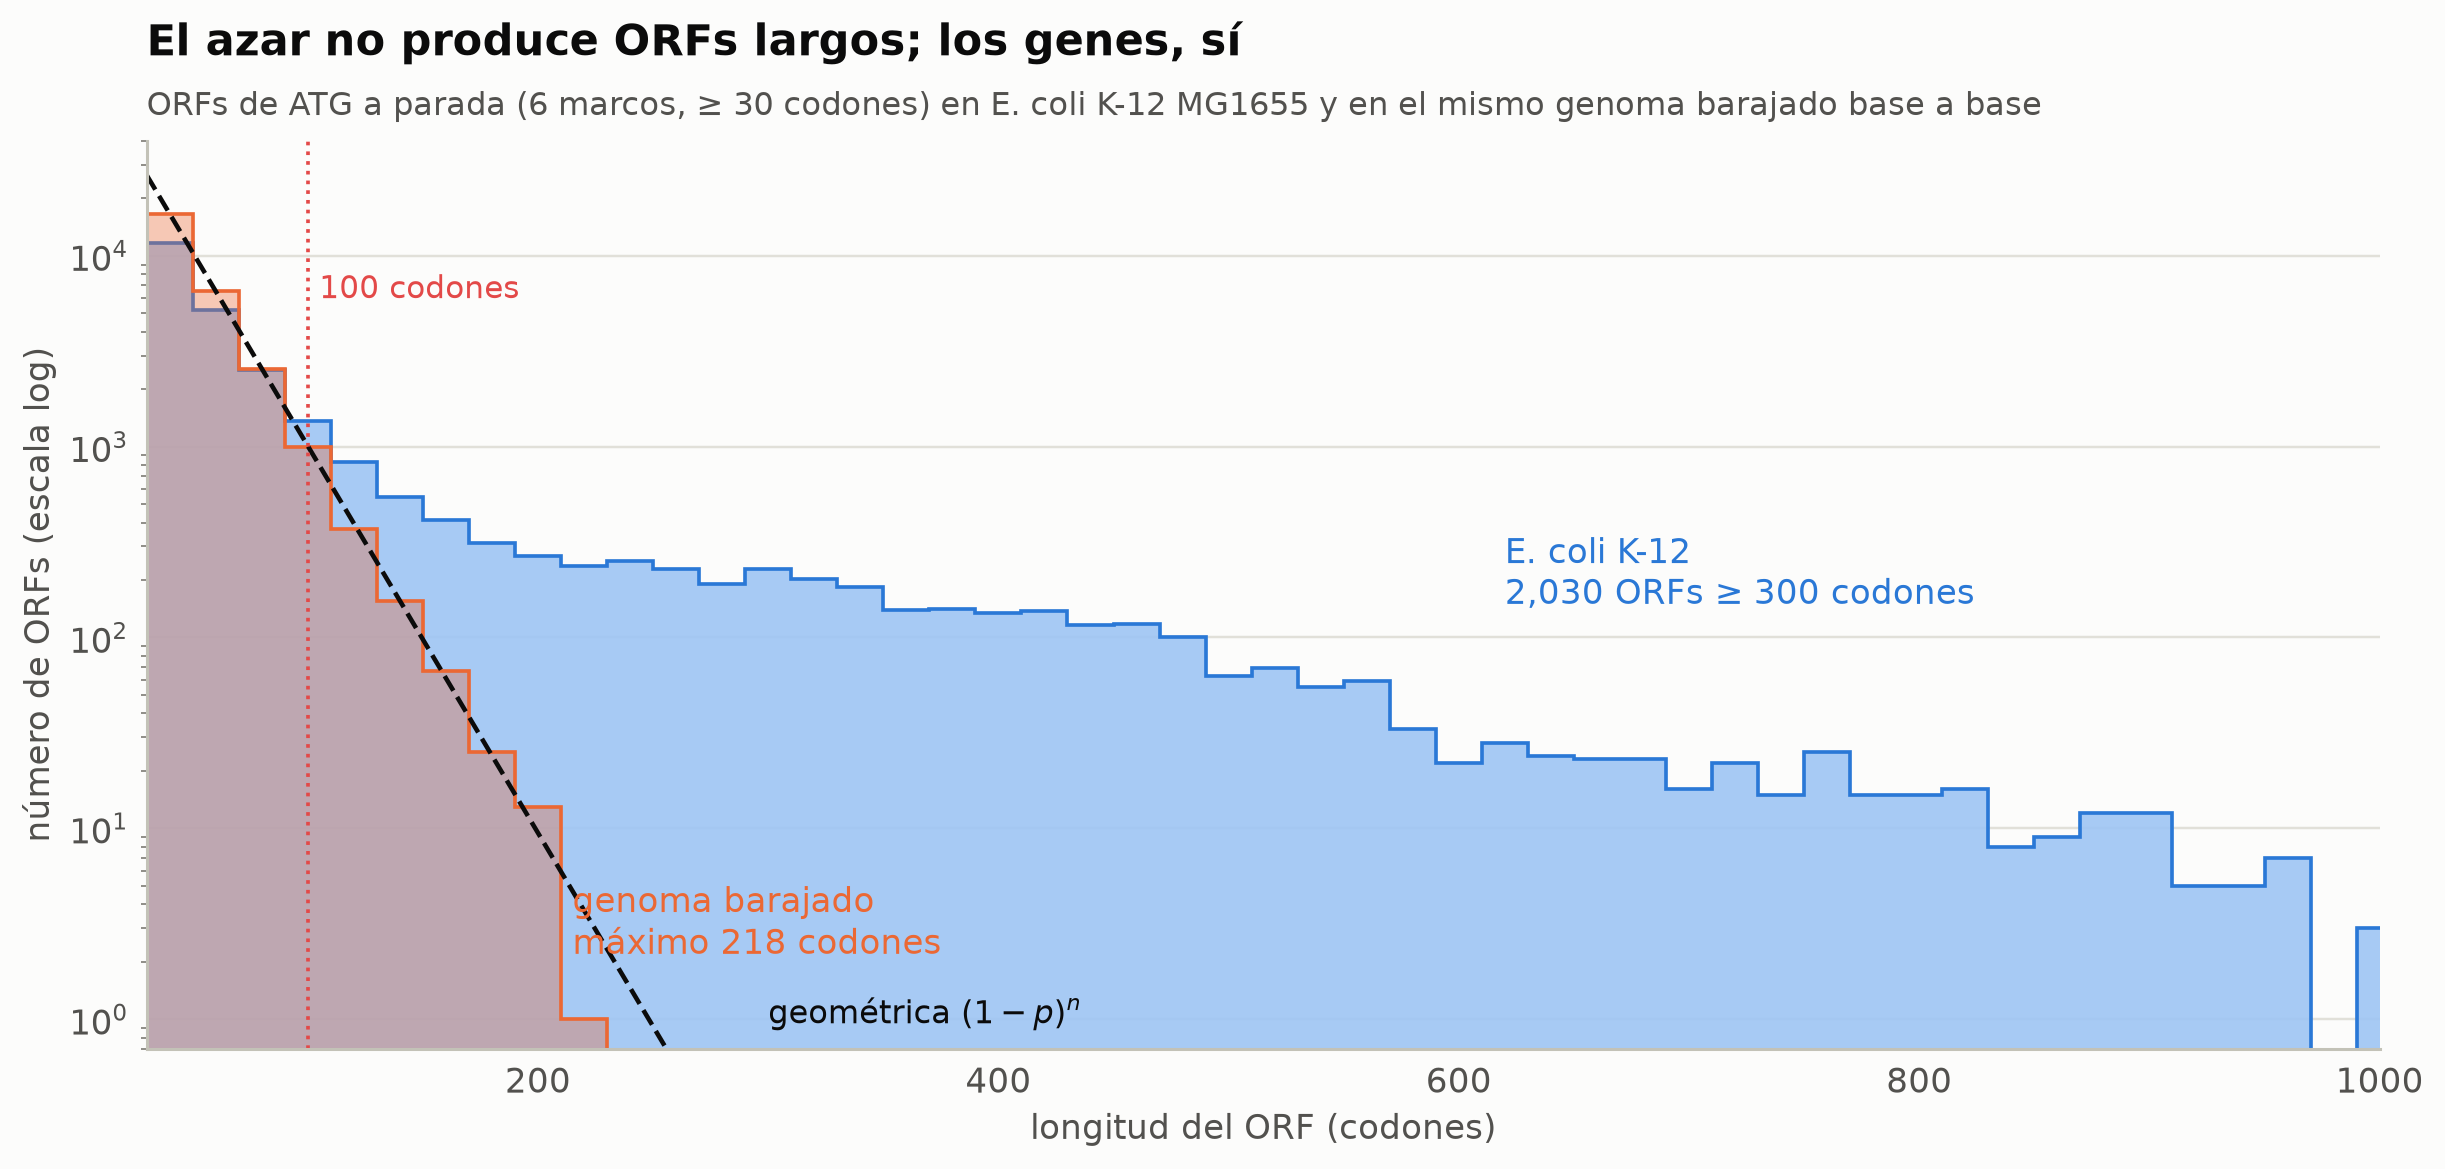

In [6]:
bins = np.arange(30, 1030, 20)
hr, _ = np.histogram(orf_real.codons, bins)
hb, _ = np.histogram(orf_shuf.codons, bins)
mid = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.stairs(np.maximum(hr, 0.5), bins, fill=True, color=ec.SEQ_BLUE[2], alpha=0.9)
ax.stairs(np.maximum(hr, 0.5), bins, color=ec.BLUE, lw=1.2)
ax.stairs(np.maximum(hb, 0.5), bins, fill=True, color=ec.ORANGE, alpha=0.35)
ax.stairs(np.maximum(hb, 0.5), bins, color=ec.ORANGE, lw=1.2)
xt = np.arange(30, 400)
ax.plot(xt, hb[0] * (1 - p_stop) ** (xt - 40), color=ec.INK, ls="--", lw=1.5)
ax.axvline(100, color=ec.RED, ls=":", lw=1.2)
ax.set_yscale("log"); ax.set_ylim(0.7, 40000); ax.set_xlim(30, 1000)
ax.set_xlabel("longitud del ORF (codones)"); ax.set_ylabel("número de ORFs (escala log)")
ax.text(105, 6000, "100 codones", color=ec.RED, fontsize=10)
ax.text(620, 150, f"E. coli K-12\n{(orf_real.codons >= 300).sum():,} ORFs ≥ 300 codones", color=ec.BLUE, fontsize=11)
ax.text(215, 2.2, f"genoma barajado\nmáximo {orf_shuf.codons.max()} codones", color=ec.ORANGE, fontsize=11)
ax.text(300, 0.95, "geométrica $(1-p)^n$", color=ec.INK, fontsize=10.5)
ec.title(ax, "El azar no produce ORFs largos; los genes, sí",
         "ORFs de ATG a parada (6 marcos, ≥ 30 codones) en E. coli K-12 MG1655 y en el mismo genoma barajado base a base")
plt.show()

> 🔎 **Qué observamos.** El genoma barajado (naranja) cae en línea recta en escala logarítmica: es la ley geométrica
> de la ecuación 8.16 (línea discontinua). El genoma real (azul) coincide con él para ORFs cortos, pero despliega una
> **cola de miles de ORFs largos**: los genes. Por debajo de unos 100 codones las dos curvas se confunden: allí la
> longitud ya no basta y hace falta mirar **el contenido** de la secuencia.

> ✅ **Compruebe su comprensión.** En un genoma con 70 % de GC (como *Streptomyces*), ¿serán los ORFs casuales más
> largos o más cortos que en *E. coli*? Calcule $p$ suponiendo $f_G=f_C=0{,}35$ y $f_A=f_T=0{,}15$.
> *(Respuesta: $p = \underbrace{0{,}15^3}_{\texttt{TAA}} + \underbrace{2 \times 0{,}15^2 \times 0{,}35}_{\texttt{TAG},\ \texttt{TGA}}
> = 0{,}0034 + 0{,}0158 \approx 0{,}0191$, un 42 % del valor de *E. coli* (0,0456): los ORFs casuales son unas 2,4 veces
> más largos, y por eso en genomas ricos en GC los predictores confunden más ORFs espurios con genes.)*

---

## 3. El sabor del ADN codificante: log-odds de codones

### La intuición: reconocer un idioma por sus letras

Si le muestran un párrafo lleno de `W`, `K` y `TH`, usted sospecha que es inglés; si abundan la `Ñ` y los finales en
`-CIÓN`, español. Ninguna letra por sí sola decide, pero cada una aporta un poco de **evidencia**, y la evidencia se
**suma**. Los genes tienen su propio "acento": cada especie prefiere unos codones y evita otros (el **sesgo de uso de
codones**), porque sus ARNt más abundantes leen mejor esos codones.

La forma de sumar evidencia es la **razón de verosimilitudes** en logaritmos, la misma lógica de las matrices de
sustitución de la lección 3.3: para cada codón comparamos cuán probable es en genes frente a cuán probable es por azar.

### Ejemplo a mano con dos codones

En los genes largos de *E. coli* el codón `CTG` aparece con frecuencia $P_{\text{cod}}=0{,}0539$, mientras que por la
composición de bases ($f_C f_T f_G = 0{,}254\times0{,}246\times0{,}254$) esperaríamos verlo con $P_{\text{nc}}=0{,}0159$.
El codón aporta $\log_2(0{,}0539/0{,}0159)=\log_2 3{,}39 = +1{,}76$ bits a favor de "codificante". El codón `AGG`, con
$P_{\text{cod}}=0{,}0011$ y $P_{\text{nc}}=0{,}0158$, aporta $\log_2(0{,}0011/0{,}0158) \approx -3{,}8$ bits en contra. Un
fragmento `CTG AGG` suma $1{,}76 - 3{,}79 = -2{,}03$ bits, es decir, $-1{,}01$ bits por codón: el `AGG`, rarísimo en
genes de *E. coli*, pesa más. (Enseguida calcularemos estas frecuencias con el genoma.)

### Definición 8.6 del libro: puntuación log-odds de codones

$$
S(x) = \frac{1}{n}\sum_{i=1}^{n}\log_2\frac{P_{\text{cod}}(c_i)}{P_{\text{nc}}(c_i)}\quad\text{(bits por codón)},
\qquad P_{\text{nc}}(c) = f_{c_1} f_{c_2} f_{c_3}.
$$

| Símbolo | Significado |
|---|---|
| $x = c_1 c_2 \cdots c_n$ | el ORF, leído como $n$ codones |
| $P_{\text{cod}}(c)$ | probabilidad del codón $c$ en regiones codificantes de la especie |
| $P_{\text{nc}}(c)$ | probabilidad del mismo trinucleótido bajo el modelo nulo de bases independientes |
| $f_{c_1}, f_{c_2}, f_{c_3}$ | frecuencias en el genoma de la primera, segunda y tercera base del codón |
| $S(x)$ | evidencia media, en bits por codón, de que $x$ es codificante ($>0$: suena a gen) |

### Autoentrenamiento: aprender de los ORFs que no pueden ser azar

¿De dónde salen las frecuencias $P_{\text{cod}}$ en un genoma recién ensamblado, **sin genes conocidos**? De la
figura anterior: los ORFs de **más de 300 codones** son genes casi con certeza (el azar no produce ninguno), así que
podemos **autoentrenar** el modelo con ellos. Contamos sus codones (sin la parada) y sumamos 1 a cada conteo
(pseudocuenta) para que ningún codón tenga probabilidad cero.

In [7]:
CODONS = [a + b + c for a in "TCAG" for b in "TCAG" for c in "TCAG"]   # orden de la tabla del código genético

def orf_seq(seq_by_strand, row):
    return seq_by_strand[row.strand][row.start:row.end]

eco_strands = {1: eco, -1: revcomp(eco)}
train = orf_real[orf_real.codons >= 300]
counts = Counter()
for r in train.itertuples():
    s = orf_seq(eco_strands, r)
    counts.update(s[i:i + 3] for i in range(0, len(s), 3))
total = sum(counts.values())
P_cod = {c: (counts[c] + 1) / (total + 64) for c in CODONS}
P_nc = {c: freq[c[0]] * freq[c[1]] * freq[c[2]] for c in CODONS}
llr = {c: math.log2(P_cod[c] / P_nc[c]) for c in CODONS}
print(f"Entrenamiento: {len(train):,} ORFs ≥ 300 codones · {total:,} codones")

from Bio.Data import CodonTable
AA = CodonTable.unambiguous_dna_by_id[11].forward_table
table = pd.DataFrame({"codón": CODONS, "aa": [AA.get(c, "*") for c in CODONS],
                      "P_cod": [P_cod[c] for c in CODONS], "P_nc": [P_nc[c] for c in CODONS],
                      "log-odds (bits)": [llr[c] for c in CODONS]}).round(4)
no_stop = table[table.aa != "*"].sort_values("log-odds (bits)", ascending=False)
pd.concat([no_stop.head(6).reset_index(drop=True), no_stop.tail(6).iloc[::-1].reset_index(drop=True)],
          axis=1, keys=["más favorecidos", "más desfavorecidos"])

Entrenamiento: 2,030 ORFs ≥ 300 codones · 973,715 codones


más favorecidos                                    más desfavorecidos     \
            codón aa   P_cod    P_nc log-odds (bits)              codón aa   
0             CTG  L  0.0539  0.0159          1.7639                AGG  R   
1             GAA  E  0.0384  0.0154          1.3187                AGA  R   
2             AAA  K  0.0319  0.0149          1.0943                CGA  R   
3             GCG  A  0.0347  0.0164          1.0844                CTA  L   
4             GAT  D  0.0322  0.0154          1.0693                ATA  I   
5             ATT  I  0.0293  0.0149          0.9756                TGT  C   

                                   
    P_cod    P_nc log-odds (bits)  
0  0.0011  0.0158         -3.7851  
1  0.0022  0.0154         -2.8311  
2  0.0033  0.0159         -2.2577  
3  0.0037  0.0154         -2.0726  
4  0.0041  0.0149         -1.8600  
5  0.0046  0.0153         -1.7473

> 🔎 **Qué observamos.** Los mismos valores del libro: `CTG` (+1,76 bits, el codón de leucina preferido por
> *E. coli*), `GAA` (+1,32) y `AAA` (+1,09) arriba; los codones de arginina raros `AGG` (−3,79) y `AGA` (−2,83) abajo.
> Casi un millón de codones de entrenamiento salen de 2 030 ORFs que **nadie anotó**: el genoma se describe a sí mismo.

Veamos los 64 valores ordenados como la tabla del código genético, que es donde el sesgo se entiende mejor: los
codones sinónimos (misma fila de aminoácido) no son intercambiables.

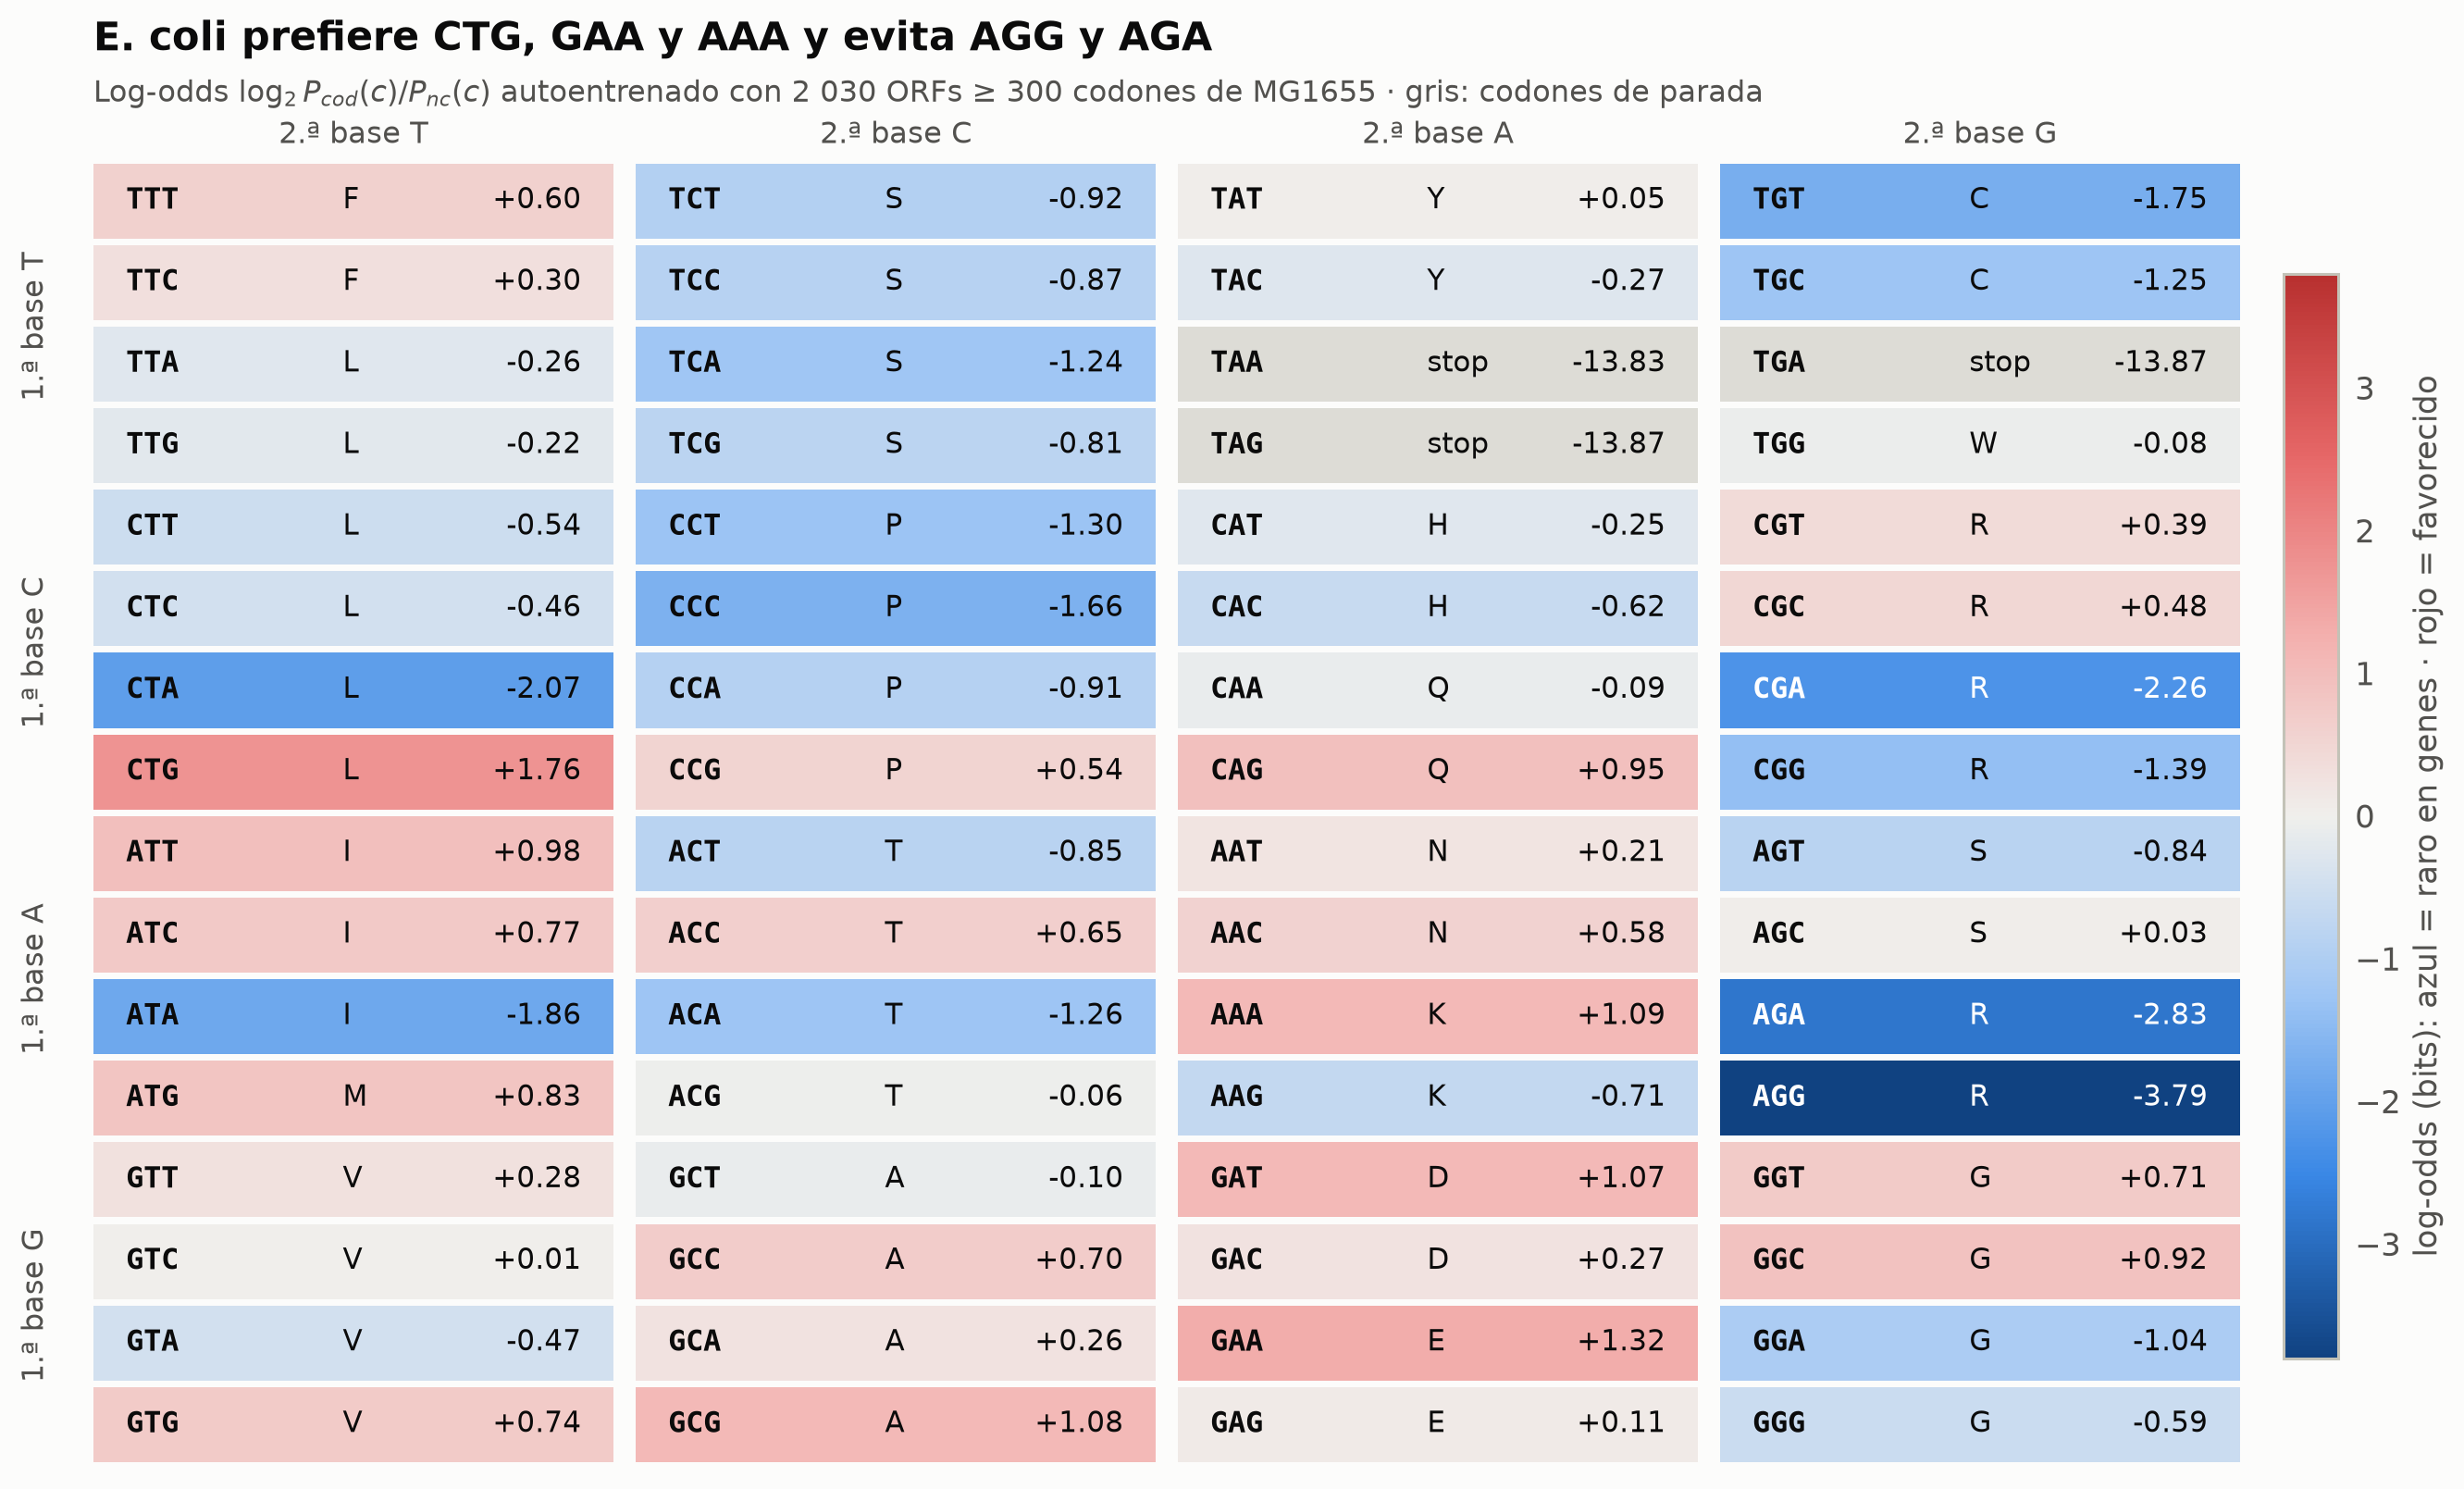

In [8]:
fig, ax = plt.subplots(figsize=(12, 7.2))
vmax = 3.8
norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
for i1, b1 in enumerate("TCAG"):
    for i2, b2 in enumerate("TCAG"):
        for i3, b3 in enumerate("TCAG"):
            c = b1 + b2 + b3
            row, col = i1 * 4 + i3, i2
            color = ec.CMAP_DIV(norm(llr[c])) if AA.get(c) else "#dddcd6"
            ax.add_patch(Rectangle((col, row), 0.96, 0.92, fc=color, ec="none"))
            txt_col = "white" if abs(llr[c]) > 2.2 and AA.get(c) else ec.INK
            ax.text(col + 0.06, row + 0.46, c, fontsize=10.5, family="monospace", va="center", color=txt_col,
                    fontweight="bold")
            ax.text(col + 0.46, row + 0.46, AA.get(c, "stop"), fontsize=10, va="center", color=txt_col)
            ax.text(col + 0.9, row + 0.46, f"{llr[c]:+.2f}", fontsize=10, va="center", ha="right", color=txt_col)
ax.set_xlim(0, 4); ax.set_ylim(16, 0); ax.axis("off")
for k in range(4):
    ax.text(k + 0.48, -0.25, f"2.ª base {'TCAG'[k]}", ha="center", fontsize=10.5, color=ec.INK_2)
    ax.text(-0.08, k * 4 + 2, f"1.ª base {'TCAG'[k]}", ha="right", va="center", fontsize=10.5, color=ec.INK_2,
            rotation=90)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=ec.CMAP_DIV)
cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
cb.set_label("log-odds (bits): azul = raro en genes · rojo = favorecido")
ax.set_title("E. coli prefiere CTG, GAA y AAA y evita AGG y AGA", loc="left", pad=40)
ax.text(0, -0.75, "Log-odds $\\log_2 P_{cod}(c)/P_{nc}(c)$ autoentrenado con 2 030 ORFs ≥ 300 codones de MG1655 · "
        "gris: codones de parada", fontsize=10.5, color=ec.INK_2)
plt.show()

> 🔎 **Qué observamos.** Entre los sinónimos hay contrastes fuertes: las seis argininas van de `CGT`/`CGC`
> (favorecidas) a `AGG`/`AGA` (las más raras del genoma), y las seis leucinas, de `CTG` (+1,76) a `CTA` (−2,07). No es
> la química del aminoácido lo que cuenta aquí, sino la maquinaria de traducción de *E. coli*.

### Ejemplo 8.3 del libro: puntuar un fragmento

Con este modelo, el fragmento `ATG AAA CGC ATT AGC ACC ACC ATT` recibe

$$
S = \tfrac{1}{8}\,(0{,}83+1{,}09+0{,}48+0{,}98+0{,}03+0{,}65+0{,}65+0{,}98) = \tfrac{5{,}69}{8} = 0{,}71\ \text{bits/codón},
$$

un valor claramente codificante. Compruébelo con el código:

In [9]:
def codon_score(s):
    """Ecuación 8.17: media de log2 P_cod/P_nc sobre los codones de s (bits por codón)."""
    cods = [s[i:i + 3] for i in range(0, len(s) - len(s) % 3, 3)]
    return np.mean([llr[c] for c in cods]), [round(llr[c], 2) for c in cods]

example = "ATGAAACGCATTAGCACCACCATTACCACCACCATCACCATTACCACAGGTAACGGTGCGGGCTGA"
s8, parts = codon_score(example[:24])
print("Primeros 8 codones:", " ".join(example[i:i + 3] for i in range(0, 24, 3)))
print("Aporte por codón  :", parts, "→ suma", round(sum(parts), 2), "→ S =", round(s8, 2), "bits/codón")
s_all, _ = codon_score(example[:-3])
print(f"ORF completo de {len(example)//3} codones (sin la parada): S = {s_all:.3f} bits/codón")
bad, parts_bad = codon_score("AGGAGACGA")
print(f"Tres codones raros AGG AGA CGA: {parts_bad} → suman {sum(parts_bad):.1f} bits")

Primeros 8 codones: ATG AAA CGC ATT AGC ACC ACC ATT
Aporte por codón  : [0.83, 1.09, 0.48, 0.98, 0.03, 0.65, 0.65, 0.98] → suma 5.69 → S = 0.71 bits/codón
ORF completo de 22 codones (sin la parada): S = 0.639 bits/codón
Tres codones raros AGG AGA CGA: [-3.79, -2.83, -2.26] → suman -8.9 bits


> 🔎 **Qué observamos.** Los ocho primeros codones suman 5,69 bits (0,71 por codón). El ORF completo de 22 codones
> baja a 0,64 bits/codón, porque sus codones `ACC`, `ATC`… son menos favorecidos que `AAA` o `ATT`. Y solo tres codones
> raros (`AGG AGA CGA`) acumulan casi **−9 bits**: un fragmento así difícilmente es parte de un gen de *E. coli*.

### ¿Separa el modelo los ORFs cortos?

El verdadero examen está en la zona gris de la figura de longitudes: los ORFs de **60 a 149 codones**, donde el
genoma real y el barajado tienen cantidades parecidas. Para puntuar miles de ORFs sin bucles lentos, calculamos una vez
el log-odds de **cada** codón de cada marco y usamos sumas acumuladas: la puntuación de un ORF es la diferencia de dos
valores de la suma acumulada.

> 🤔 **Antes de ejecutar, prediga:** ¿qué fracción de los ORFs **barajados** de 60–149 codones superará 0,1
> bits/codón? ¿Y de los reales?

ORFs de 60–149 codones: reales 7,383 · barajados 6,643
S medio: reales -0.051 · barajados -0.249 bits/codón
Fracción con S > 0,1: reales 27.8% · barajados 0.21%


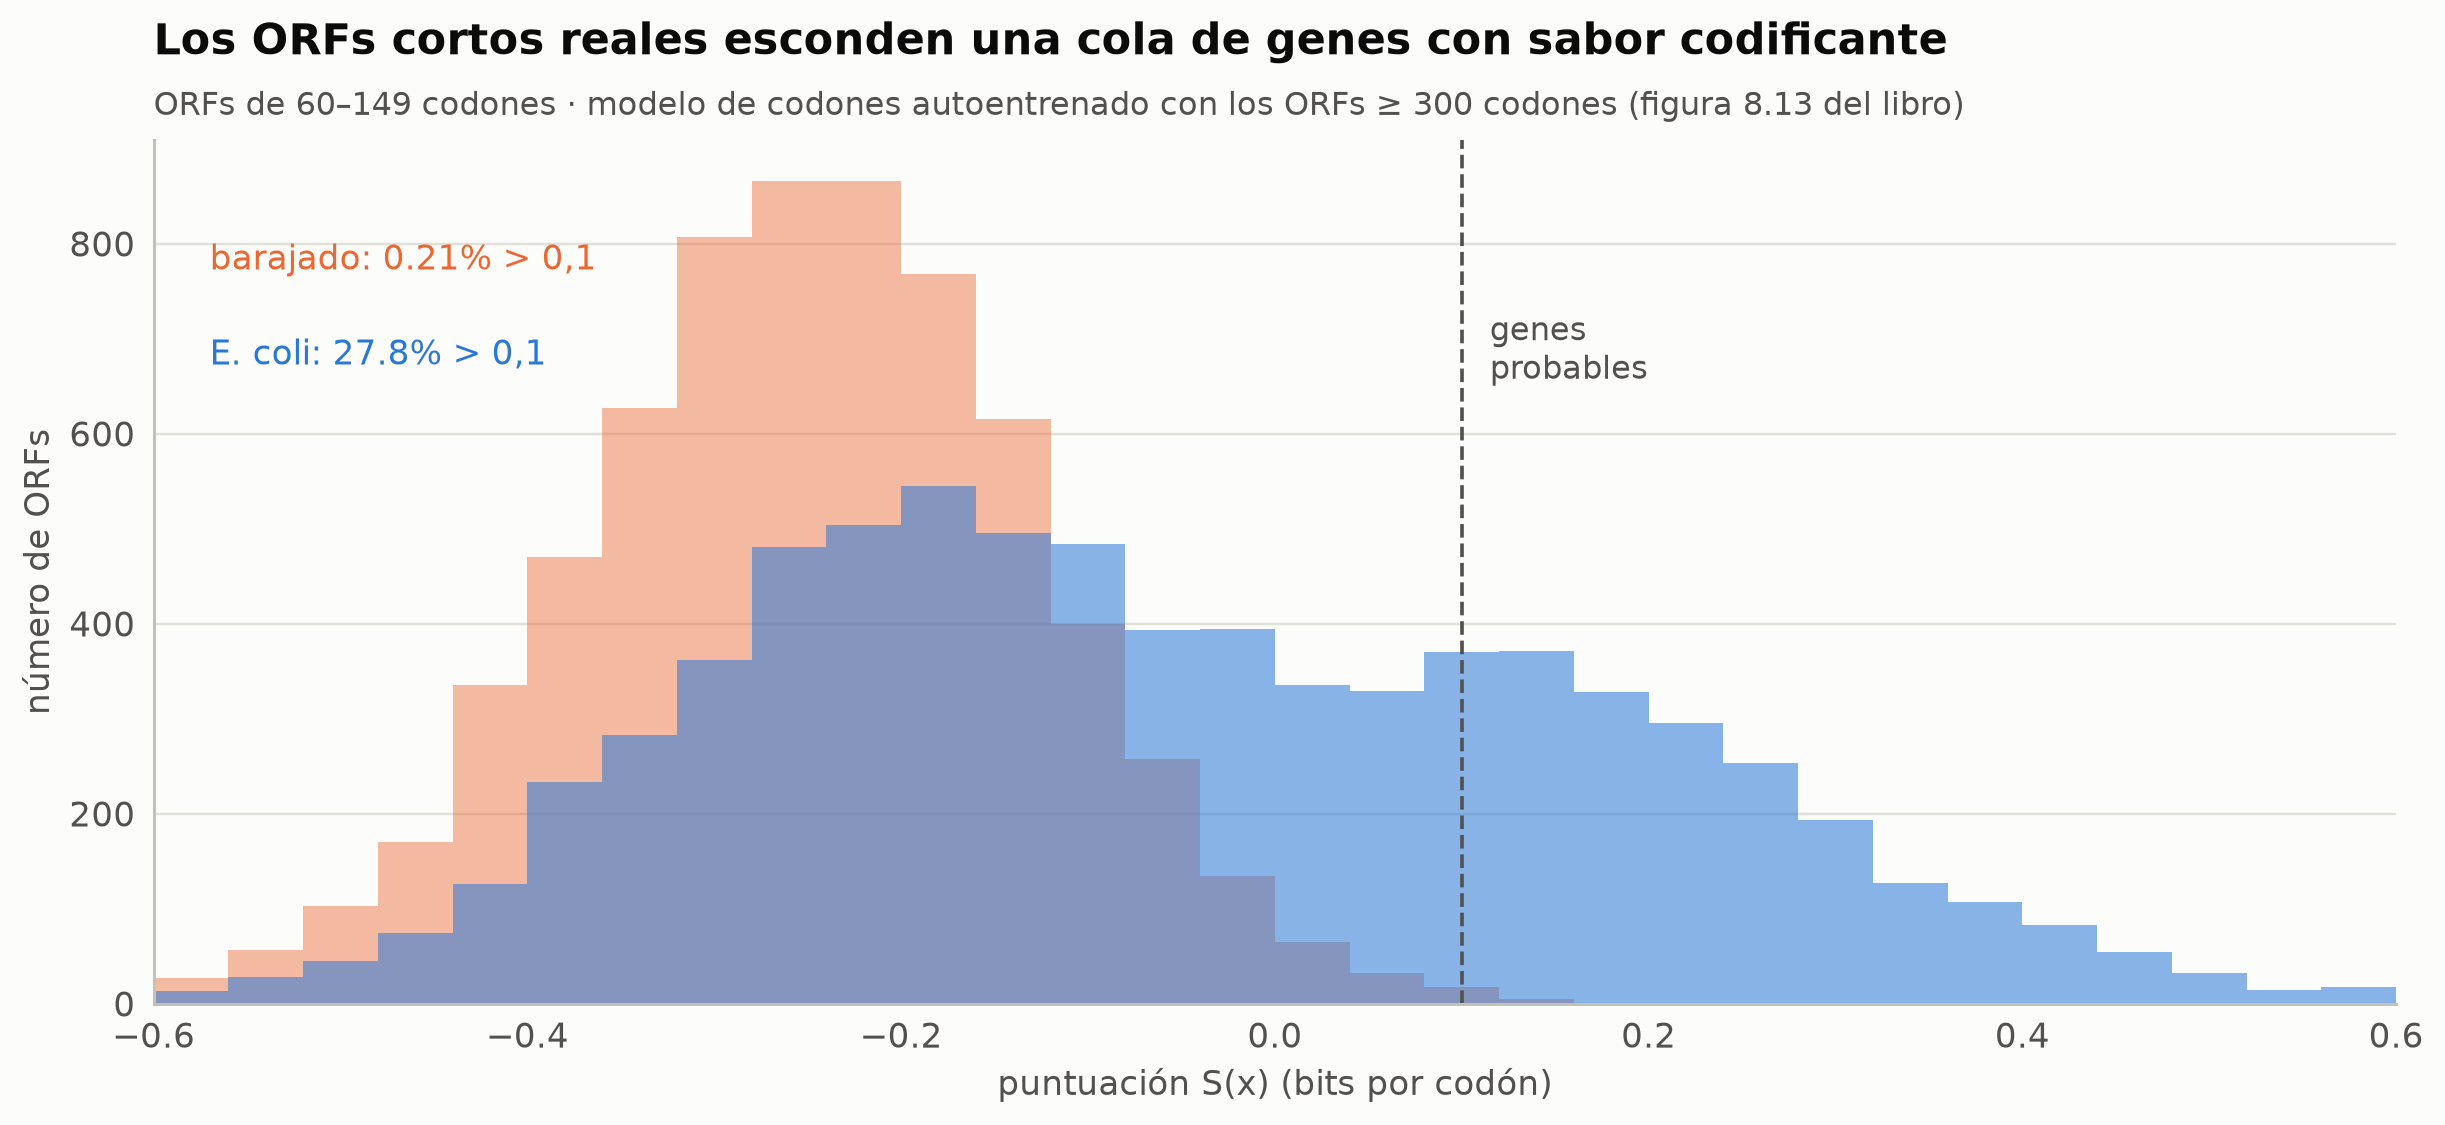

In [10]:
LLR_VEC = np.array([llr.get(a + b + c, 0.0) for a in "ACGT" for b in "ACGT" for c in "ACGT"])   # índice base 4

def score_orfs(seq, orfs):
    """Puntuación S(x) (bits/codón) de cada ORF de la tabla, con sumas acumuladas por marco y hebra."""
    out = np.zeros(len(orfs))
    for strand, s in ((1, seq), (-1, revcomp(seq))):
        x = encode(s)
        n = len(x) - 2
        v = LLR_VEC[x[:n] * 16 + x[1:n + 1] * 4 + x[2:n + 2]]
        for f in range(3):
            cs = np.r_[0.0, np.cumsum(v[f::3])]
            m = (orfs.strand.values == strand) & (orfs.start.values % 3 == f)
            a, b = orfs.start.values[m] // 3, orfs.end.values[m] // 3
            out[m] = (cs[b] - cs[a]) / (b - a)
    return out

orf_real["S"] = score_orfs(eco, orf_real)
orf_shuf["S"] = score_orfs(shuffled, orf_shuf)
short_r = orf_real[(orf_real.codons >= 60) & (orf_real.codons < 150)]
short_b = orf_shuf[(orf_shuf.codons >= 60) & (orf_shuf.codons < 150)]
print(f"ORFs de 60–149 codones: reales {len(short_r):,} · barajados {len(short_b):,}")
print(f"S medio: reales {short_r.S.mean():+.3f} · barajados {short_b.S.mean():+.3f} bits/codón")
print(f"Fracción con S > 0,1: reales {np.mean(short_r.S > 0.1):.1%} · barajados {np.mean(short_b.S > 0.1):.2%}")

fig, ax = plt.subplots(figsize=(11, 5))
b = np.arange(-0.6, 0.62, 0.04)
ax.hist(short_b.S, b, color=ec.ORANGE, alpha=0.45, label="barajado")
ax.hist(short_r.S, b, color=ec.BLUE, alpha=0.55, label="E. coli")
ax.axvline(0.1, color=ec.INK_2, ls="--", lw=1.2)
ax.text(0.115, ax.get_ylim()[1] * 0.8, "genes\nprobables", fontsize=10.5, color=ec.INK_2, va="top")
ax.text(-0.57, ax.get_ylim()[1] * 0.85, f"barajado: {np.mean(short_b.S > 0.1):.2%} > 0,1", color=ec.ORANGE,
        fontsize=11)
ax.text(-0.57, ax.get_ylim()[1] * 0.74, f"E. coli: {np.mean(short_r.S > 0.1):.1%} > 0,1", color=ec.BLUE, fontsize=11)
ax.set_xlabel("puntuación S(x) (bits por codón)"); ax.set_ylabel("número de ORFs"); ax.set_xlim(-0.6, 0.6)
ec.title(ax, "Los ORFs cortos reales esconden una cola de genes con sabor codificante",
         "ORFs de 60–149 codones · modelo de codones autoentrenado con los ORFs ≥ 300 codones (figura 8.13 del libro)")
plt.show()

> 🔎 **Qué observamos.** Los ORFs barajados forman una sola campana negativa: sólo el 0,2 % supera 0,1 bits/codón.
> Los reales son una **mezcla**: una campana parecida (ORFs espurios, muchos de ellos en otro marco o en la hebra
> opuesta de un gen verdadero, los "ORFs sombra" de la lección 1.2) y una cola positiva de genes cortos, el **27,8 %**
> por encima de 0,1. Incluso este modelo tan simple, de codones independientes, separa buena parte de los genes.

> ✅ **Compruebe su comprensión.** ¿Por qué un ORF sombra (en la hebra opuesta de un gen) puntúa en general
> **negativo** con este modelo, aunque está hecho de la misma secuencia que el gen? *(Pista: lea `CTG` al revés y
> complementado: es `CAG`… y el `AAA` favorecido se convierte en `TTT`. Los codones del gen, leídos en otra fase o en
> la otra hebra, forman trinucleótidos con otro sesgo.)*

---

## 4. Periodicidad de tres y cadenas de Márkov de fase

### Un texto con métrica

Un poema en endecasílabos tiene una regularidad que se oye aunque no se entiendan las palabras: los acentos caen en
posiciones fijas. El ADN codificante tiene su propia "métrica" de periodo **tres**: cada posición del codón está
sometida a restricciones distintas. La **primera** posición define en buena parte el aminoácido (y suele ser G o A);
la **segunda** determina su química (hidrofóbico si es T); la **tercera** es la más libre, porque muchos cambios en ella
son sinónimos, y refleja el sesgo de uso de codones de la especie. En el ADN no codificante no hay tal métrica.

Comprobémoslo con los **4 297 genes** anotados en RefSeq para MG1655 (ahora sí usamos la anotación, para aprender
cómo se ve la señal).

In [11]:
cds_k12 = read_table("NC_000913.3_cds.tsv.gz")
cds_only = cds_k12[(cds_k12.type == "CDS") & ((cds_k12.end - cds_k12.start + 1) % 3 == 0)].copy()

def gene_seq(r):
    s = eco[r.start - 1:r.end]
    return s if r.strand == "+" else revcomp(s)

cds_only["seq"] = [gene_seq(r) for r in cds_only.itertuples()]
covered = np.zeros(G, bool)
for r in cds_k12.itertuples():                        # CDS y ARNr (ambas hebras)
    covered[r.start - 1:r.end] = True
idx = np.flatnonzero(~covered)
cuts = np.flatnonzero(np.diff(idx) != 1) + 1
intergenic = [(seg[0], seg[-1] + 1) for seg in np.split(idx, cuts)]
print(f"CDS: {len(cds_only):,} (con longitud múltiplo de 3) · segmentos intergénicos: {len(intergenic):,} "
      f"· fracción no codificante: {(~covered).mean():.1%}")

# Composición por posición del codón (1, 2, 3) y en el ADN intergénico
comp = np.zeros((4, 4))
for s in cds_only.seq:
    x = encode(s[:-3])
    for ph in range(3):
        comp[ph] += np.bincount(x[ph::3], minlength=4)
ig_seq = "".join(eco[a:b] for a, b in intergenic)
xi = encode(ig_seq + revcomp(ig_seq))
comp[3] = np.bincount(xi, minlength=4)
comp /= comp.sum(1, keepdims=True)
compo = pd.DataFrame(comp, columns=list("ACGT"), index=["posición 1", "posición 2", "posición 3", "intergénico"])
compo["GC"] = compo.C + compo.G
compo.round(3)

CDS: 4,297 (con longitud múltiplo de 3) · segmentos intergénicos: 3,543 · fracción no codificante: 13.6%


,A,C,G,T,GC
posición 1,0.253,0.243,0.349,0.155,0.593
posición 2,0.288,0.227,0.181,0.305,0.407
posición 3,0.178,0.270,0.293,0.260,0.562
intergénico,0.283,0.217,0.217,0.283,0.433


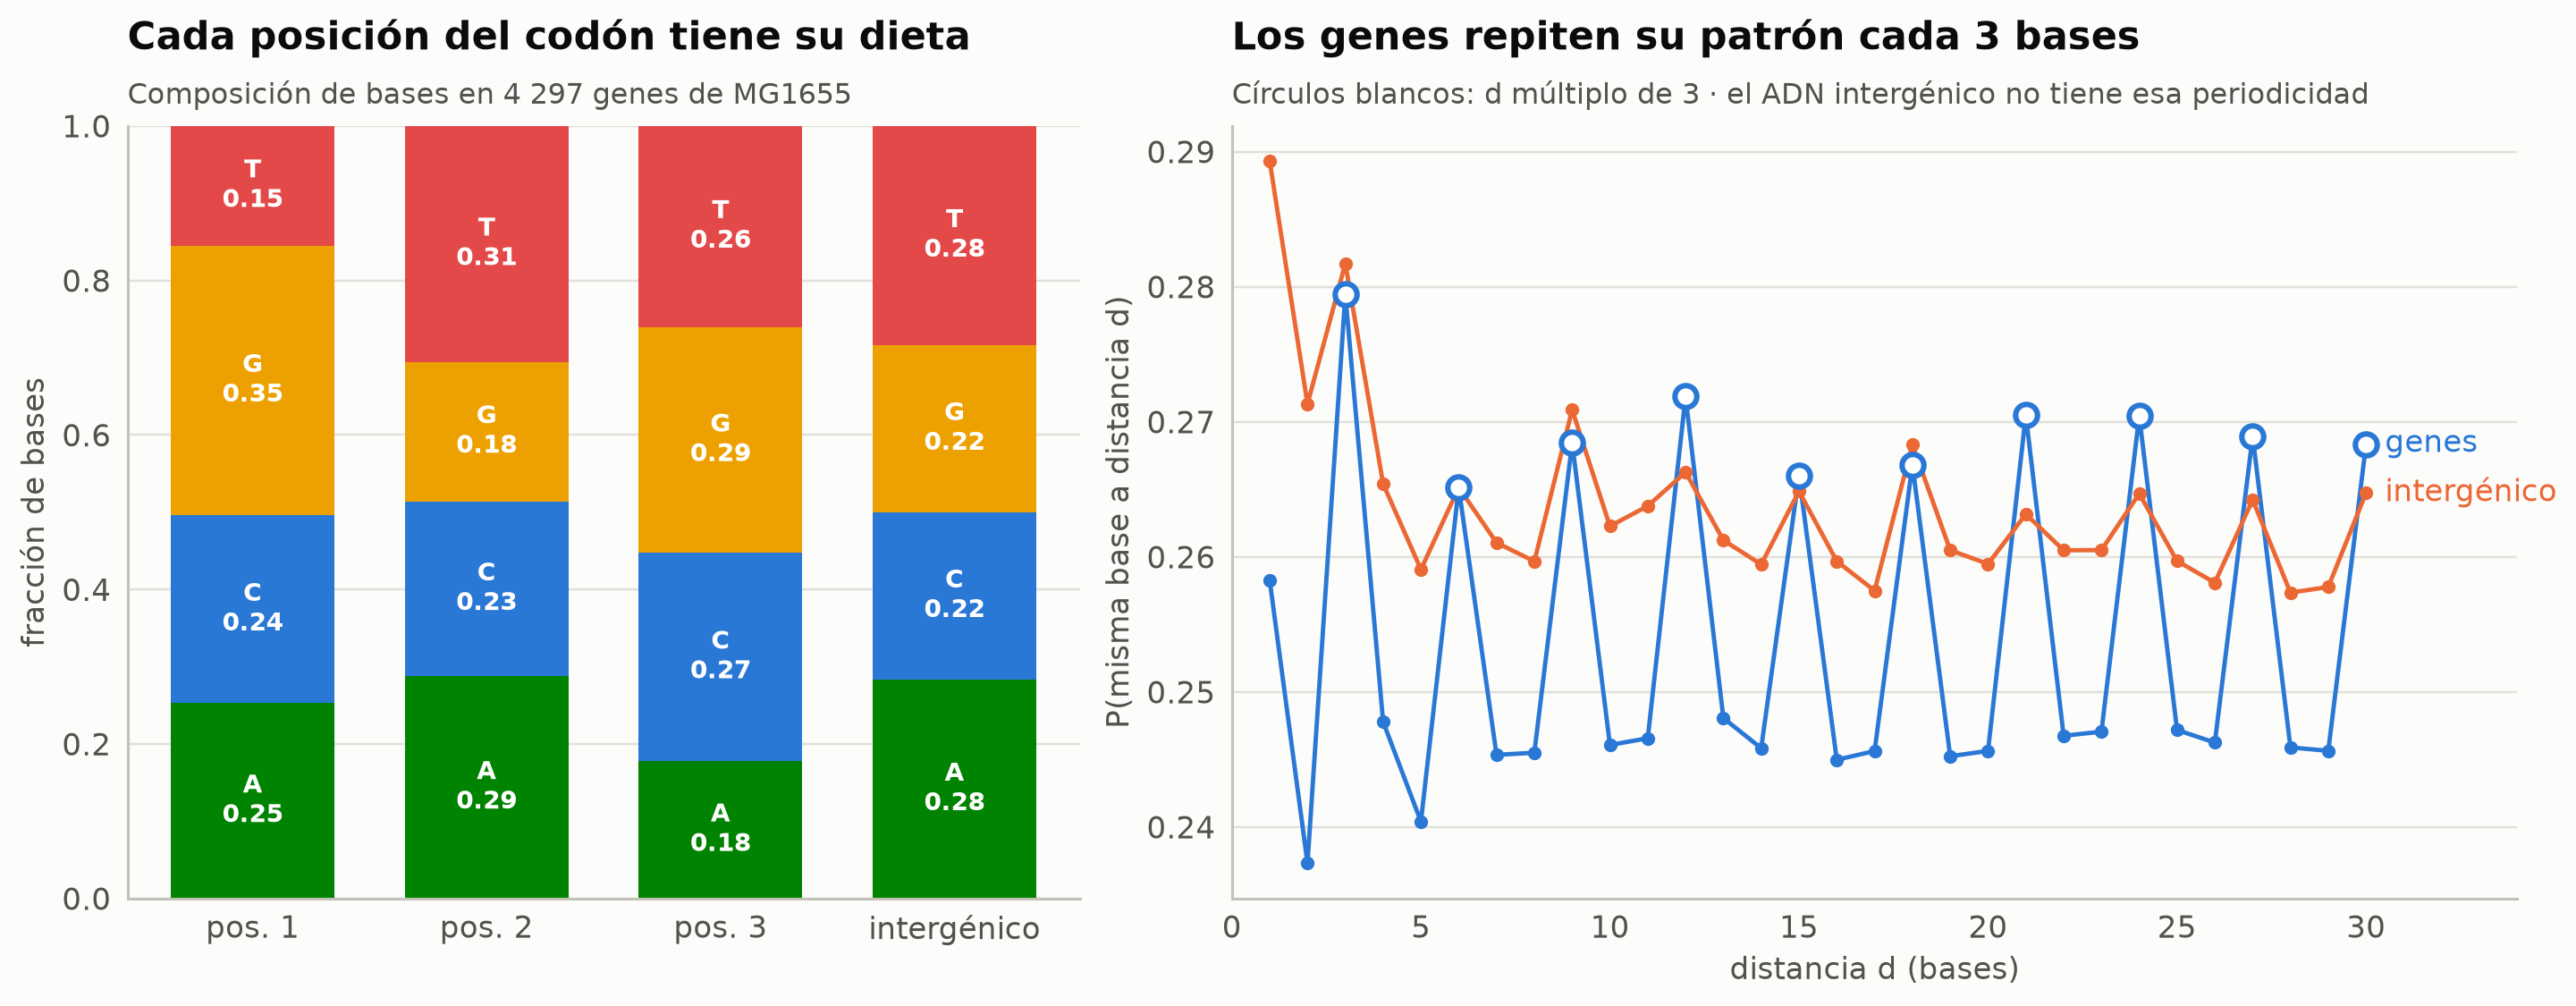

In [12]:
# Autocorrelación de identidad: P(x_i = x_{i+d}) en genes e intergénico
def same_base_profile(seqs, dmax=30):
    num, den = np.zeros(dmax + 1), np.zeros(dmax + 1)
    for s in seqs:
        x = encode(s)
        for d in range(1, dmax + 1):
            if len(x) > d:
                num[d] += np.sum(x[:-d] == x[d:]); den[d] += len(x) - d
    return num[1:] / den[1:]

prof_cds = same_base_profile(cds_only.seq.iloc[::4])
prof_ig = same_base_profile([eco[a:b] for a, b in intergenic if b - a > 60])
d = np.arange(1, 31)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw=dict(width_ratios=[1, 1.35]))
bottom = np.zeros(4)
for j, bse in enumerate("ACGT"):
    a1.bar(range(4), comp[:, j], bottom=bottom, color=ec.NUC_COLORS[bse], width=0.7, edgecolor="white")
    for k in range(4):
        if comp[k, j] > 0.06:
            a1.text(k, bottom[k] + comp[k, j] / 2, f"{bse}\n{comp[k, j]:.2f}", ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
    bottom += comp[:, j]
a1.set_xticks(range(4), ["pos. 1", "pos. 2", "pos. 3", "intergénico"]); a1.set_ylim(0, 1)
a1.set_ylabel("fracción de bases")
ec.title(a1, "Cada posición del codón tiene su dieta", "Composición de bases en 4 297 genes de MG1655")
a2.plot(d, prof_cds, "-o", color=ec.BLUE, ms=4, lw=1.6)
a2.plot(d, prof_ig, "-o", color=ec.ORANGE, ms=4, lw=1.6)
a2.plot(d[2::3], prof_cds[2::3], "o", color=ec.BLUE, ms=8, mfc="white", mew=2)
a2.text(30.5, prof_cds[-1], "genes", color=ec.BLUE, va="center", fontsize=11)
a2.text(30.5, prof_ig[-1], "intergénico", color=ec.ORANGE, va="center", fontsize=11)
a2.set_xlabel("distancia d (bases)"); a2.set_ylabel("P(misma base a distancia d)"); a2.set_xlim(0, 34)
ec.title(a2, "Los genes repiten su patrón cada 3 bases", "Círculos blancos: d múltiplo de 3 · el ADN intergénico no tiene esa periodicidad")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la primera posición es rica en **G** (35 %), la segunda en **T** y **A**
> (aminoácidos hidrofóbicos y cargados) y pobre en G, y la tercera vuelve a ser rica en G+C (56 %): es el sesgo de uso
> de codones de *E. coli*. El ADN intergénico es más rico en A+T y, por definición, no distingue posiciones. A la
> derecha, la probabilidad de encontrar la **misma** base a distancia $d$ oscila con periodo 3 en los genes, con
> picos regulares en $d=3,6,9\ldots$ muy por encima de los valles; en el intergénico la oscilación es mucho más
> débil e irregular (lo poco que queda proviene de genes pequeños no anotados y de bordes de genes). Esa "métrica" es la huella que explotan todos los predictores de genes.

### Ecuación 8.18: cadenas de Márkov de orden $m$ dependientes de la fase

El modelo de codones independientes ignora el contexto entre codones. Los predictores reales usan **cadenas de Márkov
de fase**: la probabilidad de cada base depende de las $m$ bases anteriores **y** de la posición que ocupa dentro del
codón:

$$
\log P_{\text{cod}}(x) = \sum_{i}\log P\bigl(x_i \,\bigm|\, x_{i-m}\cdots x_{i-1},\ \phi(i)\bigr),
\qquad \phi(i)\in\{1,2,3\}.
$$

| Símbolo | Significado |
|---|---|
| $x_i$ | base en la posición $i$ |
| $m$ | orden de la cadena: cuántas bases previas se usan como contexto (típicamente 5) |
| $x_{i-m}\cdots x_{i-1}$ | el contexto: las $m$ bases anteriores |
| $\phi(i)$ | fase: posición de la base $i$ dentro del codón (1, 2 o 3) |

Para decidir, comparamos con un modelo **no codificante** $P_{\text{nc}}$ (una cadena de Márkov ordinaria del mismo
orden, sin fase, entrenada con ADN intergénico) y usamos la misma razón log-odds de antes:
$\text{LLR}(x) = \log_2 P_{\text{cod}}(x) - \log_2 P_{\text{nc}}(x)$. Con orden $m=0$ y fase, el modelo sabe la
"dieta" de cada posición del codón (el panel izquierdo de arriba); con $m=2$ ya ve codones completos; con $m=5$, pares
de codones.

**Un ejemplo a mano (orden 1).** Suponga que en genes, tras una `C` en fase 2, la tercera posición es `G` con
probabilidad 0,40, mientras que en el intergénico, tras una `C`, viene `G` con probabilidad 0,20. Una `G` en esa
situación aporta $\log_2(0{,}40/0{,}20) = +1$ bit a favor de "codificante en este marco". En otro marco la misma `G`
estaría en fase 1 o 3, con otras probabilidades: por eso el modelo también dice **en qué marco** está el gen.

**¿Cuántos parámetros?** Para cada fase (3) y cada contexto ($4^m$) hay 4 probabilidades que suman 1, o sea 3 libres:
$3 \times 4^m \times 3$. Con $m=5$, $3\times1024\times3 = 9\,216$ parámetros; con $m=8$, casi 600 000. Los contextos
raros se estiman mal, y por eso Glimmer (Salzberg et al., 1998) introdujo los **modelos de Márkov interpolados**, que mezclan órdenes de 0 a 8
según cuántas veces se observó cada contexto.

### Experimento: ¿cuánto ayuda el orden?

Entrenamos con los genes y el intergénico de la **primera mitad** del genoma y evaluamos en la **segunda mitad**
(para no examinarnos con las respuestas a la vista). Tomamos ventanas de 120 pb (40 codones, del tamaño de un gen
muy corto):

* **positivas:** una ventana en marco dentro de cada gen de la segunda mitad;
* **negativas A:** ventanas del ADN intergénico (hebra al azar);
* **negativas B, "sombra":** la **hebra complementaria** de las mismas ventanas codificantes. Es la prueba difícil: tiene
  exactamente la misma composición G+C que el gen.

Cada ventana se puntúa en sus tres marcos y nos quedamos con el mejor, porque en la práctica no conocemos la fase.

In [13]:
def contexts(x, m):
    """Número (base 4) de las m bases que preceden a cada posición (válido desde la posición m)."""
    c = np.zeros(len(x), dtype=np.int64)
    for j in range(m, 0, -1):
        c[m:] = c[m:] * 4 + x[m - j:len(x) - j]
    return c

def train_phase_markov(seqs, m, pseudo=1.0):
    """P(x_i | contexto, fase) para secuencias codificantes en marco; devuelve log2 de un arreglo (3, 4^m, 4)."""
    C = np.full((3, 4 ** m, 4), pseudo)
    for s in seqs:
        x = encode(s)
        c, ph = contexts(x, m), np.arange(len(x)) % 3
        np.add.at(C, (ph[m:], c[m:], x[m:]), 1)
    return np.log2(C / C.sum(2, keepdims=True))

def train_markov(seqs, m, pseudo=1.0):
    """Cadena de Márkov homogénea de orden m (ambas hebras); log2 de un arreglo (4^m, 4)."""
    C = np.full((4 ** m, 4), pseudo)
    for s in seqs:
        for t in (s, revcomp(s)):
            if len(t) > m:
                x = encode(t); c = contexts(x, m)
                np.add.at(C, (c[m:], x[m:]), 1)
    return np.log2(C / C.sum(1, keepdims=True))

def llr_best_frame(s, Pc, Pn, m):
    """LLR (bits) de la ventana s en su mejor marco de lectura."""
    x = encode(s); c = contexts(x, m); i = np.arange(m, len(x))
    null = Pn[c[m:], x[m:]].sum()
    return max(Pc[(i - f) % 3, c[m:], x[m:]].sum() - null for f in range(3))

half = G // 2
train_cds = cds_only[cds_only.end < half].seq.tolist()
test_cds = cds_only[cds_only.start > half].seq.tolist()
train_ig = [eco[a:b] for a, b in intergenic if b < half]
test_ig = [eco[a:b] for a, b in intergenic if a > half and b - a >= 120]

rng = np.random.default_rng(84)
W = 120
pos_win = []
for s in test_cds:
    if len(s) >= W + 6:
        o = 3 * rng.integers(1, (len(s) - W) // 3)
        pos_win.append(s[o:o + W])
neg_win = []
for s in test_ig:
    for _ in range(max(1, len(s) // 300)):
        o = rng.integers(0, len(s) - W + 1)
        w = s[o:o + W]
        neg_win.append(w if rng.random() < 0.5 else revcomp(w))
shadow_win = [revcomp(w) for w in pos_win]
print(f"Ventanas: {len(pos_win):,} codificantes · {len(neg_win):,} intergénicas · {len(shadow_win):,} sombra")

t0 = time.time()
roc_scores = {}
for m in range(6):
    Pc, Pn = train_phase_markov(train_cds, m), train_markov(train_ig, m)
    roc_scores[m] = [np.array([llr_best_frame(w, Pc, Pn, m) for w in ws]) for ws in (pos_win, neg_win, shadow_win)]
print(f"6 órdenes entrenados y evaluados en {time.time() - t0:.1f} s")

Ventanas: 2,053 codificantes · 968 intergénicas · 2,053 sombra


6 órdenes entrenados y evaluados en 1.0 s


### La curva ROC, construida a mano

Un clasificador con puntuación continua necesita un **umbral**: todo lo que supere el umbral se llama "gen". Al bajar
el umbral aceptamos más genes verdaderos (sube la **sensibilidad** o tasa de verdaderos positivos, TPR) pero también
más falsos (sube la tasa de falsos positivos, FPR). La **curva ROC** dibuja TPR contra FPR para todos los umbrales, y
el **área bajo la curva** (AUC) resume la separación: 0,5 es tirar una moneda, 1 es perfecto. El AUC tiene una lectura
muy concreta: es la probabilidad de que una ventana positiva elegida al azar puntúe más que una negativa al azar.

Con 5 ventanas es fácil hacerlo a mano. Puntuaciones positivas {4, 3, 1}, negativas {2, 0}. Ordenando de mayor a
menor: 4(+) 3(+) 2(−) 1(+) 0(−). Umbral a umbral: TPR/FPR = 1/3·0, 2/3·0, 2/3·½, 1·½, 1·1. De los $3\times2=6$ pares
(positiva, negativa), la positiva gana en 5: AUC $=5/6=0{,}83$.

In [14]:
def roc_curve(pos, neg):
    """TPR, FPR y umbrales recorriendo las puntuaciones de mayor a menor (sin librerías externas)."""
    s = np.r_[pos, neg]; y = np.r_[np.ones(len(pos)), np.zeros(len(neg))]
    o = np.argsort(-s, kind="mergesort")
    tpr = np.r_[0, np.cumsum(y[o]) / len(pos)]
    fpr = np.r_[0, np.cumsum(1 - y[o]) / len(neg)]
    return fpr, tpr, np.r_[np.inf, s[o]]

def auc(fpr, tpr):
    return float(np.trapezoid(tpr, fpr)) if hasattr(np, "trapezoid") else float(np.trapz(tpr, fpr))

f_, t_, _ = roc_curve(np.array([4, 3, 1]), np.array([2, 0]))
print("Ejemplo a mano: AUC =", round(auc(f_, t_), 3))

auc_tab = []
for m in range(6):
    p, n, sh = roc_scores[m]
    auc_tab.append((m, 3 * 4 ** m * 3, auc(*roc_curve(p, n)[:2]), auc(*roc_curve(p, sh)[:2])))
auc_tab = pd.DataFrame(auc_tab, columns=["orden m", "parámetros libres", "AUC vs intergénico", "AUC vs sombra"])
auc_tab.round(3)

Ejemplo a mano: AUC = 0.833


,orden m,parámetros libres,AUC vs intergénico,AUC vs sombra
0,0,9,0.886,0.629
1,1,36,0.925,0.760
2,2,144,0.959,0.892
3,3,576,0.961,0.901
4,4,2304,0.962,0.911
5,5,9216,0.963,0.913


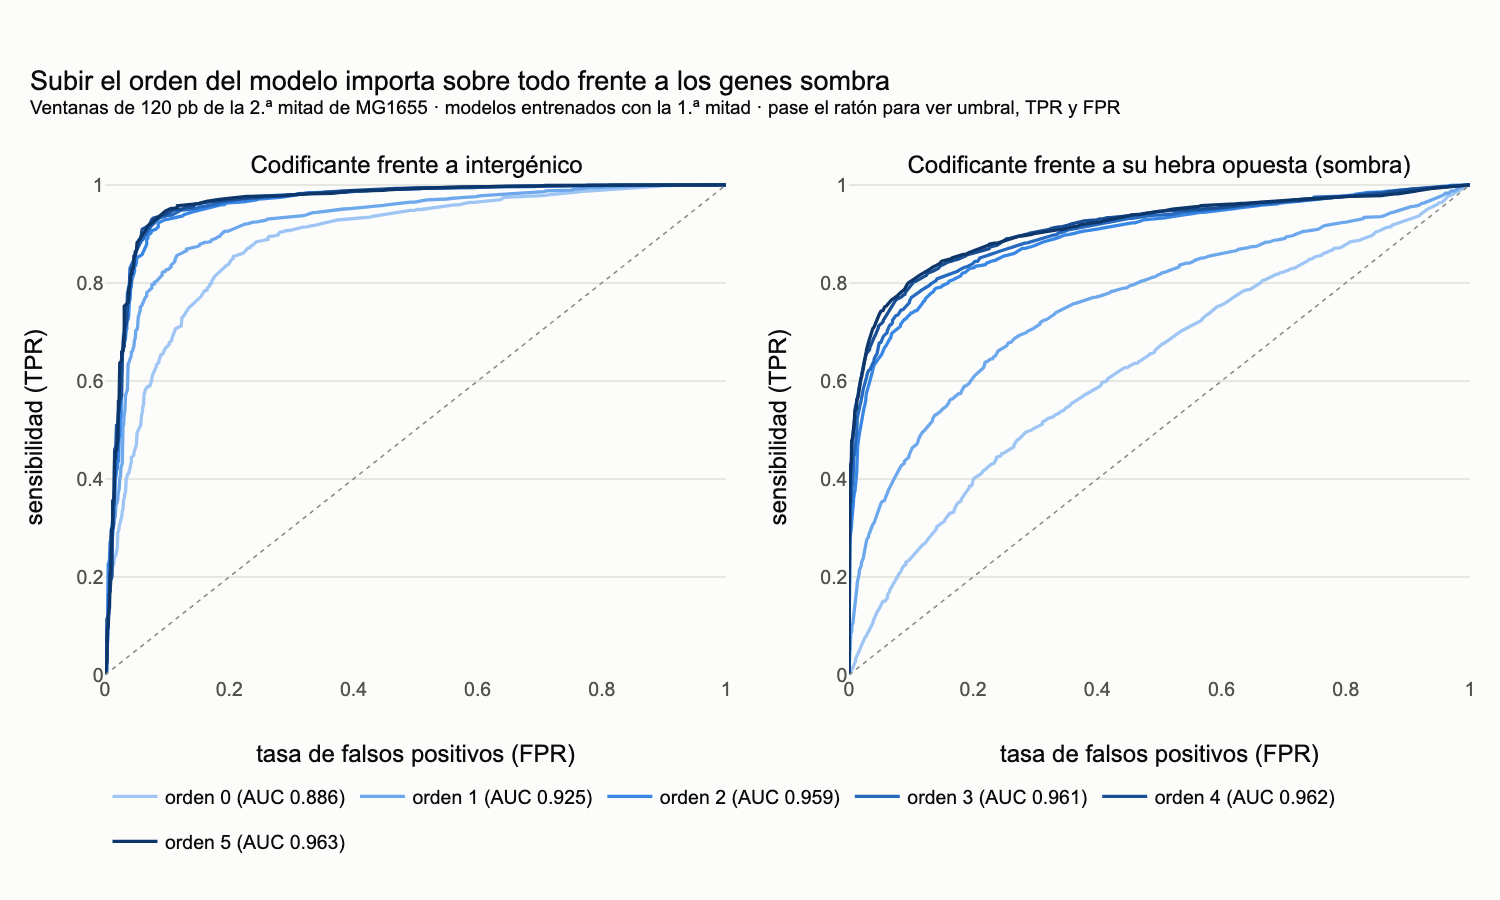

In [15]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.09,
                    subplot_titles=("Codificante frente a intergénico", "Codificante frente a su hebra opuesta (sombra)"))
colors = [ec.SEQ_BLUE[2], ec.SEQ_BLUE[4], ec.SEQ_BLUE[6], ec.SEQ_BLUE[8], ec.SEQ_BLUE[10], ec.SEQ_BLUE[12]]
for col, which, name in ((1, 1, "intergénico"), (2, 2, "sombra")):
    for m in range(6):
        p, neg = roc_scores[m][0], roc_scores[m][which]
        fpr, tpr, thr = roc_curve(p, neg)
        step = max(1, len(fpr) // 400)                    # submuestreo: la curva se ve igual y pesa menos
        k = np.r_[np.arange(0, len(fpr), step), len(fpr) - 1]
        a = auc(fpr, tpr)
        fig.add_trace(go.Scatter(
            x=fpr[k], y=tpr[k], mode="lines", line=dict(color=colors[m], width=2.2),
            name=f"orden {m} (AUC {a:.3f})", legendgroup=str(m), showlegend=(col == 1),
            customdata=np.c_[thr[k], np.full(len(k), a)],
            hovertemplate=(f"<b>Márkov de fase, orden {m}</b> · negativas: {name}<br>"
                           "umbral LLR ≥ %{customdata[0]:.1f} bits<br>"
                           "sensibilidad (TPR) = %{y:.1%}<br>falsos positivos (FPR) = %{x:.1%}<br>"
                           "AUC = %{customdata[1]:.3f}<extra></extra>")), row=1, col=col)
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(color=ec.MUTED, dash="dot", width=1),
                             showlegend=False, hoverinfo="skip"), row=1, col=col)
fig.update_xaxes(title_text="tasa de falsos positivos (FPR)", range=[0, 1])
fig.update_yaxes(title_text="sensibilidad (TPR)", range=[0, 1.01])
fig.update_layout(height=520, margin=dict(t=150, l=70, r=20, b=60),
                  title="Subir el orden del modelo importa sobre todo frente a los genes sombra"
                        "<br><sup>Ventanas de 120 pb de la 2.ª mitad de MG1655 · modelos entrenados con la 1.ª mitad · "
                        "pase el ratón para ver umbral, TPR y FPR</sup>",
                  legend=dict(orientation="h", yanchor="top", y=-0.2, x=0))
fig.update_layout(margin=dict(t=120, l=70, r=20, b=150), height=600)
fig.show()

> 🔎 **Qué observamos.** Frente al ADN intergénico, incluso el orden 0 (sólo la "dieta" de cada posición del codón)
> logra un AUC de 0,89, y el orden 5 llega a 0,96: el intergénico es más rico en A+T y ya se delata por su
> composición. Frente a la **hebra opuesta**, en cambio, el orden 0 apenas supera una moneda (AUC ≈ 0,63), porque
> la composición es la misma; hace falta contexto (órdenes 2–5, AUC ≈ 0,89–0,91) para reconocer que los codones leídos
> al revés "no suenan" a gen. Esa es la razón por la que GeneMark y Glimmer usan órdenes altos: evitar los genes
> sombra, el error clásico de los predictores simples.

> ✅ **Compruebe su comprensión.** ¿Por qué no usar directamente orden 8 con estos datos? Calcule los parámetros
> ($3\times4^8\times3 \approx 590\,000$) y compárelos con los ~2 millones de bases codificantes de entrenamiento de la
> primera mitad del genoma: ¿cuántas observaciones tocan por parámetro?

### 🎬 El gráfico de marcos: cómo "ve" un predictor el genoma

GeneMark popularizó una forma de mirar la señal: una ventana que se desliza por el genoma y, en cada posición, calcula
la puntuación de Márkov en los **seis** marcos de lectura. Donde hay un gen, uno de los seis marcos se enciende y los
demás se apagan. Veámoslo en 7 kb de MG1655 alrededor del operón *lac*, el sistema con el que Jacob y Monod
descubrieron la regulación génica.

> 🤔 **Antes de ejecutar, prediga:** los genes *lacZ*, *lacY* y *lacA* están en la hebra **−**. ¿En qué filas del
> gráfico espera ver la señal?

![Ventana deslizante de 96 pb con el modelo de Márkov de fase de orden 5: en cada gen se enciende uno de los seis marcos de lectura (filas), justo el del gen anotado (flechas)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-08-ensamblaje/8.4_marcos.gif)

*Ventana deslizante de 96 pb con el modelo de Márkov de fase de orden 5: en cada gen se enciende uno de los seis marcos de lectura (filas), justo el del gen anotado (flechas)*

In [16]:
Pc5, Pn5 = train_phase_markov(train_cds, 5), train_markov(train_ig, 5)
REG_A, REG_B = 360_000, 367_600                 # 0-based, semiabierto
region = eco[REG_A:REG_B]; L = len(region)
WIN, STEP = 96, 24

def frame_tracks(seq, Pc, Pn, m):
    """Puntuación LLR por ventana en los 6 marcos. Filas 0–2: hebra +, marcos 1–3; filas 3–5: hebra −."""
    rows, centers = [], np.arange(0, len(seq) - WIN, STEP)
    for strand, s in ((1, seq), (-1, revcomp(seq))):
        x = encode(s); c = contexts(x, m); i = np.arange(len(x))
        null = Pn[c, x]
        for f in range(3):
            v = Pc[(i - f) % 3, c, x] - null
            v[:m] = 0
            cs = np.r_[0, np.cumsum(v)]
            sc = (cs[centers + WIN] - cs[centers]) if strand == 1 else \
                 (cs[len(s) - centers] - cs[len(s) - centers - WIN])
            rows.append(sc)
    return centers + WIN / 2, np.array(rows)

xc, tracks = frame_tracks(region, Pc5, Pn5, 5)
genes_reg = cds_k12[(cds_k12.type == "CDS") & (cds_k12.end > REG_A) & (cds_k12.start <= REG_B)]

def gene_row(r):
    """Fila del gráfico (0–5) del marco del gen: hebra + → (inicio−1−REG_A) mod 3; hebra − → según su final."""
    if r.strand == "+":
        return (r.start - 1 - REG_A) % 3
    return 3 + (L - (r.end - REG_A)) % 3

fig, axes = plt.subplots(7, 1, figsize=(12, 7.6), sharex=True,
                         gridspec_kw=dict(height_ratios=[1] * 6 + [1.1], hspace=0.12))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.9))
labels = ["+1", "+2", "+3", "−1", "−2", "−3"]
lines = []
for k, axk in enumerate(axes[:6]):
    axk.axhline(0, color=ec.BASELINE, lw=0.8)
    axk.set_ylim(-4, 60); axk.set_yticks([]); axk.set_xlim(0, L)
    axk.text(-60, 5, f"marco {labels[k]}", ha="right", va="center", fontsize=10,
             color=ec.BLUE if k < 3 else ec.ORANGE)
    lines.append(axk.fill_between([], [], color=ec.BLUE))
axg = axes[6]
axg.set_ylim(-1.2, 1.2); axg.set_yticks([])
for r in genes_reg.itertuples():
    a, b = max(r.start - 1 - REG_A, 0), min(r.end - REG_A, L)
    y, col = (0.5, ec.BLUE) if r.strand == "+" else (-0.5, ec.ORANGE)
    dx = (b - a) if r.strand == "+" else -(b - a)
    x0 = a if r.strand == "+" else b
    axg.add_patch(FancyArrowPatch((x0, y), (x0 + dx, y), arrowstyle="simple,head_length=8,head_width=10,tail_width=6",
                                  color=col, lw=0))
    if b - a > 500:
        axg.text((a + b) / 2, y + (0.55 if r.strand == "+" else -0.6), r.gene, ha="center", va="center",
                 fontsize=9.5, style="italic")
    axes[gene_row(r)].axvspan(a, b, color=col, alpha=0.08, lw=0)
axg.set_xlabel(f"posición en MG1655 − {REG_A:,} (pb)")
axg.text(-60, 0, "RefSeq", ha="right", va="center", fontsize=10, color=ec.INK_2)
fig.text(0.01, 0.985, "Donde hay un gen, se enciende un solo marco de lectura", fontsize=15, fontweight="bold",
         va="top", color=ec.INK)
fig.text(0.01, 0.945, f"LLR de Márkov de fase (orden 5) en ventanas de {WIN} pb · MG1655 {REG_A:,}–{REG_B:,} "
         "(operón lac) · sombreado: marco del gen anotado", fontsize=10.5, va="top", color=ec.INK_2)
cursor = [axk.axvline(0, color=ec.INK, lw=1, ls=":") for axk in axes]
NFR = 48
def update(fr):
    upto = int(len(xc) * (fr + 1) / NFR) if fr < NFR - 4 else len(xc)
    for k, axk in enumerate(axes[:6]):
        lines[k].remove()
        y = np.clip(tracks[k][:upto], -45, 60)
        lines[k] = axk.fill_between(xc[:upto], 0, y, where=y > 0, color=ec.BLUE if k < 3 else ec.ORANGE, lw=0,
                                    interpolate=True)
    for cl in cursor:
        cl.set_xdata([xc[upto - 1]] * 2)
    return []
fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=NFR, interval=160, name="8.4_marcos")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al avanzar la ventana, cada gen enciende **un solo** marco, siempre el mismo en toda su
> longitud y siempre el de la anotación (sombreado): *lacZ* y *lacY* en el marco −3, *lacA* (más débil) en el −2,
> *lacI* en el −1, y *cynX* en la hebra +. Entre genes, todos los marcos quedan en negativo. Un predictor de
> genes no hace otra cosa que convertir este gráfico en decisiones: dónde empieza y dónde termina cada tramo
> encendido.

---

## 5. De los modelos a los predictores: GeneMark, Glimmer y Prodigal

Un predictor de genes procariotas junta tres ingredientes: **ORFs** candidatos, un **modelo de contenido** (Márkov de
fase) y reglas para decidir **dónde empieza** cada gen y **qué hacer cuando dos candidatos se solapan**. Las tres
familias clásicas combinan esos ingredientes de forma distinta:

| Programa | Idea central | Detalle que lo hizo famoso |
|---|---|---|
| **GeneMark** (Borodovsky y McIninch, 1993) | Cadenas de Márkov de fase en las dos hebras | El gráfico de marcos que acabamos de animar |
| **GeneMark.hmm** (Lukashin y Borodovsky, 1998) | Mete los modelos de Márkov en un HMM: los límites de los genes son transiciones entre estados ocultos | Un patrón del sitio de unión al ribosoma para precisar el inicio |
| **Glimmer** (Salzberg et al., 1998; Delcher et al., 1999; 2007) | Modelos de Márkov **interpolados** (órdenes 0 a 8, pesados según los datos) | Glimmer3: 99 % de sensibilidad con muchos menos falsos positivos |
| **Prodigal** (Hyatt et al., 2010) | Programación dinámica sobre **todos** los pares inicio–parada | Tres objetivos explícitos: mejor estructura, mejor inicio, menos falsos positivos |

Todos son **autoentrenables**: aprenden los parámetros del genoma que anotan, como hicimos con los ORFs de 300
codones. Prodigal, desarrollado a partir de la experiencia de curación manual de genomas en el Joint Genome Institute,
es hoy el motor de Prokka, Bakta y de casi todos los flujos de anotación bacteriana. Lo usaremos a través de
**pyrodigal** (Larralde, 2022), una interfaz de Python que envuelve el código C original: mismo resultado, sin
instalar binarios ni escribir archivos intermedios.

### Qué hace Prodigal, en cuatro pasos

1. **Entrena** con el propio genoma: contenido GC, tabla de traducción (11 en bacterias), sesgo de codones de los ORFs
   largos y, sobre todo, el motivo del sitio de unión al ribosoma (**RBS**, Shine-Dalgarno `AGGAGG`) y su distancia
   al inicio.
2. **Puntúa** cada posible codón de inicio (`ATG`, `GTG`, `TTG`) según su tipo, el RBS aguas arriba y la
   "codificabilidad" del tramo hasta la parada.
3. **Encadena** genes con programación dinámica (la misma de la lección 3.2): elige el conjunto de genes compatible
   (con solapamientos cortos permitidos) de máxima puntuación total.
4. **Marca** los genes **parciales** que tocan el borde de un contig: su inicio o su parada quedan fuera de la
   secuencia.

---

## 6. 🧪 Aplicación real: anotar el ensamblaje *de novo* del clon del LTEE

Volvemos al clon de *E. coli* B del experimento de Lenski (SRR2584863). En la lección 8.3 lo ensamblamos con SPAdes
**sin mirar la referencia**: 93 contigs $\ge 500$ pb, N50 = 98,6 kb, 98,3 % del genoma. Ahora lo anotamos como haría
un laboratorio que recibe un aislado desconocido, y **después**, sólo para evaluar, comparamos con la anotación de
RefSeq de su ancestro REL606 (NC_012967.1), que hace de verdad de campo.

In [17]:
contigs = read_fasta("SRR2584863_spades_full_contigs.fasta.gz")
ctg_len = pd.Series({k: len(v) for k, v in contigs.items()})
ctg_cov = pd.Series({k: float(k.split("_cov_")[1]) for k in contigs})
print(f"{len(contigs)} contigs · {ctg_len.sum():,} pb · mayor {ctg_len.max():,} pb · "
      f"GC {sum(s.count('G') + s.count('C') for s in contigs.values()) / ctg_len.sum():.3f}")

t0 = time.time()
finder = pyrodigal.GeneFinder(meta=False)
finder.train(*[s.encode() for s in contigs.values()])       # autoentrenamiento con todo el ensamblaje
genes_by_ctg = {name: finder.find_genes(s.encode()) for name, s in contigs.items()}
print(f"pyrodigal: entrenado y aplicado en {time.time() - t0:.1f} s · "
      f"GC de entrenamiento {finder.training_info.gc:.3f} · tabla {finder.training_info.translation_table} · "
      f"usa Shine-Dalgarno: {finder.training_info.uses_sd}")

K = 30
rows = []
for name, genes in genes_by_ctg.items():
    s = contigs[name]
    for g in genes:
        # 30-mer que termina en el codón de parada, leído en la hebra del gen: la "huella" del gen
        endk = s[g.end - K:g.end] if g.strand == 1 else revcomp(s[g.begin - 1:g.begin - 1 + K])
        rows.append((name, g.begin, g.end, g.strand, g.end - g.begin + 1, g.partial_begin, g.partial_end,
                     g.start_type, g.rbs_motif, g.rbs_spacer, round(g.score, 1), endk))
pred = pd.DataFrame(rows, columns=["contig", "begin", "end", "strand", "length", "partial_begin", "partial_end",
                                   "start_type", "rbs_motif", "rbs_spacer", "score", "endk"])
pred["partial"] = pred.partial_begin | pred.partial_end
print(f"Genes predichos: {len(pred):,} · parciales (tocan el borde de un contig): {pred.partial.sum()}")
print("Codones de inicio:", pred.start_type.value_counts().to_dict())
pred.drop(columns="endk").head(8)

93 contigs · 4,554,639 pb · mayor 243,412 pb · GC 0.507


pyrodigal: entrenado y aplicado en 1.0 s · GC de entrenamiento 0.507 · tabla 11 · usa Shine-Dalgarno: 1
Genes predichos: 4,280 · parciales (tocan el borde de un contig): 63
Codones de inicio: {'ATG': 3856, 'GTG': 328, 'TTG': 60, 'Edge': 36}


,contig,begin,end,strand,length,partial_begin,partial_end,start_type,rbs_motif,rbs_spacer,score,partial
0,NODE_1_length_243412_cov_37.561592,49,771,-1,723,False,False,ATG,GGA/GAG/AGG,5-10bp,27.0,False
1,NODE_1_length_243412_cov_37.561592,789,2141,-1,1353,False,False,TTG,AGGAG,5-10bp,36.2,False
2,NODE_1_length_243412_cov_37.561592,2374,3051,-1,678,False,False,ATG,AGGAG(G)/GGAGG,13-15bp,45.2,False
3,NODE_1_length_243412_cov_37.561592,3048,3824,-1,777,False,False,ATG,AGGA/GGAG/GAGG,11-12bp,52.2,False
4,NODE_1_length_243412_cov_37.561592,4885,5421,-1,537,False,False,ATG,GGAGG,5-10bp,62.3,False
5,NODE_1_length_243412_cov_37.561592,5423,6601,-1,1179,False,False,GTG,AGGAG,5-10bp,112.1,False
6,NODE_1_length_243412_cov_37.561592,6598,7575,-1,978,False,False,ATG,NaN,NaN,130.8,False
7,NODE_1_length_243412_cov_37.561592,7572,8177,-1,606,False,False,GTG,GGAGG,5-10bp,64.0,False


> 🔎 **Qué observamos.** En un par de segundos, Prodigal aprendió el genoma (GC ≈ 0,51, código genético 11, sitio de
> Shine-Dalgarno) y predijo unos 4 280 genes. Cada fila trae la hebra, si el gen es parcial en alguno de sus extremos,
> el tipo de codón de inicio (casi 90 % `ATG`, el resto `GTG` y `TTG`, como en *E. coli*), el motivo RBS encontrado
> aguas arriba (`AGGAG`, `GGA/GAG/AGG`…) con su distancia, y la puntuación.

La salida estándar de un anotador es un archivo **GFF3** (una línea por gen, nueve columnas separadas por tabulador) y
un FASTA de proteínas. pyrodigal los escribe directamente:

In [18]:
buf = io.StringIO()
first = list(genes_by_ctg)[0]
genes_by_ctg[first].write_gff(buf, sequence_id=first, header=True)
print("\n".join(buf.getvalue().splitlines()[:7]))
buf = io.StringIO()
genes_by_ctg[first].write_translations(buf, sequence_id=first)
print("\n".join(buf.getvalue().splitlines()[:3]))

##gff-version  3
# Sequence Data: seqnum=1;seqlen=243412;seqhdr="NODE_1_length_243412_cov_37.561592"
# Model Data: version=pyrodigal.v3.7.1;run_type=Single;model="Ab initio";gc_cont=50.71;transl_table=11;uses_sd=1
NODE_1_length_243412_cov_37.561592	pyrodigal_v3.7.1	CDS	49	771	27.0	-	0	ID=NODE_1_length_243412_cov_37.561592_1;partial=00;start_type=ATG;rbs_motif=GGA/GAG/AGG;rbs_spacer=5-10bp;gc_cont=0.379;conf=99.80;score=27.02;cscore=13.44;sscore=13.58;rscore=2.96;uscore=5.59;tscore=3.94;
NODE_1_length_243412_cov_37.561592	pyrodigal_v3.7.1	CDS	789	2141	36.2	-	0	ID=NODE_1_length_243412_cov_37.561592_2;partial=00;start_type=TTG;rbs_motif=AGGAG;rbs_spacer=5-10bp;gc_cont=0.309;conf=99.98;score=36.21;cscore=32.82;sscore=3.39;rscore=14.95;uscore=2.65;tscore=-13.55;
NODE_1_length_243412_cov_37.561592	pyrodigal_v3.7.1	CDS	2374	3051	45.2	-	0	ID=NODE_1_length_243412_cov_37.561592_3;partial=00;start_type=ATG;rbs_motif=AGGAG(G)/GGAGG;rbs_spacer=13-15bp;gc_cont=0.398;conf=100.00;score=45.23;cscore=40

> 🔎 **Qué observamos.** Cada línea GFF3 lleva contig, programa, tipo (`CDS`), inicio, fin (1-based, extremos
> incluidos), puntuación, hebra, fase y una columna de atributos con la información de Prodigal (`partial=00`: ambos
> extremos completos; `start_type`, `rbs_motif`, `conf`: confianza en %). La proteína traducida es el insumo de la
> anotación funcional (BLAST, InterProScan…).

### Ubicar los contigs en REL606 con anclas de $k$-mers

Para evaluar necesitamos saber **dónde** cae cada contig en el genoma de referencia. Lo haríamos con minimap2 (lección
7.2), pero podemos resolverlo con lo aprendido en 8.1, sin instalar nada: convertimos cada 31-mer en un número
entero de 62 bits (2 bits por base), ordenamos los 4,6 millones de 31-mers de REL606 y buscamos con `searchsorted` los
31-mers de los contigs, uno cada 50 pb. Sólo usamos **anclas únicas**: 31-mers que aparecen una sola vez en el genoma
(sumando ambas hebras). Anclas consecutivas con la misma **diagonal** (posición en la referencia − posición en el
contig) forman un **bloque** colineal.

In [19]:
ref = list(read_fasta("NC_012967.1.fasta.gz").values())[0]
G_REF = len(ref)
feat = read_table("NC_012967.1_features.tsv.gz")
print(f"REL606: {G_REF:,} pb · anotación RefSeq:", feat.type.value_counts().to_dict())

KA = 31
def kmer_codes(s, k=KA):
    """Entero de 2k bits para cada k-mer de s (A=0, C=1, G=2, T=3)."""
    x = encode(s).astype(np.uint64)
    n = len(x) - k + 1
    codes = np.zeros(n, dtype=np.uint64)
    for j in range(k):
        codes = (codes << np.uint64(2)) | x[j:j + n]
    return codes

t0 = time.time()
ref_codes = kmer_codes(ref)
order = np.argsort(ref_codes, kind="stable")
ref_sorted = ref_codes[order]

def lookup(q):
    """Para cada código q: (número de apariciones en REL606, posición de la primera)."""
    lo, hi = np.searchsorted(ref_sorted, q, "left"), np.searchsorted(ref_sorted, q, "right")
    return hi - lo, order[np.minimum(lo, len(order) - 1)]

def anchor_blocks(seqs, step=50, tol=60, min_anchors=3):
    """Bloques colineales contig→REL606 a partir de 31-mers únicos."""
    blocks = []
    for name, s in seqs.items():
        q = np.arange(0, len(s) - KA + 1, step)
        fwd = kmer_codes(s)[q]
        rev = kmer_codes(revcomp(s))[len(s) - KA - q]            # reverso complementario del mismo k-mer
        nf, pf = lookup(fwd); nr, pr = lookup(rev)
        uniq = (nf + nr) == 1
        strand = np.where(nf > 0, 1, -1)[uniq]
        rpos = np.where(nf > 0, pf, pr)[uniq]
        qpos = q[uniq]
        diag = np.where(strand == 1, rpos - qpos, rpos + qpos)
        if len(qpos) == 0:
            continue
        cut = np.flatnonzero((np.diff(strand) != 0) | (np.abs(np.diff(diag)) > tol)) + 1
        for seg in np.split(np.arange(len(qpos)), cut):
            if len(seg) < min_anchors:
                continue
            st = strand[seg[0]]
            r = rpos[seg]
            blocks.append((name, qpos[seg[0]], qpos[seg[-1]] + KA, st, int(r.min()),
                           int(r.max()) + KA, len(seg), int(np.median(diag[seg]))))
    return pd.DataFrame(blocks, columns=["contig", "q0", "q1", "strand", "r0", "r1", "anchors", "diag"])

blocks = anchor_blocks(contigs)
print(f"Índice de {len(ref_codes):,} 31-mers y anclaje de {len(contigs)} contigs en {time.time() - t0:.1f} s")
placed = blocks.groupby("contig").size()
print(f"Contigs ubicados: {placed.size} de {len(contigs)} · con más de un bloque: {(placed > 1).sum()}")
blocks.sort_values("anchors", ascending=False).head(6)

REL606: 4,629,812 pb · anotación RefSeq: {'CDS': 4391, 'tRNA': 85, 'rRNA': 22, 'ncRNA': 8, 'repeat_region': 2, 'tmRNA': 1}


Índice de 4,629,782 31-mers y anclaje de 93 contigs en 1.1 s
Contigs ubicados: 84 de 93 · con más de un bloque: 11


,contig,q0,q1,strand,r0,r1,anchors,diag
4,NODE_3_length_195990_cov_44.190227,50,195931,-1,2255058,2450938,3883,2450957
5,NODE_4_length_195078_cov_44.594782,1800,194881,1,3356881,3549962,3824,3355081
1,NODE_1_length_243412_cov_37.561592,55600,243331,1,3080319,3268050,3748,3024719
3,NODE_2_length_240438_cov_38.907323,69400,240381,1,1686102,1857083,3419,1616702
11,NODE_7_length_151563_cov_37.714475,50,151481,-1,3742149,3893580,3023,3893599
12,NODE_8_length_137770_cov_43.870814,50,137681,-1,1858418,1996049,2737,1996068


In [20]:
# ¿Qué pasa con los contigs raros?
jumps = []
for name, d in blocks[blocks.contig.isin(placed[placed > 1].index)].groupby("contig"):
    d = d.sort_values("q0")
    for a, b in zip(d.itertuples(), d.iloc[1:].itertuples()):
        dq = b.q0 - a.q1
        dr = (b.r0 - a.r1) if a.strand == 1 else (a.r0 - b.r1)
        if a.strand != b.strand or abs(dr - dq) > 100_000:
            kind_ = "cruza el origen" if abs(dr) > G_REF - 200_000 else "unión lejana (¿error de ensamblaje?)"
        else:
            kind_ = "diferencia local (indel en el clon o tramo sin anclas únicas)"
        jumps.append((name.split("_length")[0], a.q1, b.q0, a.r1 if a.strand == 1 else a.r0,
                      b.r0 if a.strand == 1 else b.r1, dr - dq, kind_))
jumps = pd.DataFrame(jumps, columns=["contig", "fin bloque (contig)", "inicio siguiente", "REL606 fin",
                                     "REL606 inicio siguiente", "Δ ref − Δ contig (pb)", "interpretación"])
print("Saltos entre bloques consecutivos de un mismo contig:")
print(jumps.to_string(index=False))
unplaced = [n for n in contigs if n not in placed.index]
print("\nContigs sin anclas únicas (longitud, cobertura k-mer):")
print(pd.DataFrame({"longitud": ctg_len[unplaced], "cobertura": ctg_cov[unplaced]}).to_string())

# Comprobación cruzada con minimap2, si está instalado
if shutil.which("minimap2"):
    tmp = tempfile.mkdtemp()
    open(f"{tmp}/ref.fa", "w").write(">REL606\n" + ref + "\n")
    open(f"{tmp}/ctg.fa", "w").write("".join(f">{n}\n{s}\n" for n, s in contigs.items()))
    paf = subprocess.run(["minimap2", "-x", "asm5", "--secondary=no", f"{tmp}/ref.fa", f"{tmp}/ctg.fa"],
                         capture_output=True, text=True).stdout
    paf = pd.DataFrame([l.split("\t")[:12] for l in paf.splitlines()]).iloc[:, [0, 2, 3, 4, 7, 8, 11]]
    paf.columns = ["contig", "q0", "q1", "strand", "r0", "r1", "mapq"]
    paf[["q0", "q1", "r0", "r1", "mapq"]] = paf[["q0", "q1", "r0", "r1", "mapq"]].astype(int)
    best = paf[paf.mapq >= 30].sort_values("q1").groupby("contig").apply(lambda d: d.loc[(d.q1 - d.q0).idxmax()],
                                                                        include_groups=False)
    ours = blocks.loc[blocks.groupby("contig").anchors.idxmax()].set_index("contig")
    both = best.join(ours, rsuffix="_k", how="inner")
    agree = (np.abs(both.r0 - both.r0_k) < 200).mean()
    print(f"\nminimap2 ubica {best.shape[0]} contigs (MAPQ ≥ 30); coincide con las anclas de 31-mers en "
          f"{agree:.0%} de los {len(both)} comunes")
else:
    print("\n(minimap2 no está instalado: usamos sólo las anclas de k-mers, que bastan para esta evaluación)")

Saltos entre bloques consecutivos de un mismo contig:
 contig  fin bloque (contig)  inicio siguiente  REL606 fin  REL606 inicio siguiente  Δ ref − Δ contig (pb)                                                interpretación
NODE_11                35581             35750     2086948                  2086451                    328 diferencia local (indel en el clon o tramo sin anclas únicas)
NODE_17                38681             38800      942868                   942571                    178 diferencia local (indel en el clon o tramo sin anclas únicas)
NODE_19                30981             31050     3320246                  3320086                     91 diferencia local (indel en el clon o tramo sin anclas únicas)
 NODE_1                55531             55600     3080168                  3080319                     82 diferencia local (indel en el clon o tramo sin anclas únicas)
NODE_20                 5131              5200     4197891                  4198058                  


minimap2 ubica 84 contigs (MAPQ ≥ 30); coincide con las anclas de 31-mers en 92% de los 84 comunes


> 🔎 **Qué observamos.** La mayoría de los contigs se ubica con un solo bloque colineal. Los que tienen varios
> bloques cuentan historias distintas. Un contig **cruza el origen** del cromosoma circular (su primer bloque termina
> en ~4,63 Mb y el siguiente empieza en ~0 Mb): no es un error, el genoma es un círculo. En los demás, los bloques
> vecinos siguen en la misma diagonal salvo un desplazamiento de unas decenas a unos cientos de pares de bases: una
> **diferencia local** entre el clon y su ancestro (tras decenas de miles de generaciones, el clon del LTEE acumuló
> pequeñas deleciones e inserciones) o un tramo donde no hay anclas únicas. Decidir cuál de las dos exige un
> alineamiento base a base (minimap2 y la lección 7.3); para anotar nos basta con saber dónde cae cada contig. Los contigs
> sin anclas únicas son cortos y de **cobertura altísima** (70–700×, frente a ~40× del genoma): son repeticiones
> colapsadas (secuencias de inserción IS, operones de ARNr) cuyas copias el ensamblador no pudo separar. Volveremos a
> ellos.

### ¿Cuántos genes encontró Prodigal? La huella del codón de parada

Para comparar predicciones con la verdad se usa la convención de la literatura de predicción procariota: un gen
predicho **acierta** si termina en el **mismo codón de parada** que un gen anotado (en la misma hebra). La parada no
es ambigua, mientras que el inicio sí lo es. Además, un gen puede acertar la parada y equivocar el inicio, y eso se
evalúa aparte.

En lugar de convertir coordenadas, usamos una **huella**: el 30-mer que termina en el codón de parada, leído en la
hebra del gen. Si la huella de un gen predicho es idéntica a la de un gen de RefSeq, ambos terminan en la misma
parada. Así, la comparación no depende del mapeo.

Definiciones (para genes, no bases):

$$
\text{sensibilidad} = \frac{\text{genes de RefSeq con una predicción con su misma parada}}{\text{genes de RefSeq}},
\qquad
\text{precisión} = \frac{\text{predicciones cuya parada es la de un gen de RefSeq}}{\text{predicciones}} .
$$

In [21]:
cds_ref = feat[feat.type == "CDS"].copy()
cds_ref["length"] = cds_ref.end - cds_ref.start + 1
cds_ref["endk"] = [ref[r.end - K:r.end] if r.strand == "+" else revcomp(ref[r.start - 1:r.start - 1 + K])
                   for r in cds_ref.itertuples()]
cds_ref["intact"] = cds_ref.length % 3 == 0                    # los demás son pseudogenes con cambio de marco
dup = cds_ref.endk.duplicated(keep=False)
cds_ref["unique_stop"] = ~dup
truth_len = cds_ref.groupby("endk").length.apply(set).to_dict()

def evaluate(p, name):
    """Métricas por huella de parada. p necesita columnas endk, length y partial."""
    match = p.endk.isin(truth_len)
    exact = [m and (l in truth_len[k]) for k, l, m in zip(p.endk, p.length, match)]
    found = cds_ref.endk.isin(set(p.endk[match]))
    base = cds_ref.intact & cds_ref.unique_stop
    return pd.Series({"predicciones": len(p), "completas": int((~p.partial).sum()),
                      "precisión (todas)": match.mean(), "precisión (completas)": match[~p.partial].mean(),
                      "sensibilidad (genes intactos, parada única)": found[base].mean(),
                      "sensibilidad (todos los CDS)": found.mean(),
                      "inicio exacto (entre aciertos)": np.mean(np.array(exact)[match.values])}, name=name)

pred["match"] = pred.endk.isin(truth_len)
cds_ref["found_prodigal"] = cds_ref.endk.isin(set(pred.endk[pred.match]))
print(f"CDS de RefSeq: {len(cds_ref):,} · intactos {cds_ref.intact.sum():,} · "
      f"pseudogenes con cambio de marco {(~cds_ref.intact).sum()} · con parada repetida (copias IS…) {dup.sum()}")
metrics = evaluate(pred, "Prodigal (pyrodigal)").to_frame()
def pretty(df):
    """Porcentajes como texto (las filas de conteos, como enteros)."""
    return df.apply(lambda col: [f"{v:.1%}" if v <= 1 else f"{v:,.0f}" for v in col])
pretty(metrics)

CDS de RefSeq: 4,391 · intactos 4,305 · pseudogenes con cambio de marco 86 · con parada repetida (copias IS…) 66


,Prodigal (pyrodigal)
predicciones,"4,280"
completas,"4,217"
precisión (todas),95.7%
precisión (completas),96.5%
"sensibilidad (genes intactos, parada única)",94.4%
sensibilidad (todos los CDS),93.8%
inicio exacto (entre aciertos),91.8%


> 🔎 **Qué observamos.** Sin ver jamás la referencia, Prodigal recupera la parada de alrededor del **95 %** de los
> genes intactos de REL606, y más del **95 %** de sus predicciones corresponden a genes de RefSeq. Entre los aciertos,
> alrededor del **92 %** tiene además **exactamente** el mismo codón de inicio. La sensibilidad baja un poco si
> incluimos los pseudogenes (RefSeq los anota con su marco roto, y Prodigal los llama en pedazos o no los llama).

> ⚠️ **Un matiz honesto.** Una huella de parada presente en varias copias (secuencias IS, genes duplicados) cuenta
> como encontrada en todas si se predijo en una: por eso reportamos la sensibilidad principal sobre los genes con
> parada única.

¿Por qué falla el 5 % restante? Clasifiquemos los genes intactos no encontrados con el mapa de bloques.

> 🤔 **Antes de ejecutar, prediga:** ¿qué causa será la más frecuente: genes en huecos del ensamblaje, genes partidos
> en el borde de un contig, o genes que Prodigal simplemente no llamó?

In [22]:
cover = np.zeros(G_REF + 1, dtype=np.int8)
for r in blocks.itertuples():
    cover[r.r0:r.r1] = 1
edges = np.zeros(G_REF + 1, dtype=bool)
for r in blocks.itertuples():
    edges[max(r.r0 - 60, 0):r.r0 + 60] = True
    edges[max(r.r1 - 60, 0):min(r.r1 + 60, G_REF)] = True

def classify_missed(r):
    span = slice(r.start - 1, r.end)
    frac = cover[span].mean()
    if frac < 0.2:
        return "en un hueco o repetición colapsada"
    if frac < 0.98 or edges[span].any():
        return "partido en el borde de un contig"
    if r.length < 150:
        return "corto (< 50 codones)"
    return "cubierto, pero no llamado con esa parada"

missed = cds_ref[cds_ref.intact & cds_ref.unique_stop & ~cds_ref.found_prodigal].copy()
missed["causa"] = [classify_missed(r) for r in missed.itertuples()]
causes = missed.causa.value_counts()
print(causes.to_string())
print("\nEjemplos de productos 'cubiertos pero no llamados':")
print(missed[missed.causa.str.startswith("cubierto")]["product"].value_counts().head(8).to_string())

causa
corto (< 50 codones)                        113
cubierto, pero no llamado con esa parada     96
en un hueco o repetición colapsada           16
partido en el borde de un contig             16

Ejemplos de productos 'cubiertos pero no llamados':
product
hypothetical protein                          17
helix-turn-helix domain-containing protein     2
Rz1-like lysis system protein LysC             2
cold shock small protein YmcF                  2
DUF2575 family protein                         1
RtcB family protein                            1
YkgJ family cysteine cluster protein           1
protein YkgL                                   1


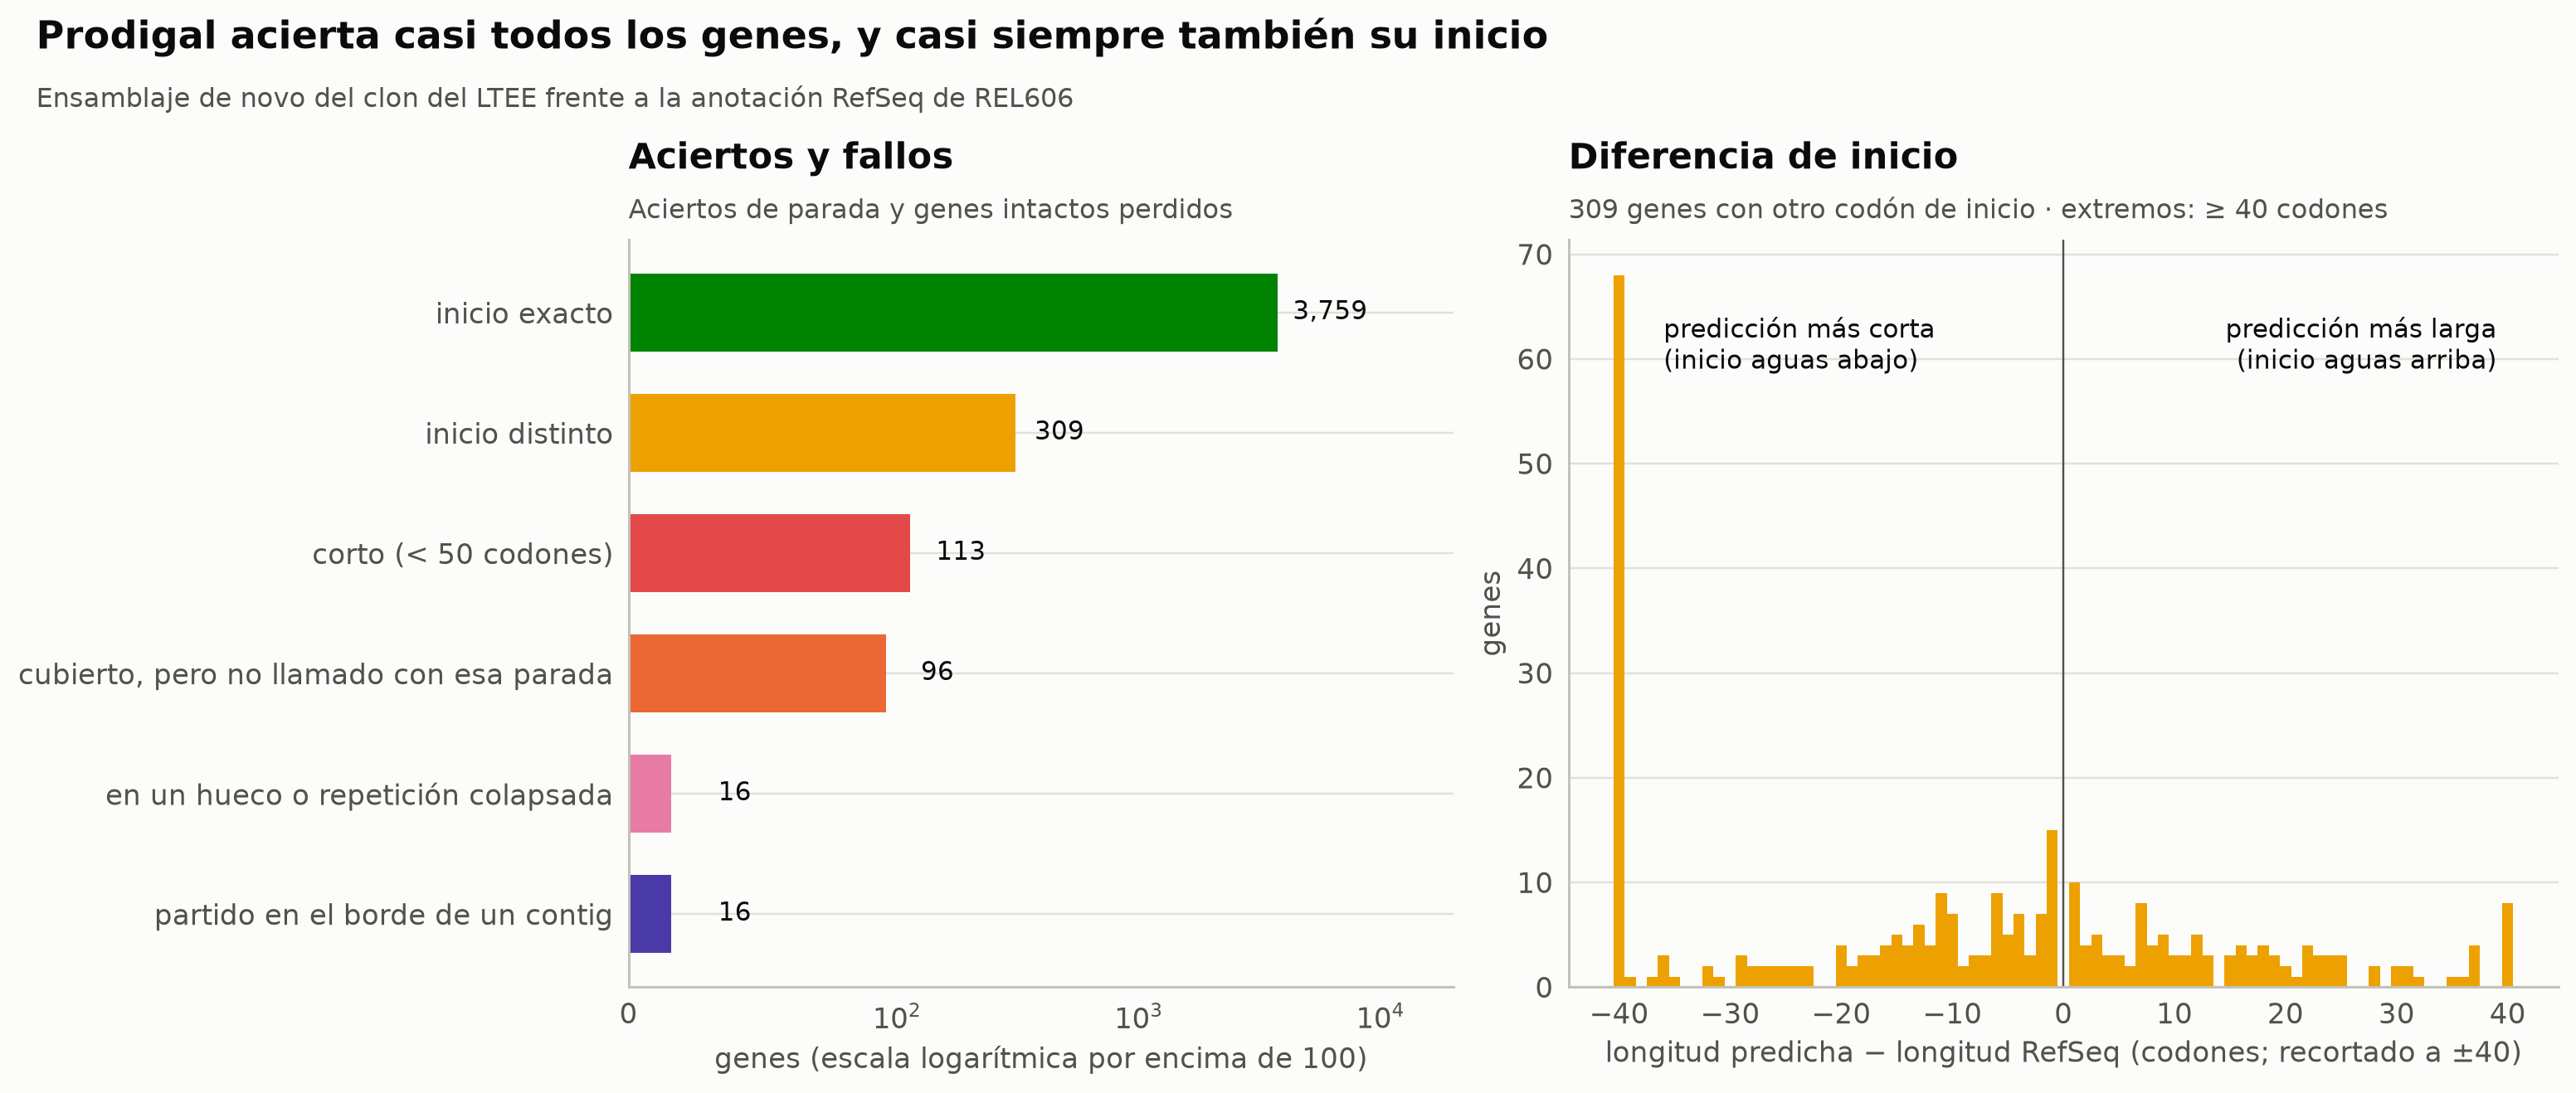

In [23]:
# Diferencias de inicio: ¿cuántos codones se equivoca Prodigal cuando acierta la parada pero no el inicio?
hits = pred[pred.match & ~pred.partial].copy()
hits["true_len"] = [min(truth_len[k], key=lambda t: abs(t - l)) for k, l in zip(hits.endk, hits.length)]
hits["delta_codons"] = (hits.length - hits.true_len) // 3
wrong = hits[hits.delta_codons != 0]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw=dict(width_ratios=[1, 1.2]))
lab = ["inicio exacto", "inicio distinto"] + list(causes.index)
val = [int((hits.delta_codons == 0).sum()), len(wrong)] + list(causes.values)
col = [ec.GREEN, ec.YELLOW] + [ec.RED, ec.ORANGE, ec.MAGENTA, ec.VIOLET][:len(causes)]
yy = np.arange(len(lab))[::-1]
a1.barh(yy, val, color=col, height=0.65)
for y, v in zip(yy, val):
    a1.text(v * 1.15 + 15, y, f"{v:,}", va="center", fontsize=10)
a1.set_yticks(yy, lab); a1.set_xscale("symlog", linthresh=100); a1.set_xlim(0, 20000)
a1.set_xlabel("genes (escala logarítmica por encima de 100)")
ec.title(a1, "Aciertos y fallos", "Aciertos de parada y genes intactos perdidos")
d = wrong.delta_codons.clip(-40, 40)
a2.hist(d, bins=np.arange(-40.5, 41.5, 1), color=ec.YELLOW, edgecolor="white")
a2.axvline(0, color=ec.INK_2, lw=0.8)
a2.text(-36, a2.get_ylim()[1] * 0.9, "predicción más corta\n(inicio aguas abajo)", fontsize=10, va="top")
a2.text(39, a2.get_ylim()[1] * 0.9, "predicción más larga\n(inicio aguas arriba)", fontsize=10, va="top", ha="right")
a2.set_xlabel("longitud predicha − longitud RefSeq (codones; recortado a ±40)"); a2.set_ylabel("genes")
ec.title(a2, "Diferencia de inicio", f"{len(wrong)} genes con otro codón de inicio · extremos: ≥ 40 codones")
ec.fig_title(fig, "Prodigal acierta casi todos los genes, y casi siempre también su inicio",
             "Ensamblaje de novo del clon del LTEE frente a la anotación RefSeq de REL606")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la inmensa mayoría de los genes se predice con parada **e** inicio exactos.
> Contra lo que uno esperaría, el ensamblaje apenas tiene la culpa: sólo unas decenas de genes caen en **huecos o
> repeticiones colapsadas** (secuencias IS, ARNr) o quedan **partidos** en el borde de un contig. La mayoría de los
> fallos son del **predictor**: genes **cortos** (menos de 50 codones, donde la señal estadística es débil y Prodigal
> es conservador) y genes cubiertos pero no llamados, casi siempre "proteínas hipotéticas", toxinas pequeñas de
> sistemas toxina-antitoxina y restos de profagos, justo los genes atípicos cuyo sabor no se parece al del resto
> del genoma. A la derecha, la mayoría de los inicios discrepantes está a menos de 25 codones: son `ATG`, `GTG` o
> `TTG` alternativos en el mismo marco, justo lo que el modelo de RBS de Prodigal intenta resolver. Llama la atención la
> barra de la izquierda: unas decenas de genes que Prodigal predice **40 codones o más** más cortos que RefSeq, porque
> eligió un inicio muy aguas abajo (a menudo donde encontró un RBS convincente). Parte de esas discrepancias son errores de **RefSeq**, no de Prodigal: el
> codón de inicio de muchos genes nunca se ha verificado experimentalmente.

### Nuestro propio predictor frente a Prodigal

¿Cuánto de ese rendimiento se debe al modelo de Márkov y cuánto a los refinamientos de Prodigal? Construyamos un
predictor mínimo con lo aprendido, en el espíritu de GeneMark y Glimmer:

1. **Candidatos:** el ORF más largo por codón de parada (inicio `ATG`, `GTG` o `TTG`), de al menos 60 codones.
2. **Autoentrenamiento:** Márkov de fase de orden 5 con los ORFs de $\ge 300$ codones del **propio ensamblaje**; modelo
   nulo: Márkov homogéneo de orden 5 de todo el ensamblaje (ambas hebras).
3. **Puntuación:** LLR total en bits (ecuación 8.18) con sumas acumuladas; se aceptan los ORFs con LLR > 0.
4. **Solapamientos:** de mayor a menor puntuación, se descarta un candidato si se solapa más de 60 pb con uno ya
   aceptado (en cualquier hebra).

In [24]:
START3 = {"ATG", "GTG", "TTG"}

def candidate_orfs(s, min_codons=60):
    """El ORF más largo por parada (ATG/GTG/TTG), 6 marcos; coordenadas en la hebra del ORF (0-based)."""
    out = []
    for strand, h in ((1, s), (-1, revcomp(s))):
        x = encode(h); n = len(x) - 2
        code = x[:n] * 16 + x[1:n + 1] * 4 + x[2:n + 2]
        is_stop = np.isin(code, STOP_CODES); is_start = np.isin(code, [14, 46, 62])   # ATG, GTG, TTG
        for f in range(3):
            st = np.flatnonzero(is_stop[f::3]); at = np.flatnonzero(is_start[f::3])
            if len(st) == 0 or len(at) == 0:
                continue
            prev = np.r_[-1, st[:-1]]; j = np.searchsorted(at, prev + 1)
            first = np.where(j < len(at), at[np.minimum(j, len(at) - 1)], 1 << 60)
            ok = (first < st) & (st - first >= min_codons)
            out += [(strand, f + 3 * a, f + 3 * b + 3) for a, b in zip(first[ok], st[ok])]
    return out

def train_self(seqs, m=5):
    C = np.ones((3, 4 ** m, 4)); Q = np.ones((4 ** m, 4))
    for s in seqs.values():
        hs = {1: s, -1: revcomp(s)}
        for strand, a, b in candidate_orfs(s, 300):
            if hs[strand][a:b - 3][:3] != "ATG":
                continue
            x = encode(hs[strand][a:b - 3]); c = contexts(x, m); ph = np.arange(len(x)) % 3
            np.add.at(C, (ph[m:], c[m:], x[m:]), 1)
        for h in hs.values():
            x = encode(h); c = contexts(x, m); np.add.at(Q, (c[m:], x[m:]), 1)
    return np.log2(C / C.sum(2, keepdims=True)), np.log2(Q / Q.sum(1, keepdims=True))

def markov_gene_finder(seqs, Pc, Pn, m=5, max_overlap=60):
    rows = []
    for name, s in seqs.items():
        L, cand = len(s), candidate_orfs(s)
        scored = []
        for strand, h in ((1, s), (-1, revcomp(s))):
            x = encode(h); c = contexts(x, m); i = np.arange(len(x)); null = Pn[c, x]
            cs = []
            for f in range(3):
                v = Pc[(i - f) % 3, c, x] - null; v[:m] = 0
                cs.append(np.r_[0, np.cumsum(v)])
            for st, a, b in cand:
                if st == strand:
                    sc = cs[a % 3][b - 3] - cs[a % 3][a]
                    lo, hi = (a, b) if st == 1 else (L - b, L - a)
                    scored.append((sc, st, lo, hi))
        taken = []
        for sc, st, lo, hi in sorted(scored, reverse=True):
            if sc <= 0:
                break
            if all(min(hi, h2) - max(lo, l2) <= max_overlap for l2, h2 in taken):
                taken.append((lo, hi))
                endk = s[hi - K:hi] if st == 1 else revcomp(s[lo:lo + K])
                rows.append((name, lo + 1, hi, st, hi - lo, sc, endk, lo < 3 or hi > L - 3))
    return pd.DataFrame(rows, columns=["contig", "begin", "end", "strand", "length", "llr_bits", "endk", "partial"])

t0 = time.time()
Pc_self, Pn_self = train_self(contigs)
own = markov_gene_finder(contigs, Pc_self, Pn_self)
print(f"Predictor propio: {len(own):,} genes en {time.time() - t0:.1f} s")
comparison = pd.concat([metrics.iloc[:, 0], evaluate(own, "Márkov de fase propio")], axis=1)
pretty(comparison)

Predictor propio: 3,776 genes en 1.0 s


,Prodigal (pyrodigal),Márkov de fase propio
predicciones,"4,280","3,776"
completas,"4,217","3,771"
precisión (todas),95.7%,97.9%
precisión (completas),96.5%,97.9%
"sensibilidad (genes intactos, parada única)",94.4%,85.6%
sensibilidad (todos los CDS),93.8%,84.3%
inicio exacto (entre aciertos),91.8%,64.8%


> 🔎 **Qué observamos.** Nuestro predictor de unas pocas decenas de líneas es **preciso** (casi todas sus predicciones
> son genes reales), pero pierde sensibilidad (sobre todo en genes de menos de 60 codones, que ni siquiera considera,
> y en genes solapados que la regla voraz descarta) y, sobre todo, falla el **inicio**: elige siempre el codón de
> inicio más lejano, y acierta sólo en unos dos tercios de los casos. La diferencia con Prodigal está en lo que éste
> añade al modelo de contenido: el **RBS**, el tipo de codón de inicio, la programación dinámica sobre solapamientos y
> un tratamiento cuidadoso de los genes cortos. Esa es la historia del campo entre 1993 y 2010.

### La región de 250 kb: el ensamblaje de la lección 8.3

En la lección 8.3 ensamblamos también, con lecturas reclutadas por mapeo, la región 3 950 001–4 200 000 de REL606. La
anotamos con el modelo de Prodigal ya entrenado (250 kb es poco para entrenar bien, y un laboratorio usaría el modelo
de un genoma emparentado) y la ubicamos con las mismas anclas.

In [25]:
region_ctg = read_fasta("REL606_3950k-4200k_spades_contigs.fasta.gz")
region_ctg = {k: v for k, v in region_ctg.items() if len(v) >= 500}
R0, R1 = 3_950_000, 4_200_000
rb = anchor_blocks(region_ctg)
main_blk = rb.loc[rb.groupby("contig").anchors.idxmax()].set_index("contig")
inside = main_blk[(main_blk.r0 >= R0 - 1000) & (main_blk.r1 <= R1 + 1000)]
print(f"{len(region_ctg)} contigs ≥ 500 pb · ubicados: {len(main_blk)} · dentro de la región: {len(inside)}")
print("Sin anclas únicas:", [n.split("_length")[0] + f" ({len(region_ctg[n])} pb, {n.split('_cov_')[1][:5]}×)"
                             for n in region_ctg if n not in main_blk.index])
print(main_blk[["q1", "strand", "r0", "r1", "anchors"]].assign(
    cobertura=[float(n.split("_cov_")[1]) for n in main_blk.index]).round(1).to_string())

rows = []
for name, s in region_ctg.items():
    for g in finder.find_genes(s.encode()):
        endk = s[g.end - K:g.end] if g.strand == 1 else revcomp(s[g.begin - 1:g.begin - 1 + K])
        rows.append((name, g.begin, g.end, g.strand, g.end - g.begin + 1, g.partial_begin or g.partial_end,
                     g.start_type, g.rbs_motif, round(g.score, 1), endk))
pred_reg = pd.DataFrame(rows, columns=["contig", "begin", "end", "strand", "length", "partial", "start_type",
                                       "rbs_motif", "score", "endk"])
own_reg = markov_gene_finder(region_ctg, Pc_self, Pn_self)
truth_reg = cds_ref[(cds_ref.start > R0) & (cds_ref.end <= R1)]
for lab_, p in (("Prodigal", pred_reg), ("propio", own_reg)):
    f = truth_reg.endk.isin(set(p.endk))
    print(f"{lab_:9s}: {len(p)} predicciones · sensibilidad en la región {f.mean():.1%} "
          f"({f.sum()}/{len(truth_reg)}) · precisión {p.endk.isin(truth_len).mean():.1%}")

12 contigs ≥ 500 pb · ubicados: 7 · dentro de la región: 6
Sin anclas únicas: ['NODE_7 (1444 pb, 13.14×)', 'NODE_8 (1376 pb, 58.12×)', 'NODE_9 (1183 pb, 56.41×)', 'NODE_10 (1116 pb, 54.16×)', 'NODE_11 (913 pb, 28.00×)']
                                      q1  strand       r0       r1  anchors  cobertura
contig                                                                                
NODE_12_length_707_cov_0.720635      631      -1  2652895  2653526       10        0.7
NODE_1_length_91493_cov_14.928590  91381       1  4019124  4110205     1818       14.9
NODE_2_length_57186_cov_15.656131  57081       1  3949171  4006252     1140       15.7
NODE_3_length_36521_cov_15.173280  35931       1  4151549  4187430      699       15.2
NODE_4_length_36077_cov_15.628028  35981       1  4110259  4146140      716       15.6
NODE_5_length_8271_cov_12.736392    8181       1  4192810  4200941      156       12.7
NODE_6_length_7632_cov_15.104831    7531      -1  4006303  4013534      145       15

> 🔎 **Qué observamos.** Los seis contigs largos (cobertura ~15×) caen dentro de la región y la cubren casi entera;
> allí Prodigal recupera el 97 % de los genes. Los demás contigs no se ubican en la región: los cortos de cobertura
> ~55× no tienen anclas únicas (son ARNr: como las lecturas se reclutaron por mapeo, las de los **siete** operones de
> ARNr del genoma, casi idénticos, cayeron aquí) y uno de cobertura ínfima (0,7×) se ancla a 2,65 Mb, fuera de la
> región: lecturas mal reclutadas. Es una lección real: un ensamblaje "de una región" hereda las repeticiones de todo
> el genoma.

### 🧭 Navegador genómico: RefSeq, Prodigal y nuestro predictor

Pasamos cada predicción a coordenadas de REL606 con su bloque de anclas y las dibujamos junto a los genes de RefSeq.
Haga zoom (arrastre) y pase el ratón por los genes: verá su producto, longitud, codón de inicio, motivo RBS y si
acertó la parada y el inicio.

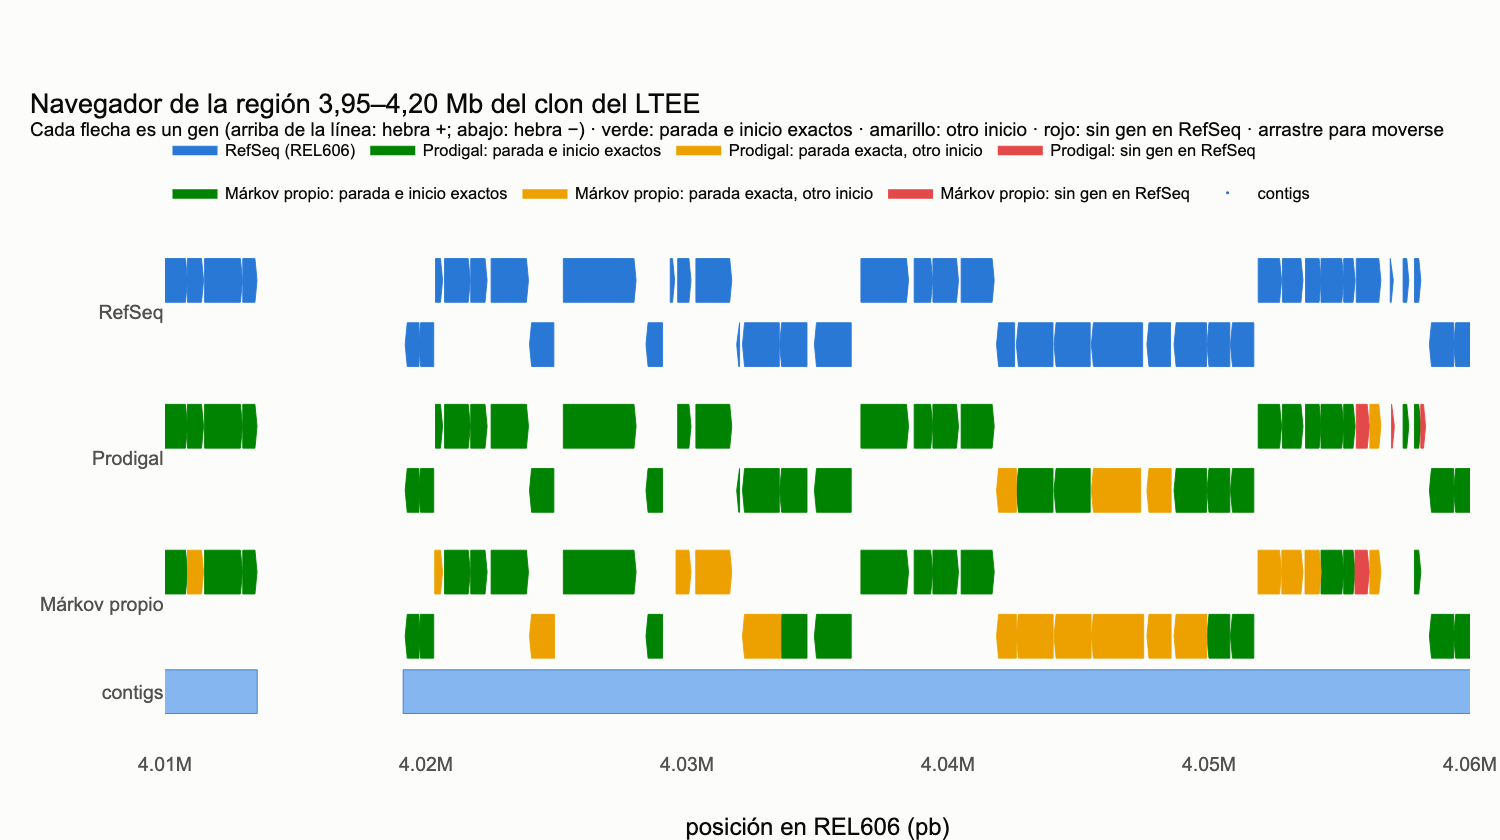

In [26]:
def to_ref(df, blk):
    """Coordenadas REL606 (0-based, semiabierto) y hebra de cada predicción, vía el bloque principal de su contig."""
    out = []
    for r in df.itertuples():
        if r.contig not in blk.index:
            out.append((np.nan, np.nan, 0)); continue
        b = blk.loc[r.contig]
        if b.strand == 1:
            lo, hi = b.diag + r.begin - 1, b.diag + r.end
        else:
            lo, hi = b.diag - r.end + KA, b.diag - r.begin + 1 + KA
        out.append((lo, hi, r.strand * b.strand))
    return pd.DataFrame(out, columns=["r_lo", "r_hi", "r_strand"], index=df.index)

pred_reg = pred_reg.join(to_ref(pred_reg, main_blk))
own_reg = own_reg.join(to_ref(own_reg, main_blk))
prod_by_k = {k: p for k, p in zip(cds_ref.endk, cds_ref["product"])}

def status(df):
    st = []
    for k, l in zip(df.endk, df.length):
        if k not in truth_len:
            st.append("sin gen en RefSeq")
        elif l in truth_len[k]:
            st.append("parada e inicio exactos")
        else:
            st.append("parada exacta, otro inicio")
    return st

pred_reg["status"], own_reg["status"] = status(pred_reg), status(own_reg)
ST_COL = {"parada e inicio exactos": ec.GREEN, "parada exacta, otro inicio": ec.YELLOW, "sin gen en RefSeq": ec.RED}

fig = go.Figure()
def add_track(df, y0, name, hover, color):
    """Todas las flechas de una pista en una sola traza de polígonos (liviana) + un punto invisible por gen
    en su centro que lleva el texto del cursor."""
    xs, ys, mx, my = [], [], [], []
    for lo, hi, st in df[["lo", "hi", "st"]].itertuples(index=False):
        y = y0 + (0.22 if st > 0 else -0.22)
        tip = max(lo, hi - 80) if st > 0 else min(hi, lo + 80)
        if st > 0:
            xs += [lo, tip, hi, tip, lo, lo, None]
        else:
            xs += [hi, tip, lo, tip, hi, hi, None]
        ys += [y - .15, y - .15, y, y + .15, y + .15, y - .15, None]
        mx.append((lo + hi) / 2); my.append(y)
    fig.add_trace(go.Scatter(x=xs, y=ys, fill="toself", mode="lines", line=dict(width=0.6, color=color),
                             fillcolor=color, name=name, hoverinfo="skip", legendgroup=name))
    fig.add_trace(go.Scatter(x=mx, y=my, mode="markers", marker=dict(size=12, color=color, opacity=0),
                             hovertext=hover, hoverinfo="text", showlegend=False, legendgroup=name))

ref_tr = truth_reg.assign(lo=truth_reg.start - 1, hi=truth_reg.end, st=np.where(truth_reg.strand == "+", 1, -1))
add_track(ref_tr, 3, "RefSeq (REL606)",
          [f"<b>{r.gene if isinstance(r.gene, str) else r.locus_tag}</b> · {r.product}<br>{r.start:,}–{r.end:,} "
           f"({r.strand}) · {r.length} pb<br>{'encontrado por Prodigal' if r.endk in set(pred_reg.endk) else 'NO encontrado por Prodigal'}"
           for r in ref_tr.itertuples()], ec.BLUE)
for y0, df, name in ((2, pred_reg, "Prodigal"), (1, own_reg, "Márkov propio")):
    d = df.dropna(subset=["r_lo"]).assign(lo=lambda t: t.r_lo, hi=lambda t: t.r_hi, st=lambda t: t.r_strand)
    for stt, colr in ST_COL.items():
        sub = d[d.status == stt]
        hov = [f"<b>{name}</b> · {r.status}<br>{prod_by_k.get(r.endk, '—')}<br>contig {r.contig.split('_length')[0]} "
               f"{r.begin:,}–{r.end:,} · {r.length} pb"
               + (f"<br>inicio {r.start_type} · RBS {r.rbs_motif}" if name == "Prodigal" else f"<br>LLR {r.llr_bits:.0f} bits")
               for r in sub.itertuples()]
        add_track(sub, y0, f"{name}: {stt}", hov, colr)
blk_in = rb[(rb.r0 < R1) & (rb.r1 > R0)]
for r in blk_in.itertuples():
    fig.add_shape(type="rect", x0=r.r0, x1=r.r1, y0=0.25, y1=0.55, fillcolor=ec.SEQ_BLUE[3], line_width=0.5,
                  line_color=ec.SEQ_BLUE[8])
fig.add_trace(go.Scatter(x=(blk_in.r0 + blk_in.r1) / 2, y=[0.4] * len(blk_in), mode="markers",
                         marker=dict(size=1, color=ec.SEQ_BLUE[8]), name="contigs",
                         text=[f"{r.contig.split('_length')[0]} · {r.q1 - r.q0:,} pb anclados · hebra {'+' if r.strand > 0 else '−'}"
                               for r in blk_in.itertuples()], hoverinfo="text"))
fig.update_yaxes(tickvals=[0.4, 1, 2, 3], ticktext=["contigs", "Márkov propio", "Prodigal", "RefSeq"],
                 range=[0, 3.6], showgrid=False)
fig.update_xaxes(title_text="posición en REL606 (pb)", range=[4_010_000, 4_060_000])
fig.update_layout(height=560, margin=dict(t=150, l=110, r=20, b=60),
                  title="Navegador de la región 3,95–4,20 Mb del clon del LTEE<br><sup>Cada flecha es un gen (arriba de "
                        "la línea: hebra +; abajo: hebra −) · verde: parada e inicio exactos · amarillo: otro inicio · "
                        "rojo: sin gen en RefSeq · arrastre para moverse</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0, font=dict(size=11)))
fig.show()

> 🔎 **Qué observamos.** La vista inicial muestra 50 kb (use el zoom para recorrer toda la región). Las dos pistas de
> predicción siguen a RefSeq gen por gen; los amarillos (otro inicio) son mucho más frecuentes en nuestro predictor, y
> los pocos rojos suelen ser genes parciales en el borde de un contig o ORFs cortos sin gen anotado. Donde termina un
> bloque de contig, la pista de predicciones se interrumpe: el gen que cruzaba ese borde queda partido.

### Pistas de ARN ribosómico: repeticiones que el ensamblaje colapsa

Los genes de ARNr no se traducen, así que Prodigal no los ve. Prokka usa barrnap (modelos de perfil de Rfam) y Bakta
usa Infernal. Nosotros haremos una búsqueda sencilla por **contenido de $k$-mers**: tomamos los ARNr 16S, 23S y 5S de
*E. coli* K-12 (otra cepa: no hacemos trampa con REL606) y medimos qué fracción de sus 21-mers aparece en cada contig.

In [27]:
rrna_k12 = cds_k12[cds_k12.type == "rRNA"]
ref_rrna = {}
for lab_ in ("16S", "23S", "5S"):
    r = rrna_k12[rrna_k12["product"].str.contains(lab_)].iloc[0]
    ref_rrna[lab_] = gene_seq(r)

# Diccionario 21-mer → (ARNr, posición), con ambas orientaciones
kmer_index = {}
for lab_, s in ref_rrna.items():
    for i in range(len(s) - 20):
        kmer_index[s[i:i + 21]] = (lab_, i)
        kmer_index[revcomp(s[i:i + 21])] = (lab_, i)
n_kmers = {lab_: len(s) - 20 for lab_, s in ref_rrna.items()}
hits_rrna = []
for name, c in contigs.items():
    seen = {kmer_index[c[i:i + 21]] for i in range(len(c) - 20) if c[i:i + 21] in kmer_index}
    for lab_ in ref_rrna:
        frac = sum(1 for l, _ in seen if l == lab_) / n_kmers[lab_]
        if frac > 0.1:
            hits_rrna.append((lab_, name.split("_length")[0], len(c), ctg_cov[name], round(frac, 2)))
hits_rrna = pd.DataFrame(hits_rrna, columns=["ARNr", "contig", "longitud", "cobertura k-mer", "fracción de 21-mers"])
genome_cov = np.median(np.repeat(ctg_cov.values, (ctg_len.values // 1000)))
print(f"Cobertura k-mer mediana del genoma: {genome_cov:.0f}×")
hits_rrna.assign(**{"copias estimadas": (hits_rrna["cobertura k-mer"] / genome_cov).round(1)})

Cobertura k-mer mediana del genoma: 39×


,ARNr,contig,longitud,cobertura k-mer,fracción de 21-mers,copias estimadas
0,16S,NODE_4,195078,44.594782,0.96,1.1
1,5S,NODE_6,158779,42.240936,1.00,1.1
2,5S,NODE_16,97805,40.514878,0.47,1.0
3,5S,NODE_18,91282,38.699742,0.45,1.0
4,5S,NODE_20,81986,39.542944,0.52,1.0
5,5S,NODE_42,36005,40.069361,0.16,1.0
6,23S,NODE_80,2086,292.220508,0.65,7.4
7,23S,NODE_88,929,293.771127,0.29,7.4


> 🔎 **Qué observamos.** El 16S aparece completo en un contig largo de cobertura normal (una copia que el ensamblador
> pudo colocar), pero el **23S** está en contigs cortos con cobertura unas **7 veces** mayor que la del genoma:
> *E. coli* tiene **siete** operones de ARNr casi idénticos, y SPAdes los colapsó en una sola copia. La cobertura es
> la pista: cuenta cuántas copias hay aunque el ensamblaje sólo muestre una. REL606 tiene 22 genes de ARNr y 85 de
> ARNt en RefSeq; buscarlos bien exige los modelos de covarianza de Infernal o tRNAscan-SE, que usan también la
> estructura secundaria.

La figura siguiente resume la relación entre longitud y cobertura de todos los contigs: es la forma más rápida de
reconocer repeticiones colapsadas en cualquier ensamblaje.

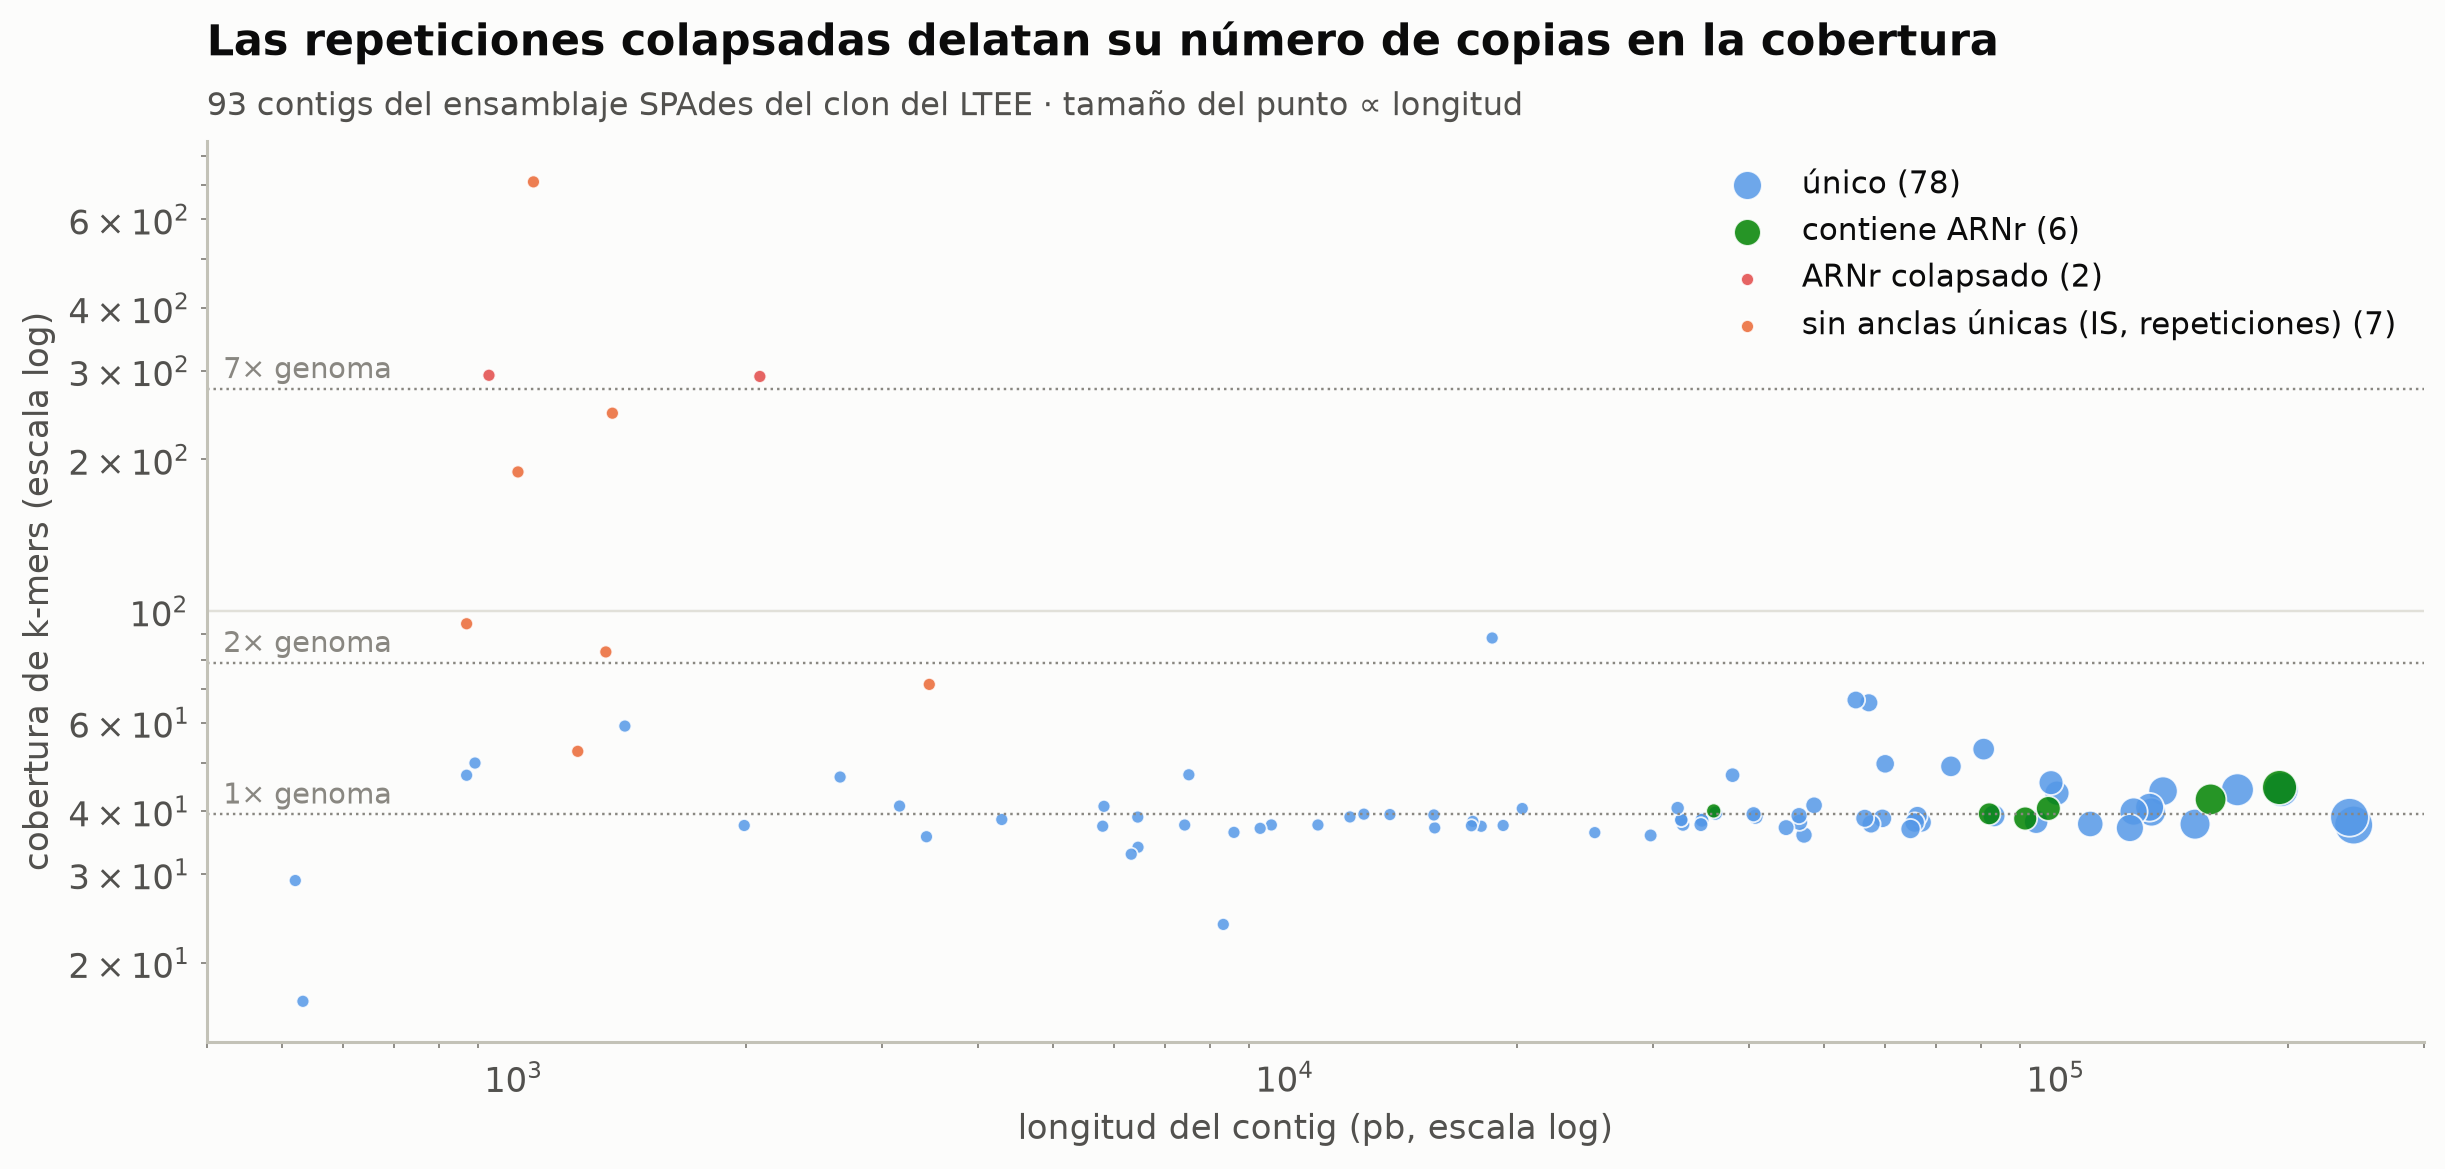

In [28]:
rrna_ctg = set(hits_rrna.contig)
kind = []
for n in contigs:
    short = n.split("_length")[0]
    if short in rrna_ctg and ctg_cov[n] > 2 * genome_cov:
        kind.append("ARNr colapsado")
    elif short in rrna_ctg:
        kind.append("contiene ARNr")
    elif n not in placed.index:
        kind.append("sin anclas únicas (IS, repeticiones)")
    else:
        kind.append("único")
kind = pd.Series(kind, index=list(contigs))
fig, ax = plt.subplots(figsize=(11, 5.2))
KCOL = {"único": ec.SEQ_BLUE[5], "contiene ARNr": ec.GREEN, "ARNr colapsado": ec.RED,
        "sin anclas únicas (IS, repeticiones)": ec.ORANGE}
for k, colr in KCOL.items():
    m = kind == k
    ax.scatter(ctg_len[m], ctg_cov[m], s=np.clip(ctg_len[m] / 1500, 18, 160), color=colr, alpha=0.85,
               edgecolor="white", lw=0.6, label=f"{k} ({m.sum()})")
for mult in (1, 2, 7):
    ax.axhline(genome_cov * mult, color=ec.MUTED, lw=0.8, ls=":")
    ax.text(420, genome_cov * mult * 1.05, f"{mult}× genoma", fontsize=9.5, color=ec.MUTED, ha="left")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(400, 300_000)
ax.set_xlabel("longitud del contig (pb, escala log)"); ax.set_ylabel("cobertura de k-mers (escala log)")
ax.legend(loc="upper right", frameon=False, fontsize=10)
ec.title(ax, "Las repeticiones colapsadas delatan su número de copias en la cobertura",
         "93 contigs del ensamblaje SPAdes del clon del LTEE · tamaño del punto ∝ longitud")
plt.show()

> 🔎 **Qué observamos.** Los contigs únicos forman una nube horizontal en ~1× la cobertura del genoma. Los contigs
> cortos de cobertura muy alta, sin anclas únicas, son **secuencias de inserción** (IS1, IS150… abundantes en
> REL606) y el ARNr colapsado. Sus ORFs (transposasas) son genes reales, pero su **posición** en el genoma se perdió
> en el ensamblaje: la anotación los contará una vez aunque haya muchas copias. Este es el motivo biológico por el
> que la anotación empieza por **enmascarar** repeticiones, sobre todo en eucariotas (sección 8).

---

## 7. Genes eucariotas: HMM generalizados y Viterbi en *TP53*

### Una frase con gramática

En una bacteria, un gen es una palabra larga sin interrupciones. En un eucariota es una **frase con gramática**:
región intergénica, codón de inicio, exón, sitio **donador** (`GT`), intrón, sitio **aceptor** (`AG`), exón… y codón
de parada. Piense en una receta escrita en una revista, interrumpida por anuncios: para cocinar hay que saltar los
anuncios (intrones) y leer los tramos de receta (exones) **en orden y sin perder el hilo**, aunque el anuncio corte una
palabra por la mitad. Eso último es crucial: un intrón puede interrumpir un codón después de su primera o su segunda
base, y el exón siguiente debe continuar el marco donde quedó.

Un **modelo oculto de Márkov** (lección 4.3) describe esa gramática: cada **estado** oculto es un tipo de región, cada
estado **emite** bases con su propio modelo (una cadena de Márkov de fase para los exones, otra para los intrones) y
las **transiciones** codifican el orden permitido. La figura reproduce el esquema del libro (figura 8.14).

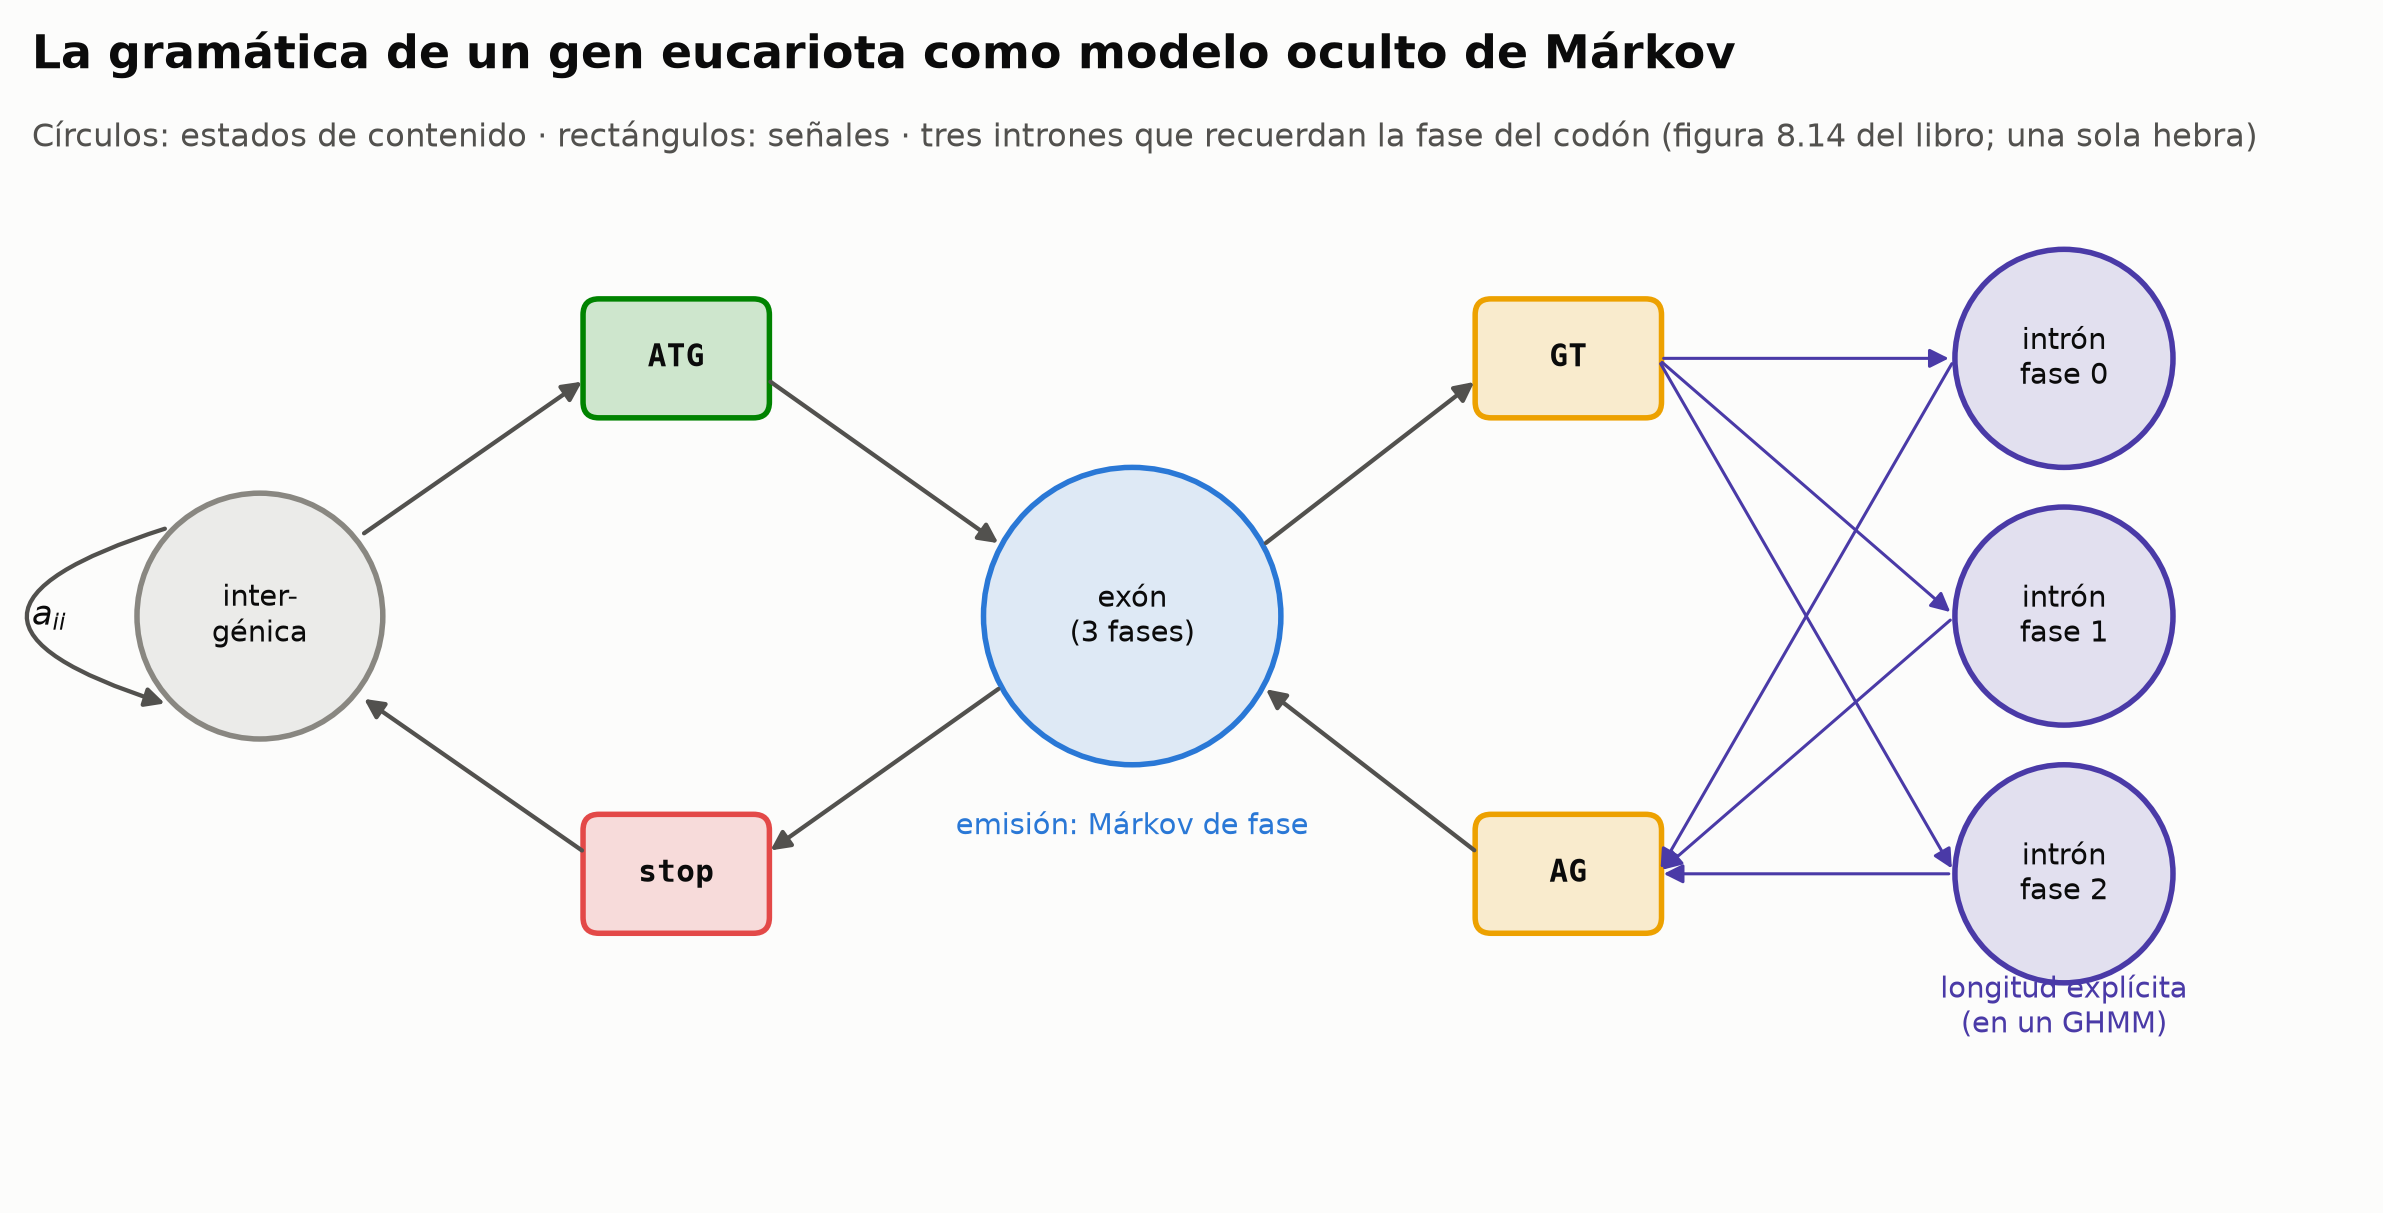

In [29]:
fig, ax = plt.subplots(figsize=(12.5, 5.4))
ax.set_xlim(-1.2, 10.6); ax.set_ylim(-2.9, 3.0); ax.axis("off"); ax.set_aspect("equal")
def circ(x, y, text, color, r=0.62):
    ax.add_patch(Circle((x, y), r, fc=mpl.colors.to_rgba(color, 0.14), ec=color, lw=1.8))
    ax.text(x, y, text, ha="center", va="center", fontsize=9.5)
def rbox(x, y, text, color):
    ax.add_patch(FancyBboxPatch((x - 0.45, y - 0.28), 0.9, 0.56, boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=mpl.colors.to_rgba(color, 0.18), ec=color, lw=1.8))
    ax.text(x, y, text, ha="center", va="center", fontsize=10, family="monospace", fontweight="bold")
def arr(p, q, color=ec.INK_2, rad=0.0, lw=1.4):
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle="-|>", mutation_scale=13, color=color, lw=lw,
                                 connectionstyle=f"arc3,rad={rad}"))
circ(0, 0, "inter-\ngénica", ec.MUTED); rbox(2.1, 1.3, "ATG", ec.GREEN); rbox(2.1, -1.3, "stop", ec.RED)
circ(4.4, 0, "exón\n(3 fases)", ec.BLUE, r=0.75); rbox(6.6, 1.3, "GT", ec.YELLOW); rbox(6.6, -1.3, "AG", ec.YELLOW)
for k, y in enumerate((1.3, 0, -1.3)):
    circ(9.1, y, f"intrón\nfase {k}", ec.VIOLET, r=0.55)
    arr((7.05, 1.3), (8.55, y), ec.VIOLET, lw=1); arr((8.55, y), (7.05, -1.3), ec.VIOLET, lw=1)
arr((0.5, 0.4), (1.65, 1.2)); arr((2.55, 1.2), (3.75, 0.35)); arr((3.75, -0.35), (2.55, -1.2)); arr((1.65, -1.2), (0.5, -0.4))
arr((5.05, 0.35), (6.15, 1.2)); arr((6.15, -1.2), (5.05, -0.35))
ax.add_patch(FancyArrowPatch((-0.45, 0.45), (-0.45, -0.45), arrowstyle="-|>", mutation_scale=13, color=ec.INK_2,
                             connectionstyle="arc3,rad=1.6", lw=1.4))
ax.text(-1.15, 0, "$a_{ii}$", fontsize=11, va="center")
ax.text(4.4, -1.1, "emisión: Márkov de fase", ha="center", fontsize=9.5, color=ec.BLUE)
ax.text(9.1, -2.1, "longitud explícita\n(en un GHMM)", ha="center", fontsize=9.5, color=ec.VIOLET)
ax.text(-1.15, 2.95, "La gramática de un gen eucariota como modelo oculto de Márkov", fontsize=15,
        fontweight="bold", va="top")
ax.text(-1.15, 2.5, "Círculos: estados de contenido · rectángulos: señales · tres intrones que recuerdan la fase del codón "
        "(figura 8.14 del libro; una sola hebra)", fontsize=10.5, color=ec.INK_2, va="top")
plt.show()

> 🔎 **Qué observamos.** El único camino permitido es el de la gramática: intergénica → `ATG` → exón → (`GT` →
> intrón → `AG` → exón)* → parada → intergénica. Los tres estados de intrón no son un capricho: el intrón de "fase 1"
> interrumpió un codón después de su primera base, así que el exón que sigue debe empezar por la **segunda** base de
> ese codón.

### Ecuación 8.19: el algoritmo de Viterbi

Anotar una secuencia $x_1\cdots x_T$ es encontrar la sucesión de estados $\pi^\ast$ más probable. Llamando $V_j(t)$ a la
log-probabilidad del mejor camino que termina en el estado $j$ tras emitir $x_1\cdots x_t$:

$$
V_j(t) = \log e_j(x_t) + \max_{i}\bigl[\,V_i(t-1) + \log a_{ij}\,\bigr],
\qquad
\pi^\ast = \arg\max_{\pi}\ \Pr(x,\pi).
$$

| Símbolo | Significado |
|---|---|
| $a_{ij}$ | probabilidad de transición del estado $i$ al $j$ (p. ej., de exón a sitio donador) |
| $e_j(x_t)$ | probabilidad de que el estado $j$ emita la base $x_t$ (dado su contexto) |
| $V_j(t)$ | log-probabilidad del mejor camino de estados que explica $x_1\cdots x_t$ y acaba en $j$ |
| $\pi^\ast$ | anotación más probable: la etiqueta (intergénica, exón, intrón…) de cada base |

Es la programación dinámica de Needleman-Wunsch (lección 3.2), ahora sobre estados en lugar de columnas, con coste
$O(T\,|Q|^2)$ para $|Q|$ estados. Al final, se retrocede desde el mejor estado en $T$ siguiendo los punteros
(*traceback*).

### Ejemplo a mano: exón o intrón, base a base

Un modelo de juguete con dos estados: **E** (exón, algo rico en GC: $e_E(G)=e_E(C)=0{,}3$, $e_E(A)=e_E(T)=0{,}2$) e
**I** (intrón, rico en AT: $e_I(A)=e_I(T)=0{,}3$, $e_I(G)=e_I(C)=0{,}2$). Transiciones: quedarse, 0,9; cambiar, 0,1.
Inicio: 0,5 cada uno. Secuencia $x = $ `GC…`. En logaritmos en base 2:

* $t=1$ (G): $V_E(1)=\log_2(0{,}5\cdot0{,}3)=-2{,}74$; $\;V_I(1)=\log_2(0{,}5\cdot0{,}2)=-3{,}32$.
* $t=2$ (C): $V_E(2)=\log_2 0{,}3+\max(-2{,}74+\log_2 0{,}9,\ -3{,}32+\log_2 0{,}1) = -1{,}74+\max(-2{,}89,\,-6{,}64)=-4{,}63$
  (viene de E); $\;V_I(2)=\log_2 0{,}2+\max(-2{,}74+\log_2 0{,}1,\ -3{,}32+\log_2 0{,}9)=-2{,}32-3{,}47=-5{,}79$ (viene de I).

Cambiar de estado cuesta $\log_2 0{,}1-\log_2 0{,}9 = -3{,}17$ bits, y cada base AT en el intrón sólo aporta
$\log_2(0{,}3/0{,}2)=+0{,}58$ bits. Un intrón **entre dos exones** exige **dos** cambios (entrar y salir):
$2 \times 3{,}17 = 6{,}34$ bits, así que hace falta un tramo de **al menos** $6{,}34/0{,}58 \approx 10{,}8$, es decir,
**11 bases AT** para que "pague" las dos transiciones.
Comprobémoslo con código en una secuencia más larga.

In [30]:
def viterbi_toy(x, states, log_start, log_trans, log_emit):
    T, S = len(x), len(states)
    V = np.full((T, S), -np.inf); B = np.zeros((T, S), int)
    V[0] = log_start + log_emit[:, x[0]]
    for t in range(1, T):
        cand = V[t - 1][:, None] + log_trans          # cand[i, j] = V_i(t-1) + log a_ij
        B[t] = cand.argmax(0)
        V[t] = cand.max(0) + log_emit[:, x[t]]
    path = [int(V[-1].argmax())]
    for t in range(T - 1, 0, -1):
        path.append(B[t, path[-1]])
    return V, path[::-1]

seq_toy = "GCGGCGCCGC" + "ATTATAATATTA" + "GCCGCGGCGC"
emit = np.log2(np.array([[0.2, 0.3, 0.3, 0.2],       # E: A C G T
                         [0.3, 0.2, 0.2, 0.3]]))     # I
trans = np.log2(np.array([[0.9, 0.1], [0.1, 0.9]]))
V_toy, path_toy = viterbi_toy(encode(seq_toy), ["E", "I"], np.log2([0.5, 0.5]), trans, emit)
tab = pd.DataFrame(V_toy.T, index=["V_E(t)", "V_I(t)"], columns=list(seq_toy)).round(2)
display(tab.iloc[:, :6])
print("secuencia:", seq_toy)
print("π*       :", "".join("EI"[s] for s in path_toy))
for n_at in (10, 11):                                  # umbral: 2 × 3,17 bits / 0,58 bits por base ≈ 10,8
    s_ = "GCGGCGCCGC" + seq_toy[10:10 + n_at] + "GCCGCGGCGC"
    p_ = viterbi_toy(encode(s_), ["E", "I"], np.log2([0.5, 0.5]), trans, emit)[1]
    print(f"tramo AT de {n_at} bases → π* =", "".join("EI"[s] for s in p_))

,G,C,G,G,C,G
V_E(t),-2.74,-4.63,-6.51,-8.40,-10.29,-12.18
V_I(t),-3.32,-5.80,-8.27,-10.74,-13.22,-15.69


secuencia: GCGGCGCCGCATTATAATATTAGCCGCGGCGC
π*       : EEEEEEEEEEIIIIIIIIIIIIEEEEEEEEEE
tramo AT de 10 bases → π* = EEEEEEEEEEEEEEEEEEEEEEEEEEEEEE
tramo AT de 11 bases → π* = EEEEEEEEEEIIIIIIIIIIIEEEEEEEEEE


> 🔎 **Qué observamos.** Las dos primeras columnas son las del cálculo a mano (−2,74/−3,32 y −4,63/−5,79). El camino
> óptimo etiqueta como **intrón** el tramo central rico en AT (`ATTATAATATTA`, 12 bases) y como exón los dos tramos
> GC de 10 bases: cada tramo es lo bastante largo como para pagar sus transiciones. Las dos últimas líneas confirman
> el umbral calculado a mano: con 10 bases AT todo queda como exón; con 11 aparece el intrón. Esta "inercia" de los HMM es a la vez su virtud
> (no se deja engañar por fluctuaciones) y su límite: impone longitudes **geométricas** a cada región, y los exones e
> intrones reales no tienen longitudes geométricas. Los **HMM generalizados** (GHMM) de GENSCAN (Burge y Karlin, 1997)
> y AUGUSTUS permiten que cada estado emita un segmento entero con una distribución de longitud arbitraria.

### Las señales de empalme: `GT…AG` y algo más

Los sitios donador y aceptor no son sólo `GT` y `AG`: las bases vecinas también están sesgadas. Las aprenderemos de
datos reales: los **23 genes codificantes** completos (con su transcrito más largo) de 300 kb del cromosoma 17 humano alrededor
de *TP53* (GRCh38, 7,40–7,70 Mb; anotación RefSeq curada de UCSC, la misma región de la lección 4.3). Dejamos **fuera**
a *TP53*: será nuestro examen.

Genes de entrenamiento: 23 · bases codificantes 35,124 · intrones 152 (122,766 pb)
Donadores GT: 150/152 · aceptores AG: 151/152 · otros donadores: Counter({'GC': 1, 'CA': 1})


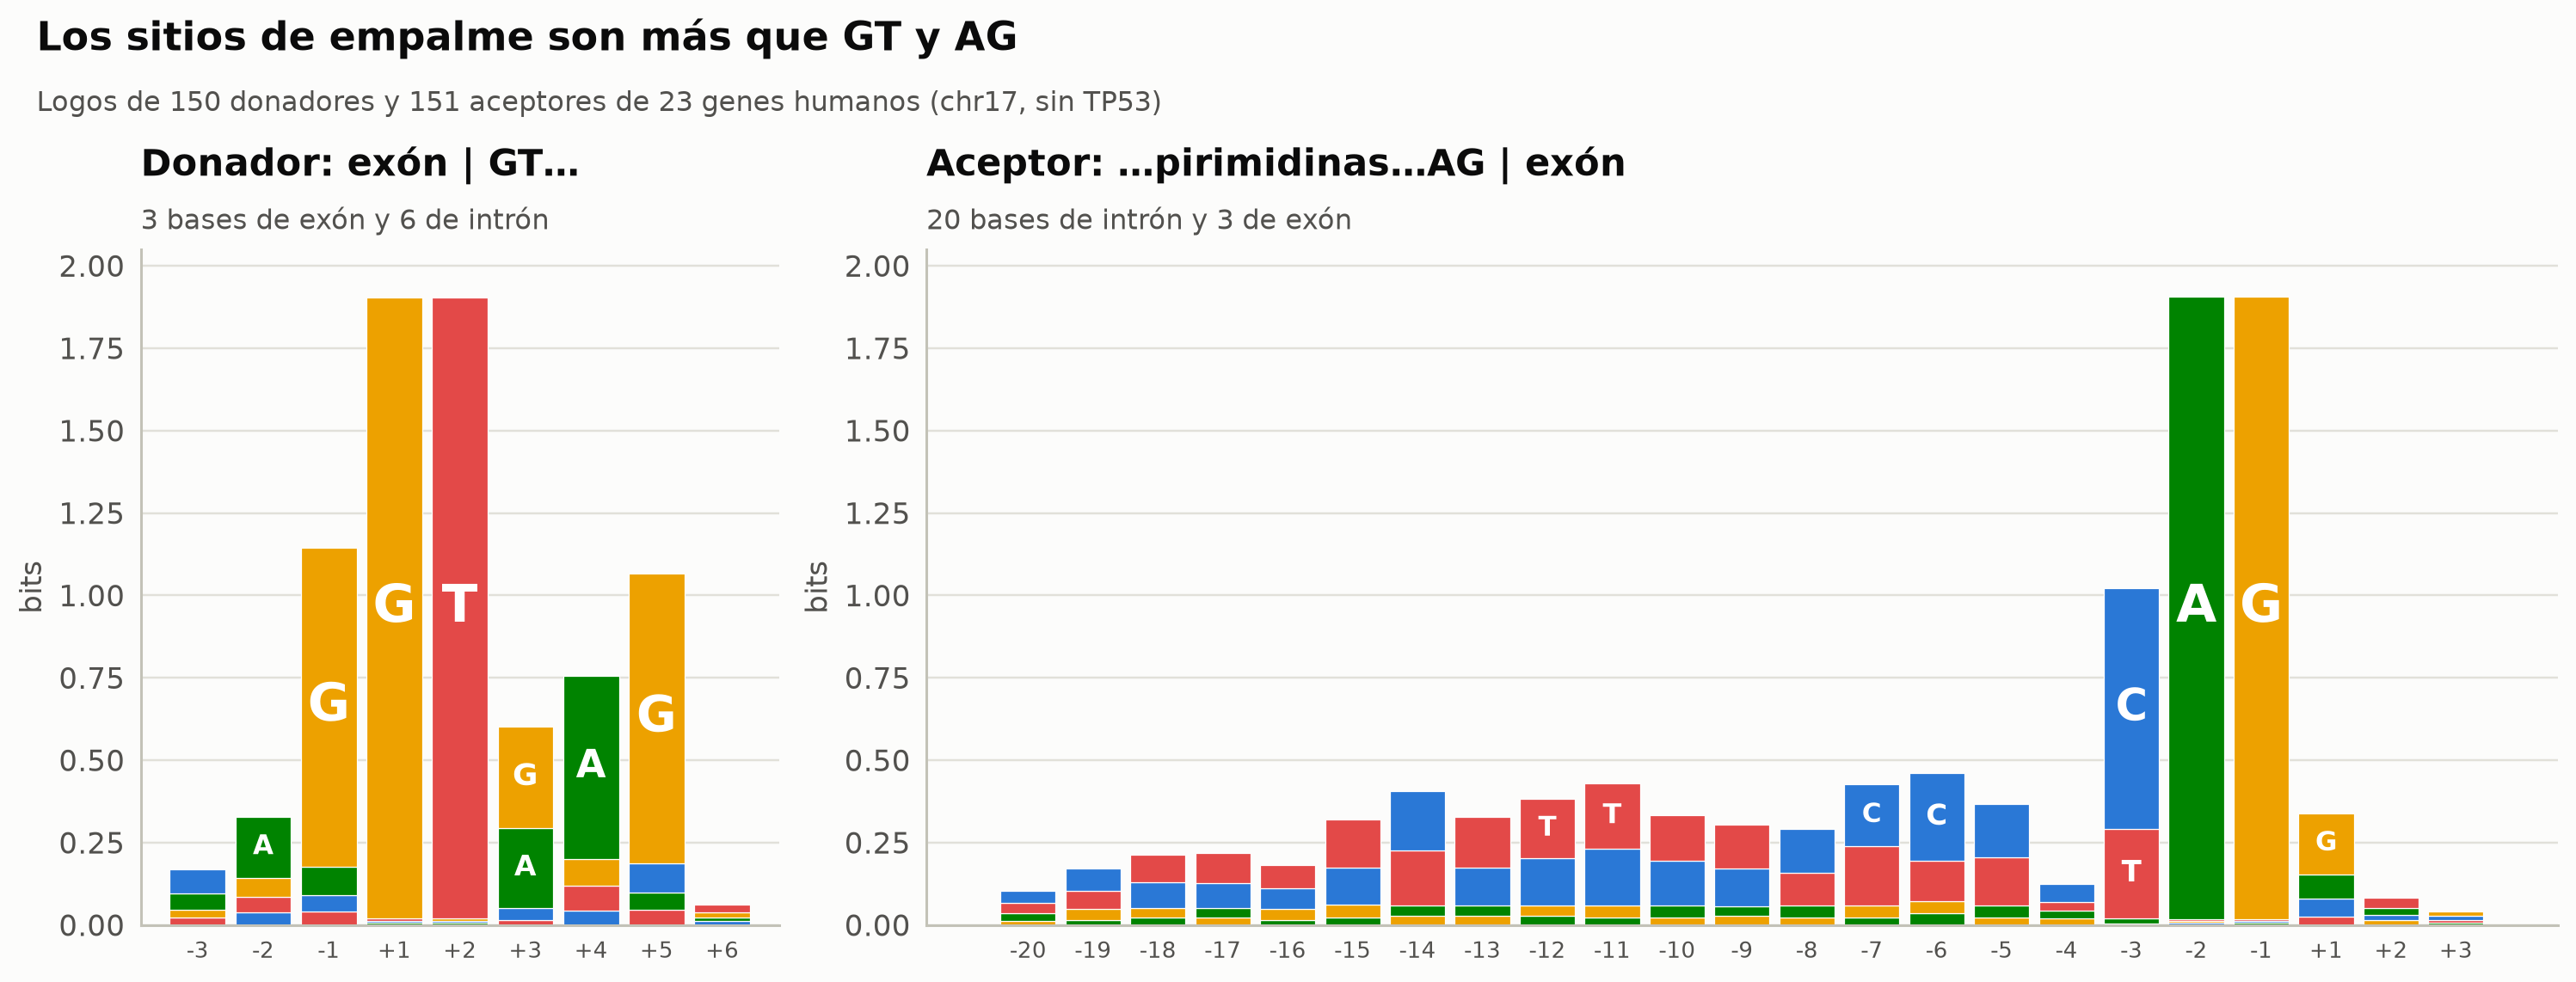

In [31]:
NCBI17 = ("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_000017.11"
          "&rettype=fasta&retmode=text&seq_start=7400001&seq_stop=7700000")
raw17 = course_bytes("NC_000017.11_7400001-7700000.fasta.gz", NCBI17)
try:
    txt17 = gzip.decompress(raw17).decode()
except OSError:
    txt17 = raw17.decode()
chr17 = "".join(l.strip() for l in txt17.splitlines() if not l.startswith(">")).upper()
OFF17 = 7_400_000        # índice Python = coordenada UCSC (0-based) − OFF17
UCSC = ("https://api.genome.ucsc.edu/getData/track?genome=hg38;chrom=chr17;start=7400000;end=7700000;"
        "track=ncbiRefSeqCurated")
tx17 = json.loads(course_bytes("api_cache/ucsc_ncbiRefSeqCurated_hg38_chr17_7400000_7700000.json", UCSC))
tx17 = tx17["ncbiRefSeqCurated"]
longest = {}
for g in tx17:
    if g["cdsEnd"] > g["cdsStart"] and g["txStart"] >= OFF17 + 30 and g["txEnd"] <= OFF17 + 300_000 - 30:
        if g["name2"] not in longest or g["cdsEnd"] - g["cdsStart"] > longest[g["name2"]]["cdsEnd"] - longest[g["name2"]]["cdsStart"]:
            longest[g["name2"]] = g

def structure(g):
    es = [int(v) for v in g["exonStarts"].strip(",").split(",")]
    ee = [int(v) for v in g["exonEnds"].strip(",").split(",")]
    coding = [(max(a, g["cdsStart"]), min(b, g["cdsEnd"])) for a, b in zip(es, ee)
              if min(b, g["cdsEnd"]) > max(a, g["cdsStart"])]
    return coding, list(zip(es, ee))

def sub17(a, b):
    return chr17[a - OFF17:b - OFF17]

cds_h, introns_h, donors, acceptors = [], [], [], []
for name, g in longest.items():
    if name == "TP53":
        continue
    coding, exons = structure(g)
    plus = g["strand"] == "+"
    s = "".join(sub17(a, b) for a, b in coding)
    cds_h.append(s if plus else revcomp(s))
    for (a1, b1), (a2, b2) in zip(exons[:-1], exons[1:]):
        if plus:
            introns_h.append(sub17(b1, a2)); donors.append(sub17(b1 - 3, b1 + 6)); acceptors.append(sub17(a2 - 20, a2 + 3))
        else:
            introns_h.append(revcomp(sub17(b1, a2))); donors.append(revcomp(sub17(a2 - 6, a2 + 3)))
            acceptors.append(revcomp(sub17(b1 - 3, b1 + 20)))
canon_d = [d for d in donors if d[3:5] == "GT"]; canon_a = [a for a in acceptors if a[18:20] == "AG"]
print(f"Genes de entrenamiento: {len(cds_h)} · bases codificantes {sum(map(len, cds_h)):,} · "
      f"intrones {len(introns_h)} ({sum(map(len, introns_h)):,} pb)")
print(f"Donadores GT: {len(canon_d)}/{len(donors)} · aceptores AG: {len(canon_a)}/{len(acceptors)} · "
      f"otros donadores: {Counter(d[3:5] for d in donors if d[3:5] != 'GT')}")

def pwm_log2(windows, pseudo=0.5):
    X = np.array([encode(w) for w in windows]); C = np.full((X.shape[1], 4), pseudo)
    for j in range(X.shape[1]):
        C[j] += np.bincount(X[:, j], minlength=4)
    F = C / C.sum(1, keepdims=True)
    return np.log2(F / 0.25), F

DON, F_don = pwm_log2(canon_d); ACC, F_acc = pwm_log2(canon_a)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), gridspec_kw=dict(width_ratios=[9, 23]))
for axx, F, labels, title_, sub in (
        (axes[0], F_don, [f"{i:+d}" for i in range(-3, 0)] + [f"+{i}" for i in range(1, 7)],
         "Donador: exón | GT…", "3 bases de exón y 6 de intrón"),
        (axes[1], F_acc, [f"{i}" for i in range(-20, 0)] + [f"+{i}" for i in range(1, 4)],
         "Aceptor: …pirimidinas…AG | exón", "20 bases de intrón y 3 de exón")):
    ic = 2 + (F * np.log2(F)).sum(1)                          # contenido de información (bits)
    for j in range(len(F)):
        bottom = 0
        for b in np.argsort(F[j]):
            h = F[j, b] * ic[j]
            axx.bar(j, h, bottom=bottom, color=ec.NUC_COLORS["ACGT"[b]], width=0.85, edgecolor="white", lw=0.4)
            if h > 0.18:
                axx.text(j, bottom + h / 2, "ACGT"[b], ha="center", va="center", color="white",
                         fontsize=min(20, 8 + 12 * h), fontweight="bold")
            bottom += h
    axx.set_xticks(range(len(F)), labels, fontsize=8.5); axx.set_ylim(0, 2.05)
    axx.set_ylabel("bits"); ec.title(axx, title_, sub)
ec.fig_title(fig, "Los sitios de empalme son más que GT y AG",
             f"Logos de {len(canon_d)} donadores y {len(canon_a)} aceptores de {len(cds_h)} genes humanos (chr17, sin TP53)")
plt.show()

> 🔎 **Qué observamos.** En el donador, el `GT` es invariable (2 bits cada uno), pero también se prefieren `AG` justo
> antes (en el exón) y `A`/`G` después (`GTRAGT`, complementario del ARN U1 del espliceosoma). En el aceptor, el `AG`
> final va precedido de un tramo rico en **pirimidinas** (C y T): el tracto de polipirimidinas que reconoce U2AF. Estas
> matrices de peso (lección 4.2) serán los "sensores de señal" de nuestro GHMM.

### Un GHMM mínimo para *TP53*

Construimos un modelo de 7 estados en una sola hebra (la de *TP53*, que está en la hebra − del cromosoma, así que
leemos su reverso complementario):

| Estado | Emisión | Entradas permitidas |
|---|---|---|
| N (intergénico) | Márkov homogéneo de orden 2 (entrenado con intrones) | desde N, o desde E3 si el codón recién leído es de parada |
| E1, E2, E3 (posición en el codón) | Márkov de **fase** de orden 2 (entrenado con 23 CDS humanos) | E1←E3 (sin parada en marco), E1←N sólo en `ATG`, E$k$←I$k$ tras `AG` |
| I0, I1, I2 (fase del intrón) | el mismo Márkov que N | I←E sólo en `GT` (I1 desde E1, I2 desde E2, I0 desde E3) |

Las transiciones que dependen de una señal suman, además de $\log a_{ij}$, la puntuación de la matriz de peso del
donador o del aceptor en esa posición: así funcionan los sensores de señal de un GHMM. Probabilidades: iniciar un gen,
$1/5000$ por base; salir de un exón a un intrón, $1/150$; salir de un intrón, $1/1500$ (longitudes medias
aproximadas de exones e intrones humanos). A diferencia del ejemplo de juguete, que usaba $\log_2$ (bits), este modelo
trabaja con logaritmos naturales: sus puntuaciones están en *nats* ($1$ bit $= \ln 2 \approx 0{,}69$ nats).

In [32]:
def train_phase_ln(seqs, m):
    return train_phase_markov(seqs, m) * np.log(2)          # en logaritmo natural
def train_hom_ln(seqs, m):
    C = np.ones((4 ** m, 4))
    for s in seqs:
        if len(s) > m:
            x = encode(s); c = contexts(x, m); np.add.at(C, (c[m:], x[m:]), 1)
    return np.log(C / C.sum(1, keepdims=True))

STATE_NAMES = ["N", "E1", "E2", "E3", "I0", "I1", "I2"]

def gene_viterbi(xs, PE, PI, m, don=None, acc=None, p_gene=1/5000, p_don=1/150, p_acc=1/1500):
    """Viterbi del GHMM mínimo. Devuelve (camino de estados, matriz V)."""
    T = len(xs); x = encode(xs); c = contexts(x, m); NEG = -1e18
    eN = PI[c, x]; eE = np.stack([PE[k][c, x] for k in range(3)])
    atg = np.array([xs[t:t + 3] == "ATG" for t in range(T)])
    gt = np.array([xs[t:t + 2] == "GT" for t in range(T)])
    ag = np.array([t >= 2 and xs[t - 2:t] == "AG" for t in range(T)])
    stop_before = np.array([t >= 3 and xs[t - 3:t] in STOPS for t in range(T)])
    def signal(W, t, left):
        if W is None:
            return 0.0
        a = t - left
        if a < 0 or a + len(W) > T:
            return NEG
        return W[np.arange(len(W)), x[a:a + len(W)]].sum() * np.log(2)
    lg = np.log
    stay_N, stay_I = lg(1 - p_gene), lg(1 - p_acc)
    V = np.full((T, 7), NEG); B = np.zeros((T, 7), int)
    V[0, 0] = eN[0]
    for t in range(1, T):
        p = V[t - 1]
        opts = [[(p[0] + stay_N, 0)] + ([(p[3], 3)] if stop_before[t] else []),
                ([(p[3], 3)] if not stop_before[t] else []) + ([(p[0] + lg(p_gene), 0)] if atg[t] else []),
                [(p[1], 1)], [(p[2], 2)],
                [(p[4] + stay_I, 4)], [(p[5] + stay_I, 5)], [(p[6] + stay_I, 6)]]
        if ag[t]:
            a_sc = lg(p_acc) + signal(acc, t, 20)
            for k in range(3):
                opts[1 + k].append((p[4 + k] + a_sc, 4 + k))
        if gt[t]:
            d_sc = lg(p_don) + signal(don, t, 3)
            for k in range(3):                               # E(k+1) → I((k+1) mod 3)
                opts[4 + (k + 1) % 3].append((p[1 + k] + d_sc, 1 + k))
        for j in range(7):
            if opts[j]:
                v, b = max(opts[j])
                V[t, j] = v + (eN[t] if j in (0, 4, 5, 6) else eE[j - 1, t]); B[t, j] = b
    path = np.zeros(T, int); s = 0
    for t in range(T - 1, -1, -1):
        path[t] = s; s = B[t, s]
    return path, V

tp53 = longest["TP53"]
coding_tp53, _ = structure(tp53)
A0, B0 = coding_tp53[0][0] - 1000, coding_tp53[-1][1] + 1000
x_tp53 = revcomp(sub17(A0, B0)); T53 = len(x_tp53)
truth53 = np.zeros(T53, int)
for a, b in coding_tp53:
    truth53[B0 - b:B0 - a] = 1          # coordenadas en la hebra de TP53

def segments(v):
    d = np.diff(np.r_[0, v, 0]); return list(zip(np.flatnonzero(d == 1), np.flatnonzero(d == -1)))

def score_pred(path):
    pr = ((path >= 1) & (path <= 3)).astype(int)
    tp = (pr & truth53).sum()
    te, pe = set(segments(truth53)), set(segments(pr))
    return pr, {"Sn (bases)": round(float(tp / truth53.sum()), 3), "Sp (bases)": round(float(tp / max(pr.sum(), 1)), 3),
                "exones exactos": f"{len(te & pe)}/{len(te)}", "exones predichos": len(pe)}

t0 = time.time()
PE2, PI2 = train_phase_ln(cds_h, 2), train_hom_ln(introns_h, 2)
path53, V53 = gene_viterbi(x_tp53, PE2, PI2, 2, DON, ACC)
pred53, res_full = score_pred(path53)
print(f"TP53 (NM_000546): {T53:,} pb analizados · {len(coding_tp53)} exones codificantes · "
      f"{truth53.sum()} pb de CDS · Viterbi en {time.time() - t0:.1f} s")
print("Verdad   :", [(int(a), int(b)) for a, b in segments(truth53)])
print("Predicción:", [(int(a), int(b)) for a, b in segments(pred53)])
res_full

TP53 (NM_000546): 8,986 pb analizados · 10 exones codificantes · 1182 pb de CDS · Viterbi en 0.0 s
Verdad   : [(1000, 1074), (1191, 1213), (1322, 1601), (2358, 2542), (2623, 2736), (3304, 3414), (3757, 3894), (3986, 4060), (6879, 6986), (7904, 7986)]
Predicción: [(762, 769), (854, 1074), (1191, 1213), (1322, 1601), (2358, 2542), (2623, 2736), (3304, 3414), (3757, 3894), (3986, 4060), (6879, 6986), (7904, 7986)]


{'Sn (bases)': 1.0,
 'Sp (bases)': 0.885,
 'exones exactos': '9/10',
 'exones predichos': 11}

> 🔎 **Qué observamos.** El modelo cubre el 100 % de las bases codificantes de *TP53* y recupera nueve de los diez
> exones con sus límites **exactos**, incluido el exón de **22 pb**, que ningún modelo de contenido podría ver por sí
> solo: lo encuentran los sensores de señal y la obligación de mantener el marco. El error está en el **inicio**: el
> modelo prefiere un `ATG` aguas arriba, alarga el primer exón codificante y añade un pequeño exón extra en la región
> 5' no traducida (por eso la especificidad por bases es 88,5 %). Es el mismo problema que vimos en bacterias, y el motivo
> por el que AUGUSTUS modela explícitamente el contexto del codón de inicio.

> ⚠️ **Honestidad ante todo.** Un solo gen compacto, con sitios canónicos, entrenado con genes de la misma región no
> es una evaluación seria. En secuencias largas con muchos genes, los predictores de los años noventa **inventaban
> exones** en intrones e intergénicos; ese diagnóstico motivó el diseño de AUGUSTUS (Stanke y Waack, 2003). Veamos
> qué pasa si quitamos piezas al modelo.

In [33]:
t0 = time.time()
variants = {"modelo completo (orden 2 + matrices de empalme)": res_full}
p_nopwm, _ = gene_viterbi(x_tp53, PE2, PI2, 2, None, None)
variants["sin matrices de empalme (sólo GT/AG)"] = score_pred(p_nopwm)[1]
p_o0, _ = gene_viterbi(x_tp53, train_phase_ln(cds_h, 0), train_hom_ln(introns_h, 0), 0, DON, ACC)
variants["orden 0 (sólo composición por fase)"] = score_pred(p_o0)[1]
print(f"(tres decodificaciones más en {time.time() - t0:.1f} s)")
ablation = pd.DataFrame(variants).T
ablation["Sn (bases)"] = ablation["Sn (bases)"].map(lambda v: f"{v:.1%}")
ablation["Sp (bases)"] = ablation["Sp (bases)"].map(lambda v: f"{v:.1%}")
ablation

(tres decodificaciones más en 0.1 s)


,Sn (bases),Sp (bases),exones exactos,exones predichos
modelo completo (orden 2 + matrices de empalme),100.0%,88.5%,9/10,11
sin matrices de empalme (sólo GT/AG),36.4%,66.1%,0/10,2
orden 0 (sólo composición por fase),69.5%,84.3%,6/10,8


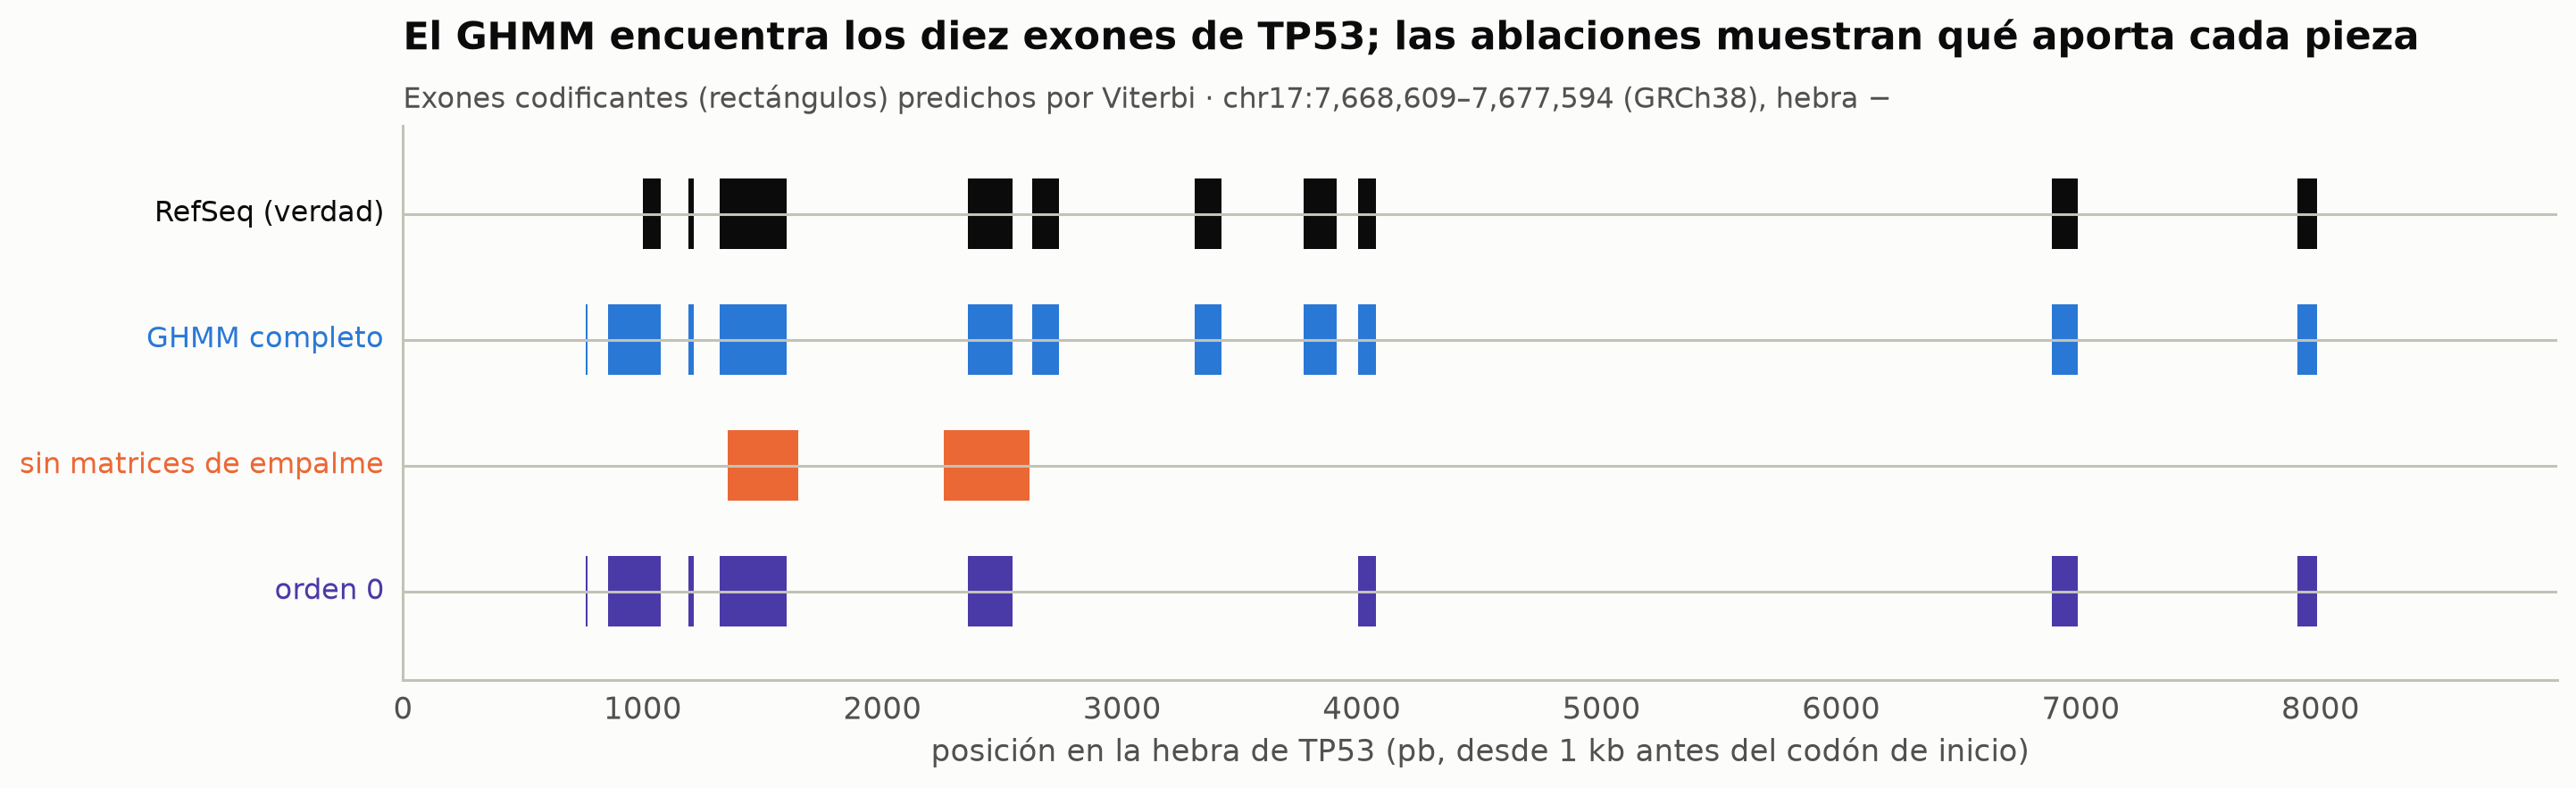

In [34]:
fig, ax = plt.subplots(figsize=(13, 3.9))
tracks53 = [("RefSeq (verdad)", truth53, ec.INK),
            ("GHMM completo", pred53, ec.BLUE),
            ("sin matrices de empalme", score_pred(p_nopwm)[0], ec.ORANGE),
            ("orden 0", score_pred(p_o0)[0], ec.VIOLET)]
for k, (lab_, v, colr) in enumerate(tracks53):
    y = len(tracks53) - 1 - k
    ax.plot([0, T53], [y, y], color=ec.BASELINE, lw=1)
    for a, b in segments(v):
        ax.add_patch(Rectangle((a, y - 0.28), b - a, 0.56, fc=colr, lw=0))
    ax.text(-80, y, lab_, ha="right", va="center", fontsize=10.5, color=colr)
ax.set_xlim(0, T53); ax.set_ylim(-0.7, len(tracks53) - 0.3); ax.set_yticks([])
ax.set_xlabel("posición en la hebra de TP53 (pb, desde 1 kb antes del codón de inicio)")
ec.title(ax, "El GHMM encuentra los diez exones de TP53; las ablaciones muestran qué aporta cada pieza",
         f"Exones codificantes (rectángulos) predichos por Viterbi · chr17:{A0 + 1:,}–{B0:,} (GRCh38), hebra −")
plt.show()

> 🔎 **Qué observamos.** Compare las pistas con la tabla anterior. Sin las matrices de empalme, el modelo sólo exige
> `GT`/`AG`; cualquier `GT` o `AG` es un límite candidato igual de bueno, y el gen se desintegra: dos "exones"
> desplazados, ningún límite exacto, un tercio de las bases codificantes. Con orden 0, el modelo de contenido
> distingue peor exón de intrón y se pierden cuatro exones del centro del gen. Las señales y el contexto se
> necesitan mutuamente. Cada pieza del modelo cuenta; en los predictores reales hay además modelos de longitud,
> de contexto del inicio, de regiones no traducidas y de ambas hebras.

### 🎬 Viterbi recorre *TP53*

La animación muestra cómo avanza Viterbi a lo largo de la secuencia. La curva es la **ventaja del mejor estado de
exón** sobre el mejor estado no codificante, $\max_{j\in E} V_j(t) - \max_{j\notin E} V_j(t)$: sube dentro de los exones
y baja en los intrones. La pista "decisión provisional" colorea cada base según el mejor estado **en ese momento**.
Sólo al llegar al final se hace el *traceback*, y el camino definitivo $\pi^\ast$ puede corregir decisiones provisionales.

> 🤔 **Antes de ejecutar, prediga:** ¿coincidirá la "decisión provisional" con el camino final en los bordes de los
> exones, o habrá diferencias?

![Viterbi a lo largo de TP53: la ventaja del estado de exón sube en cada exón; al final, el traceback fija el camino óptimo, que coincide con los exones de RefSeq](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-08-ensamblaje/8.4_viterbi_tp53.gif)

*Viterbi a lo largo de TP53: la ventaja del estado de exón sube en cada exón; al final, el traceback fija el camino óptimo, que coincide con los exones de RefSeq*

In [35]:
exon_best = V53[:, 1:4].max(1); other_best = V53[:, [0, 4, 5, 6]].max(1)
adv = np.clip(exon_best - other_best, -40, 40)
provisional = (V53.argmax(1) >= 1) & (V53.argmax(1) <= 3)

fig = plt.figure(figsize=(12, 5.6))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.88))
gs = fig.add_gridspec(2, 1, height_ratios=[2.2, 1.4], hspace=0.08)
axc, axt = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
axc.set_xlim(0, T53); axc.set_ylim(-42, 42); axc.axhline(0, color=ec.BASELINE, lw=0.8)
axc.set_ylabel("ventaja exón (nats)"); axc.set_xticks([])
axt.set_xlim(0, T53); axt.set_ylim(-0.6, 2.6); axt.set_yticks([0, 1, 2], ["camino final π*", "provisional", "RefSeq"])
axt.set_xlabel("posición en la hebra de TP53 (pb)")
for a, b in segments(truth53):
    axt.add_patch(Rectangle((a, 1.72), b - a, 0.56, fc=ec.INK, lw=0))
    axc.axvspan(a, b, color=ec.BLUE, alpha=0.07, lw=0)
fig.text(0.01, 0.985, "Viterbi decide base a base, pero sólo el traceback fija la anotación", fontsize=15,
         fontweight="bold", va="top")
fig.text(0.01, 0.94, "Curva: max V(exón) − max V(no exón) · sombreado y barras negras: exones codificantes de RefSeq",
         fontsize=10.5, color=ec.INK_2, va="top")
dyn = []
NF = 50
def update(f):
    global dyn
    for a in dyn:
        a.remove()
    dyn = []
    t = min(T53, int(T53 * (f + 1) / (NF - 6))) if f < NF - 6 else T53
    xs_ = np.arange(t)
    dyn.append(axc.fill_between(xs_, 0, adv[:t], where=adv[:t] > 0, color=ec.BLUE, lw=0, interpolate=True))
    dyn.append(axc.fill_between(xs_, 0, adv[:t], where=adv[:t] <= 0, color=ec.MUTED, alpha=0.5, lw=0, interpolate=True))
    for a, b in segments(provisional[:t].astype(int)):
        dyn.append(axt.add_patch(Rectangle((a, 0.72), b - a, 0.56, fc=ec.ORANGE, lw=0)))
    dyn.append(axc.axvline(t, color=ec.INK, lw=1, ls=":"))
    if f >= NF - 6:
        for a, b in segments(pred53):
            dyn.append(axt.add_patch(Rectangle((a, -0.28), b - a, 0.56, fc=ec.GREEN, lw=0)))
        dyn.append(axc.text(T53 * 0.5, 36, "traceback completado", ha="center", fontsize=11, color=ec.GREEN,
                            fontweight="bold"))
    else:
        dyn.append(axc.text(T53 * 0.5, 36, f"t = {t:,} pb", ha="center", fontsize=11, color=ec.INK))
    return []
fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=NF, interval=180, name="8.4_viterbi_tp53")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En los exones largos la ventaja sube de forma sostenida (cada base "suena" a codificante en
> su fase) y en los intrones cae. La decisión provisional se equivoca en los dos sentidos: marca como exón tramos de
> intrón que por azar "suenan" codificantes (aunque ningún camino completo que respete la gramática pueda pasar por
> ahí) y **pierde exones enteros**, como los que empiezan hacia las posiciones 2 620 y 3 300, que el camino final sí
> incluye porque los necesita para llegar en fase al exón siguiente. El *traceback* (verde) resuelve esas dudas mirando la
> secuencia **entera**: es la diferencia entre decidir por la puntuación local y decidir por el mejor camino global.

> ✅ **Compruebe su comprensión.** ¿Por qué el exón de 22 pb no se ve como un pico en la curva y, sin embargo, aparece
> en el camino final? *(Pista: 22 bases aportan poca evidencia de contenido, pero sin ese exón el marco de lectura
> quedaría desfasado en 22 bases (22 mod 3 = 1) y el resto del gen chocaría con codones de parada o sitios de empalme
> incompatibles con la fase.)*

---

## 8. Enmascarar repeticiones

### Por qué

Casi la mitad del genoma humano (y porcentajes aún mayores en muchas plantas) son **elementos transponibles** y sus
restos. Muchos contienen ORFs genuinos (transposasas, transcriptasas inversas) que un predictor *ab initio* anotaría
como genes del huésped, inflando la anotación con miles de falsos positivos. Ya vimos la versión bacteriana del
problema: las secuencias IS del clon del LTEE aparecen como contigs cortos de cobertura altísima, y sus transposasas
son "genes" que no dicen nada de la biología de la cepa.

Hay dos grandes clases de repeticiones:

* **Dispersas** (Alu, LINE-1, transposones de ADN, IS bacterianas): copias de una misma familia repartidas por el
  genoma. Se detectan por **homología** con una biblioteca (Dfam, Repbase) o con una biblioteca construida *de novo*
  para la especie (RepeatModeler), y se enmascaran con **RepeatMasker**.
* **De baja complejidad** (`CACACACA…`, `AAAAAAA…`, `CAGCAGCAG…`): se detectan por su **composición**, sin biblioteca.
  Es lo que hace el algoritmo **DUST** (usado por BLAST y minimap2).

El marcado puede ser **duro** (sustituir por `N`) o **blando** (*soft-masking*: pasar a minúsculas). El blando es
preferible: el predictor evita **iniciar** genes allí, pero un exón verdadero puede extenderse sobre un fragmento
repetitivo.

### DUST, versión mínima

Piense en un teclado con una tecla atascada: el texto resultante tiene muy pocas "palabras" distintas que se repiten
muchas veces. DUST cuenta los **trinucleótidos** de una ventana de 64 pb (62 trinucleótidos solapados) y mide cuán
concentrados están:

$$
s(w) = \frac{1}{l-1}\sum_{t} \frac{c_t\,(c_t - 1)}{2},
$$

| Símbolo | Significado |
|---|---|
| $w$ | ventana de 64 pb |
| $l = 62$ | número de trinucleótidos de la ventana |
| $c_t$ | cuántas veces aparece el trinucleótido $t$ en la ventana |
| $c_t(c_t-1)/2$ | número de **pares** de apariciones repetidas de $t$ |

**A mano.** Ventana `AAAA…A` (64 A): un solo trinucleótido con $c=62$: $s = \frac{62\cdot61/2}{61} = 31$.
Ventana `CACA…`: `CAC` y `ACA`, 31 veces cada uno: $s = \frac{2\cdot 31\cdot30/2}{61} = 15{,}2$. Ventana al azar: 62
trinucleótidos repartidos en 64 tipos, casi todos con $c\le1$: $s\approx0{,}5$. Enmascaramos las ventanas con $s>2$.
Esta es una versión simplificada del DUST simétrico de Morgulis et al. (2006), que enmascara intervalos "perfectos" en
lugar de ventanas completas.

In [36]:
def dust_scores(seq, W=64):
    """s(w) de cada ventana de W pb que empieza en cada posición (actualización incremental de conteos)."""
    x = encode(seq)
    tri = x[:-2] * 16 + x[1:-1] * 4 + x[2:]
    l = W - 2
    cnt = np.bincount(tri[:l], minlength=64).astype(np.int64)
    S = int((cnt * (cnt - 1) // 2).sum())
    out = np.empty(len(tri) - l + 1)
    out[0] = S
    for i in range(1, len(out)):
        o, a = tri[i - 1], tri[i + l - 1]
        cnt[o] -= 1; S -= cnt[o]           # sale un trinucleótido: se pierden c−1 pares
        S += cnt[a]; cnt[a] += 1           # entra uno: se ganan c pares
        out[i] = S
    return out / (l - 1)

for name, w in [("A×64", "A" * 64), ("CA×32", "CA" * 32), ("al azar", "".join(np.random.default_rng(1).choice(list("ACGT"), 64)))]:
    print(f"{name:8s} s = {dust_scores(w)[0]:.2f}")

t0 = time.time()
ds = dust_scores(chr17)
masked = np.zeros(len(chr17), bool)
starts = np.flatnonzero(ds > 2)
d = np.zeros(len(chr17) + 1, int)
np.add.at(d, starts, 1); np.add.at(d, np.minimum(starts + 64, len(chr17)), -1)
masked = np.cumsum(d[:-1]) > 0
print(f"chr17 7,40–7,70 Mb: {masked.mean():.2%} enmascarado por baja complejidad ({masked.sum():,} pb) "
      f"en {time.time() - t0:.1f} s")
i = int(np.argmax(ds))
a, b = max(0, i - 40), i + 104
print("Ejemplo con enmascarado blando:\n", "".join(c.lower() if m else c for c, m in zip(chr17[a:b], masked[a:b])))

if shutil.which("sdust"):                  # comprobación con la implementación de referencia, si está instalada
    tmp = tempfile.mkdtemp(); open(f"{tmp}/c.fa", "w").write(">c\n" + chr17 + "\n")
    out = subprocess.run(["sdust", f"{tmp}/c.fa"], capture_output=True, text=True).stdout
    ref_mask = np.zeros(len(chr17), bool)
    for line in out.splitlines():
        _, s0, e0 = line.split(); ref_mask[int(s0):int(e0)] = True
    print(f"sdust enmascara {ref_mask.sum():,} pb; nuestra versión cubre el {(masked & ref_mask).sum() / ref_mask.sum():.0%} "
          f"de ellos (y marca más bases porque enmascara ventanas completas)")

A×64     s = 31.00
CA×32    s = 15.25
al azar  s = 0.54
chr17 7,40–7,70 Mb: 10.71% enmascarado por baja complejidad (32,135 pb) en 0.2 s
Ejemplo con enmascarado blando:
 gcggacaataggatcactgcctgccagatcttcaaacttttatatatatatatatatatatatatatatatatatatatatatatatatatatatatatatatatatatataaaaatatataaatgccacggtcctgctctggt
sdust enmascara 17,366 pb; nuestra versión cubre el 77% de ellos (y marca más bases porque enmascara ventanas completas)


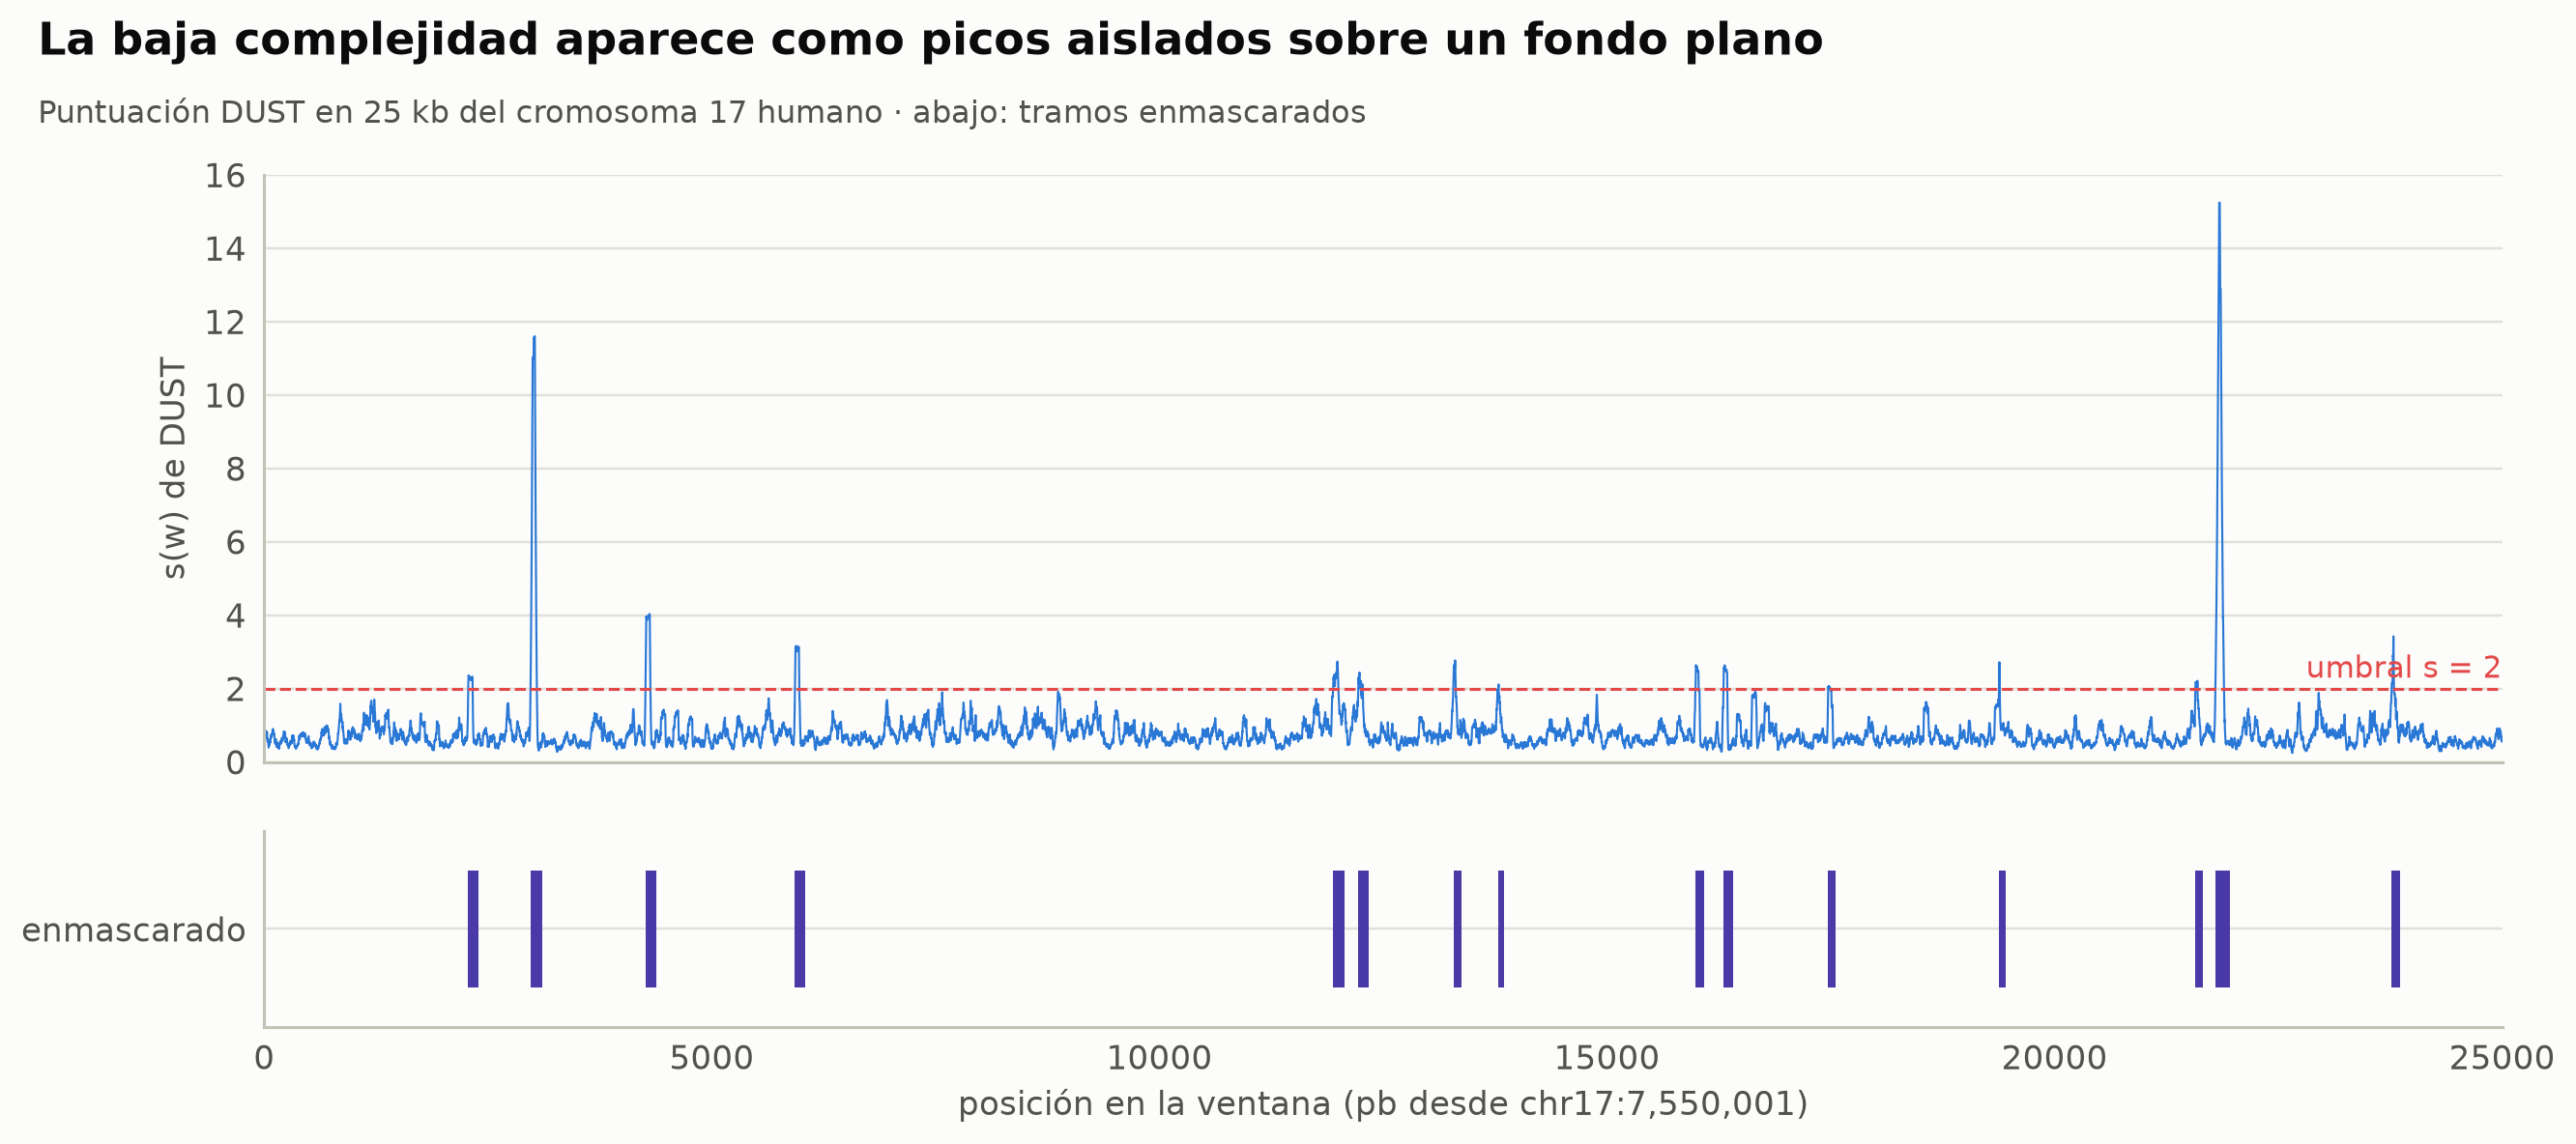

In [37]:
lo_, hi_ = 150_000, 175_000
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 4.6), sharex=True, gridspec_kw=dict(height_ratios=[3, 1], hspace=0.1))
xx = np.arange(lo_, hi_)
a1.plot(xx - lo_, ds[lo_:hi_], color=ec.SEQ_BLUE[7], lw=0.7)
a1.axhline(2, color=ec.RED, ls="--", lw=1); a1.text(hi_ - lo_, 2.3, "umbral s = 2", color=ec.RED, ha="right", fontsize=10)
a1.set_ylabel("s(w) de DUST"); a1.set_ylim(0, max(6, ds[lo_:hi_].max() * 1.05))
for a, b in segments(masked[lo_:hi_].astype(int)):
    a2.add_patch(Rectangle((a, 0.2), max(b - a, 30), 0.6, fc=ec.VIOLET, lw=0))
a2.set_yticks([0.5], ["enmascarado"]); a2.set_ylim(0, 1); a2.set_xlim(0, hi_ - lo_)
a2.set_xlabel(f"posición en la ventana (pb desde chr17:{OFF17 + lo_ + 1:,})")
ec.fig_title(fig, "La baja complejidad aparece como picos aislados sobre un fondo plano",
             "Puntuación DUST en 25 kb del cromosoma 17 humano · abajo: tramos enmascarados")
plt.show()

> 🔎 **Qué observamos.** En el ADN "normal" la puntuación DUST se queda por debajo de 1; los tramos de baja complejidad
> (microsatélites como el `(TA)n` del ejemplo, colas poli-A de retrotransposones) forman picos aislados que superan el
> umbral. Nuestra versión marca alrededor del 11 % de la región, pero lo hace por ventanas completas de 64 pb; sdust,
> que recorta los intervalos exactos, marca menos (unos 17 000 pb, el 6 %). El grueso de las repeticiones humanas, sin embargo, son copias de **Alu** y
> **LINE-1** con composición normal: DUST no las ve, y hace falta la búsqueda por homología de RepeatMasker con una
> biblioteca de familias.

---

## 9. Evidencia externa: RNA-seq, proteínas, AUGUSTUS y BRAKER

Los predictores *ab initio* aciertan la estructura de los genes típicos, pero fallan en los extremos (exones
terminales, regiones no traducidas), en los genes atípicos y en el **empalme alternativo**. La evidencia experimental
corrige esas debilidades:

* **RNA-seq.** Las lecturas alineadas con un mapeador que admite empalmes (HISAT2, STAR) indican directamente dónde
  están los intrones: cada lectura **dividida** entre dos exones es una "pista" de intrón con coordenadas exactas.
* **Proteínas** de especies emparentadas, alineadas contra el genoma con alineadores que toleran intrones, marcan
  exones codificantes conservados.

En un GHMM, las pistas entran como una **bonificación** en la puntuación de los caminos que las respetan (y una
penalización para los que las contradicen): Viterbi sigue siendo el mismo algoritmo, sólo cambian las puntuaciones.
Así lo hace **AUGUSTUS** (Stanke y Waack, 2003), que además introdujo un modelo de longitud de intrones explícito para
los cortos con cola geométrica para los largos, un nuevo modelo del sitio donador y parámetros dependientes del
contenido de GC.

**BRAKER** automatiza el proceso completo: usa la evidencia para entrenar GeneMark sin supervisión, genera con él un
conjunto de genes de entrenamiento para AUGUSTUS y predice los genes finales con AUGUSTUS respetando las pistas.
**BRAKER2** (Brůna et al., 2021) lo consigue sólo con una base de datos de proteínas de cualquier distancia evolutiva
(p. ej., OrthoDB), incluso sin RNA-seq, mediante GeneMark-EP+.

```bash
# 1) biblioteca de repeticiones de la especie y enmascarado blando
BuildDatabase -name especie genoma.fasta
RepeatModeler -database especie -threads 16
RepeatMasker -lib especie-families.fa -xsmall -pa 16 genoma.fasta

# 2) predicción con evidencia de proteínas y RNA-seq alineado
braker.pl --genome=genoma.fasta.masked --softmasking \
    --prot_seq=orthodb_proteinas.fa --bam=rnaseq.bam \
    --threads 16 --workingdir=braker_out

# 3) completitud del conjunto de proteínas predicho
busco -i braker_out/braker.aa -m proteins -l eukaryota_odb10 -o busco_prot
```

Estas herramientas necesitan horas de cómputo y bases de datos de decenas de GB: no son para Colab, sino para un
servidor. Lo importante es entender qué hace cada paso, y eso ya lo construimos en miniatura.

---

## 10. Anotación procariota automatizada: Prokka y Bakta

En bacterias y arqueas el flujo completo se automatiza con una sola orden.

**Prokka** (Seemann, 2014) encadena herramientas especializadas: Prodigal para las regiones codificantes, barrnap para
los ARNr, Aragorn para los ARNt, Infernal para otros ARN no codificantes y SignalP para péptidos señal. Asigna
funciones buscando las proteínas predichas en bases de datos jerárquicas, de las más fiables (proteínas curadas) a
las más generales (familias de dominios). Anota un genoma bacteriano en borrador en unos diez minutos en un ordenador
de escritorio y produce archivos listos para depositar en los repositorios públicos: `.gff`, `.gbk`, `.faa`
(proteínas), `.ffn` (genes), `.tbl`, `.sqn`, `.tsv` y un resumen `.txt`.

**Bakta** (Schwengers et al., 2021) persigue los mismos objetivos con otras prioridades: ser independiente del taxón,
detectar **proteínas pequeñas** que los predictores suelen pasar por alto (justo el grupo que más perdió Prodigal en
nuestra evaluación) y asignar referencias cruzadas precisas a bases de datos públicas. Identifica muchas proteínas
**sin alineamiento**, reconociendo secuencias idénticas a las ya catalogadas en UniProt, lo que acelera el proceso.
Exporta GFF3, GenBank/EMBL, JSON y tablas `.tsv`, y separa las proteínas hipotéticas en archivos propios.

```bash
prokka --outdir prokka_cepa --prefix cepa --kingdom Bacteria --cpus 8 contigs_500.fasta
bakta --db bakta_db/ --output bakta_cepa --prefix cepa --threads 8 contigs_500.fasta
awk '$3 == "CDS"' bakta_cepa/cepa.gff3 | wc -l      # nº de CDS
```

Nuestro propio "mini-Prokka" ya tiene casi todas las piezas estructurales: CDS con Prodigal y pistas de ARNr por
$k$-mers. Escribamos su resumen como lo haría Prokka y un GFF3 completo del ensamblaje.

In [38]:
gff_path = os.path.join(tempfile.mkdtemp(), "ltee_clon.gff3")
with open(gff_path, "w") as fh:
    fh.write("##gff-version 3\n")
    for name, genes in genes_by_ctg.items():
        fh.write(f"##sequence-region {name} 1 {len(contigs[name])}\n")
        buf = io.StringIO()
        genes.write_gff(buf, sequence_id=name, header=False)
        fh.write("".join(l + "\n" for l in buf.getvalue().splitlines() if l and not l.startswith("#")))
gff = pd.read_csv(gff_path, sep="\t", comment="#", header=None,
                  names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])
summary_txt = {
    "organismo": "Escherichia coli B, clon del LTEE (SRR2584863)",
    "contigs": len(contigs), "bases": int(ctg_len.sum()),
    "CDS": int((gff.type == "CDS").sum()),
    "CDS parciales (borde de contig)": int(gff.attributes.str.contains("partial=(?:10|01|11)").sum()),
    "ARNr (pistas por k-mers)": ", ".join(f"{r.ARNr} en {r.contig}" for r in hits_rrna.itertuples()),
    "ARNt": "no buscados (Prokka usaría Aragorn)",
    "densidad codificante": f"{(gff.end - gff.start + 1).sum() / ctg_len.sum():.1%}",
}
for k, v in summary_txt.items():
    print(f"{k}: {v}")
print(f"\nGFF3 escrito en {gff_path} ({len(gff):,} líneas de CDS)")

organismo: Escherichia coli B, clon del LTEE (SRR2584863)
contigs: 93
bases: 4554639
CDS: 4280
CDS parciales (borde de contig): 63
ARNr (pistas por k-mers): 16S en NODE_4, 5S en NODE_6, 5S en NODE_16, 5S en NODE_18, 5S en NODE_20, 5S en NODE_42, 23S en NODE_80, 23S en NODE_88
ARNt: no buscados (Prokka usaría Aragorn)
densidad codificante: 88.4%

GFF3 escrito en ltee_clon.gff3 (4,280 líneas de CDS)


> 🔎 **Qué observamos.** Unos 4 280 CDS en 4,55 Mb, con una densidad codificante de alrededor del **88 %**, la cifra
> típica de *E. coli* que anunciamos al principio. Lo que nos falta para igualar a Prokka o Bakta es sobre todo la
> **anotación funcional**: buscar cada proteína en bases de datos curadas y asignarle nombre, número EC y términos GO.

> ⚠️ **Anotaciones que se copian a sí mismas.** La anotación funcional por homología es transitiva: si una proteína
> se anotó mal en una base de datos, todas las que se anoten por parecido con ella heredarán el error. Desconfíe de
> funciones muy específicas asignadas con identidades bajas, prefiera bases de datos curadas y recuerde que "proteína
> hipotética" es una respuesta honesta. Tampoco compare el número de genes entre genomas anotados con flujos
> distintos: parte de la diferencia será metodológica, no biológica.

### El mapa del genoma anotado

Terminamos con la figura que acompaña a casi todo artículo de un genoma bacteriano: un **mapa circular**. Colocamos
cada gen predicho en su posición de REL606 (con el bloque de anclas que lo contiene), coloreado según la evaluación, y
añadimos los contigs, los genes que se perdieron, los operones de ARNr y el **sesgo GC** acumulado, que marca el
origen y el término de replicación (lección 1.3).

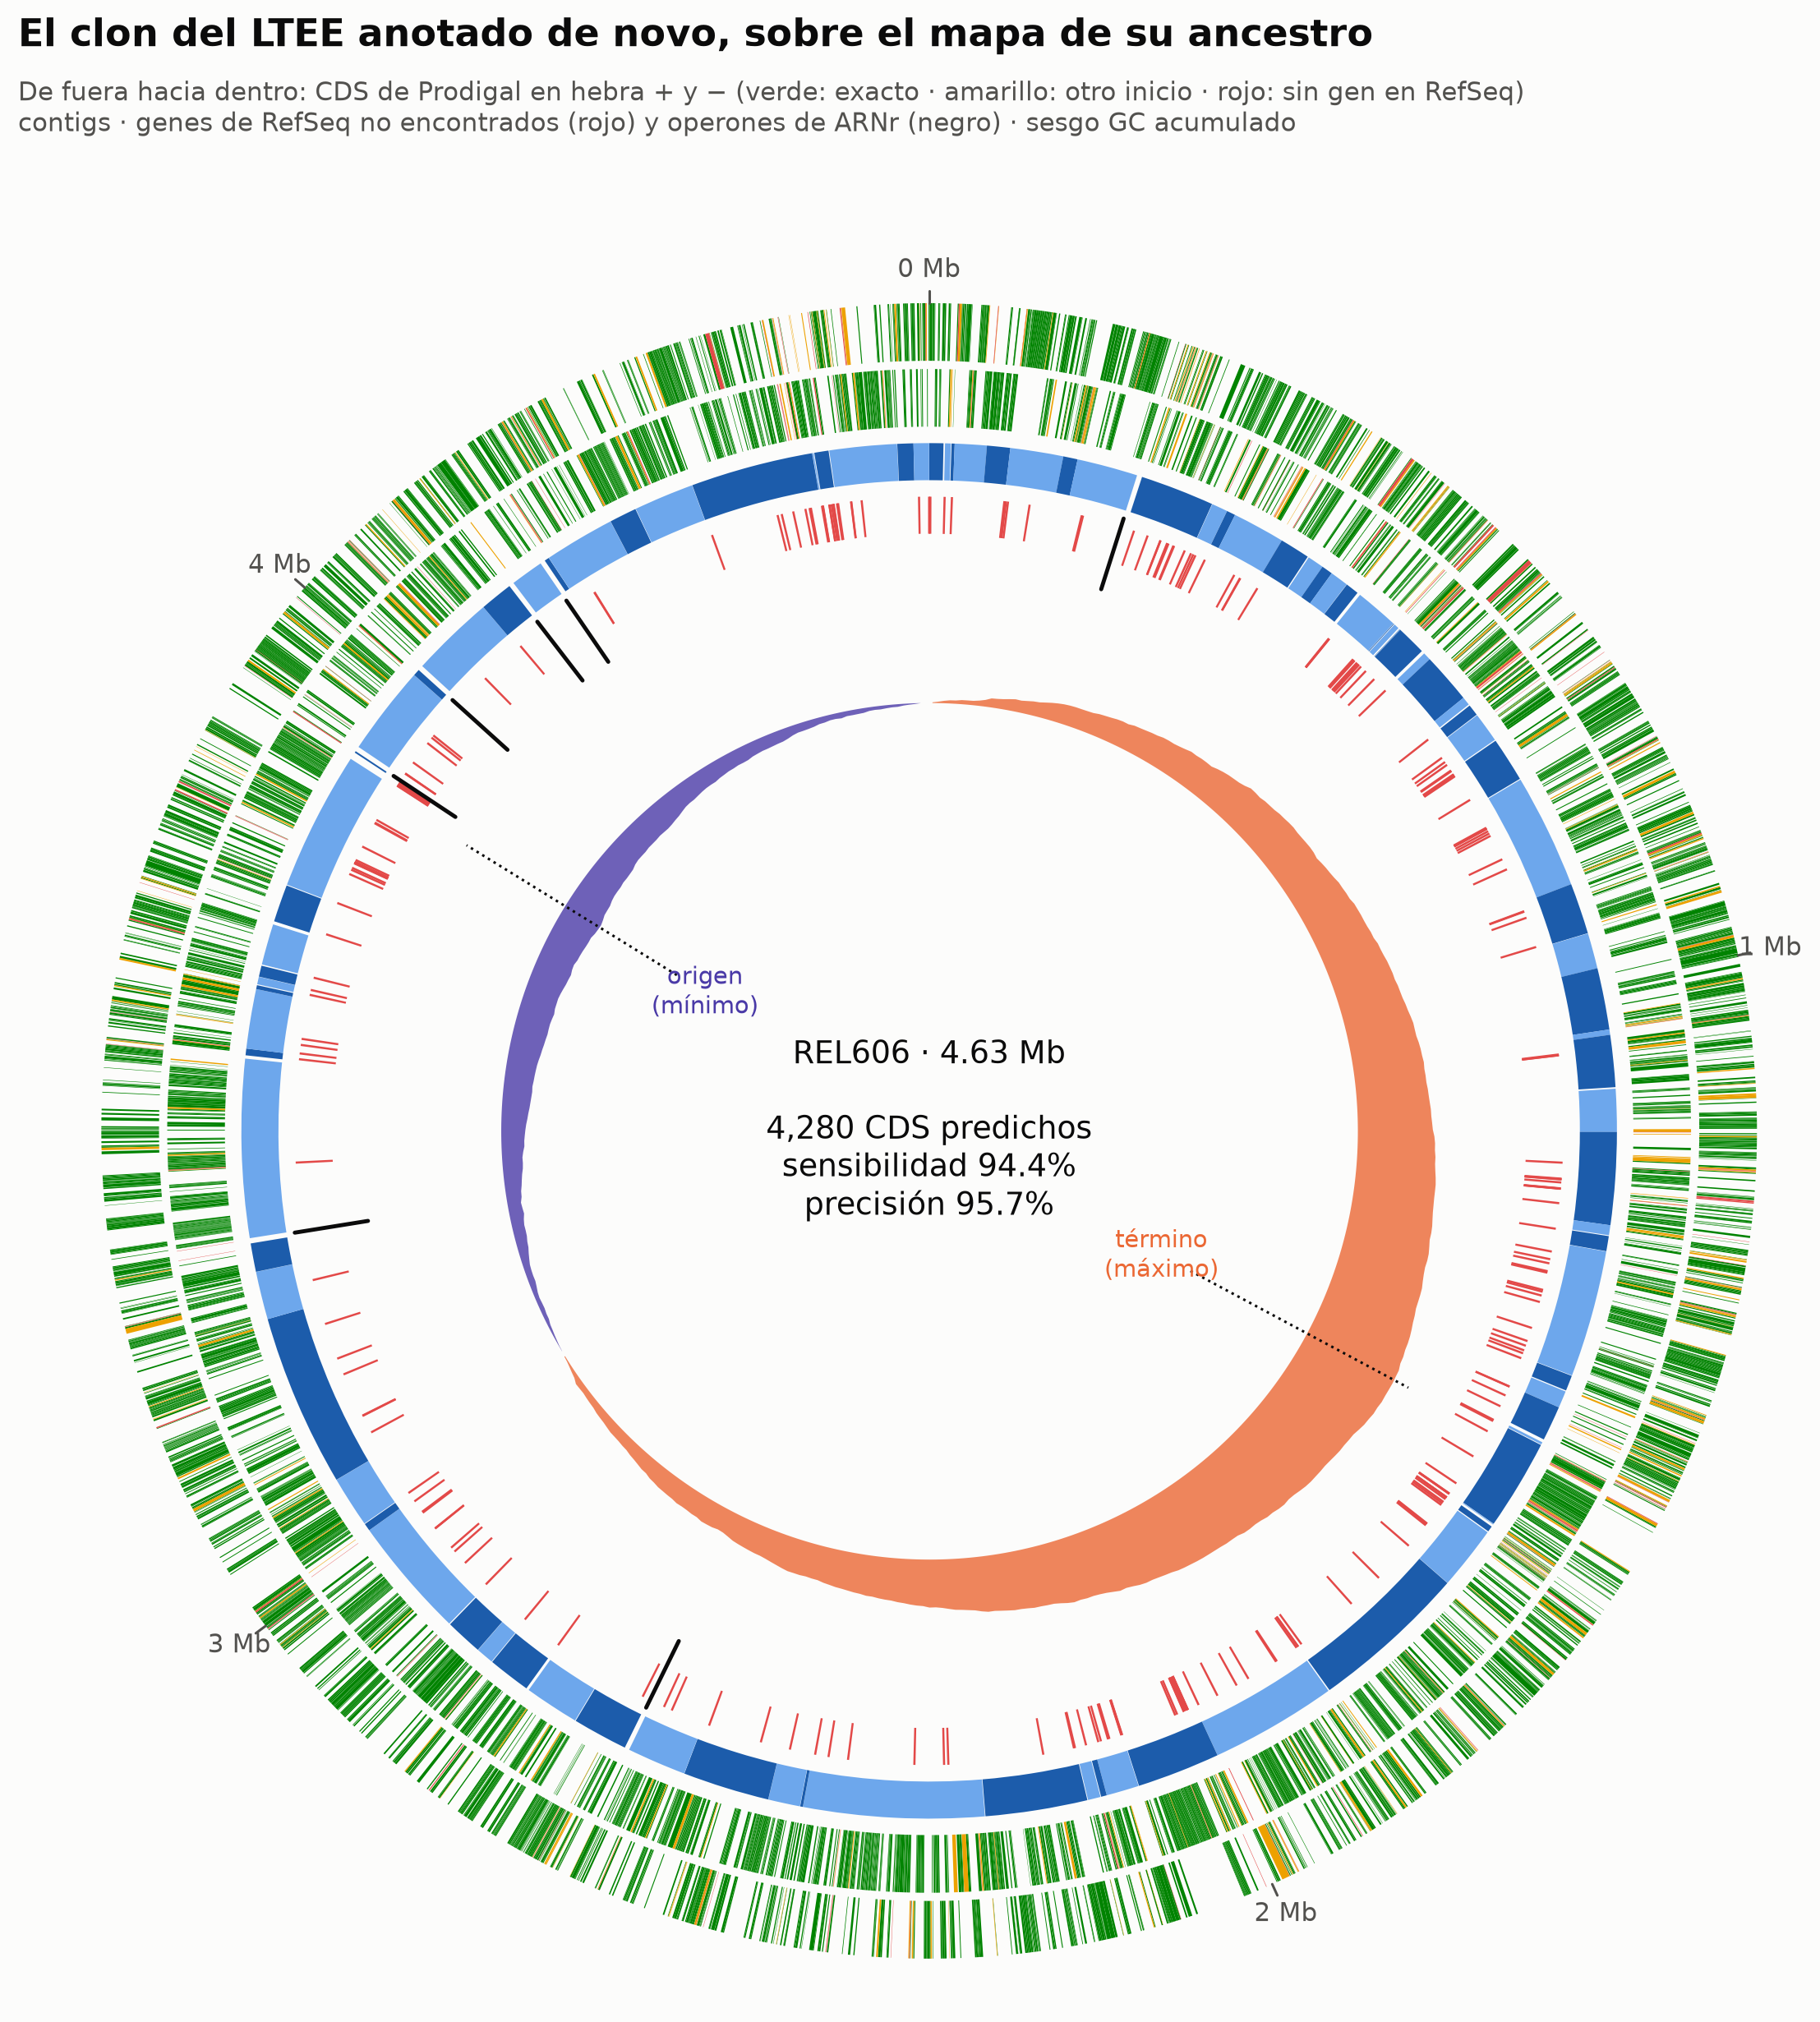

In [39]:
blk_by_ctg = {n: d.sort_values("q0") for n, d in blocks.groupby("contig")}
def to_ref_blocks(df):
    """Posición en REL606 de cada gen con el bloque de anclas de su contig que lo contiene (o el más cercano)."""
    lo_l, hi_l, st_l = [], [], []
    for r in df.itertuples():
        d = blk_by_ctg.get(r.contig)
        if d is None:
            lo_l.append(np.nan); hi_l.append(np.nan); st_l.append(0); continue
        mid = (r.begin + r.end) / 2
        b = d.iloc[int(np.argmin(np.where((d.q0 <= mid) & (mid <= d.q1), 0, np.minimum(abs(d.q0 - mid), abs(d.q1 - mid)))))]
        if b.strand == 1:
            lo, hi = b.diag + r.begin - 1, b.diag + r.end
        else:
            lo, hi = b.diag - r.end + KA, b.diag - r.begin + 1 + KA
        lo_l.append(lo % G_REF); hi_l.append(hi % G_REF); st_l.append(r.strand * b.strand)
    return np.array(lo_l), np.array(hi_l), np.array(st_l)

pred["status"] = status(pred)
g_lo, g_hi, g_st = to_ref_blocks(pred)
# Sesgo GC acumulado de REL606 en ventanas de 10 kb
win = 10_000
nwin = G_REF // win
gc_skew = np.array([(lambda w: (w.count("G") - w.count("C")) / max(1, w.count("G") + w.count("C")))(ref[i * win:(i + 1) * win])
                    for i in range(nwin)])
cum = np.cumsum(gc_skew - gc_skew.mean())
rrna_ref = feat[(feat.type == "rRNA") & feat["product"].str.contains("16S")]

fig = plt.figure(figsize=(10.5, 11.2))
ax = fig.add_axes([0.04, 0.0, 0.92, 0.87], projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_ylim(0, 10.6); ax.axis("off")
th = lambda p: 2 * np.pi * np.asarray(p) / G_REF
# Anillos 1 y 2: genes predichos por hebra
ok = ~np.isnan(g_lo)
for stt, colr in ST_COL.items():
    m = ok & (pred.status.values == stt)
    for strand, r0 in ((1, 9.35), (-1, 8.55)):
        mm = m & (g_st == strand)
        ax.bar(th(g_lo[mm]), 0.7, width=th(np.maximum(g_hi[mm] - g_lo[mm], 300)), bottom=r0, align="edge",
               color=colr, lw=0)
# Anillo 3: contigs (alternando tonos)
for k, r in enumerate(blocks.sort_values("r0").itertuples()):
    ax.bar(th(r.r0), 0.45, width=th(r.r1 - r.r0), bottom=7.9, align="edge",
           color=ec.SEQ_BLUE[4] if k % 2 else ec.SEQ_BLUE[9], lw=0)
# Anillo 4: genes perdidos y ARNr
ax.bar(th(missed.start.values), 0.45, width=th(np.full(len(missed), 2500)), bottom=7.25, align="edge",
       color=ec.RED, lw=0)
for r in rrna_ref.itertuples():
    ax.plot([th(r.start)] * 2, [6.9, 7.8], color=ec.INK, lw=1.6)
# Anillo 5: sesgo GC acumulado
thw = th((np.arange(nwin) + 0.5) * win)
cs = 1.2 * cum / np.abs(cum).max()
ax.fill_between(thw, 5.2, 5.2 + cs, where=cs >= 0, color=ec.ORANGE, alpha=0.8, lw=0)
ax.fill_between(thw, 5.2, 5.2 + cs, where=cs < 0, color=ec.VIOLET, alpha=0.8, lw=0)
for mb in range(0, 5):
    ax.text(th(mb * 1e6), 10.45, f"{mb} Mb", ha="center", va="center", fontsize=10, color=ec.INK_2)
    ax.plot([th(mb * 1e6)] * 2, [10.05, 10.2], color=ec.INK_2, lw=1)
ax.text(0, 0, f"REL606 · {G_REF / 1e6:.2f} Mb\n\n{len(pred):,} CDS predichos\n"
        f"sensibilidad {metrics.iloc[4, 0]:.1%}\nprecisión {metrics.iloc[2, 0]:.1%}", ha="center", va="center",
        fontsize=12.5, color=ec.INK)
# el sesgo GC acumulado es mínimo en el origen de replicación y máximo en el término
ax.plot([th(np.argmin(cum) * win)] * 2, [3.6, 6.6], color=ec.INK, lw=1, ls=":")
ax.plot([th(np.argmax(cum) * win)] * 2, [3.6, 6.6], color=ec.INK, lw=1, ls=":")
ax.text(th(np.argmin(cum) * win), 3.2, "origen\n(mínimo)", ha="center", va="center", fontsize=9.5, color=ec.VIOLET)
ax.text(th(np.argmax(cum) * win), 3.2, "término\n(máximo)", ha="center", va="center", fontsize=9.5, color=ec.ORANGE)
fig.text(0.02, 0.985, "El clon del LTEE anotado de novo, sobre el mapa de su ancestro", fontsize=15,
         fontweight="bold", va="top")
fig.text(0.02, 0.955, "De fuera hacia dentro: CDS de Prodigal en hebra + y − (verde: exacto · amarillo: otro inicio · "
         "rojo: sin gen en RefSeq)\ncontigs · genes de RefSeq no encontrados (rojo) y operones de ARNr (negro) · "
         "sesgo GC acumulado", fontsize=10, color=ec.INK_2, va="top")
plt.show()

> 🔎 **Qué observamos.** Los dos anillos exteriores son casi enteramente verdes: el genoma está densamente cubierto de
> genes en ambas hebras, con pocos amarillos (otro inicio) y rarísimos rojos. Los contigs (anillo azul) cubren casi
> todo el círculo; sus cortes coinciden a menudo con los operones de ARNr (negro) y con secuencias IS: las
> repeticiones fragmentan el ensamblaje. Los genes perdidos (rojo interior) están repartidos por todo el genoma, porque
> la mayoría son genes cortos o atípicos, no víctimas del ensamblaje. El sesgo GC acumulado (G − C en la hebra de
> referencia) baja hasta el **origen** de replicación y sube hasta el **término**, que quedan en lados opuestos del
> círculo: la huella de las dos horquillas de replicación (lección 1.3).

---

## ✍️ Ejercicios

**Ejercicio 1 (ORFs y composición).** Calcule $p$ y $\Pr(\text{ORF}\ge100)$ para un genoma con 30 % de GC y para uno
con 70 % de GC (suponga $f_A=f_T$ y $f_C=f_G$). ¿En cuál de los dos es más difícil predecir genes sólo por la
longitud? Compruébelo barajando una secuencia artificial de 1 Mb con cada composición.

**Ejercicio 2 (log-odds a mano).** Con la tabla `llr` autoentrenada, puntúe a mano y luego con `codon_score` los
fragmentos `CTG GAA AAA GCG` y `AGG AGA CGA CTA`. ¿Qué signo espera para cada uno?

**Ejercicio 3 (libro, adaptado).** Clasifique los ORFs de 60 a 149 codones de MG1655 como "gen" si su parada coincide
con la de un CDS de RefSeq (`cds_k12`). Compare el AUC del modelo de codones (ecuación 8.17, columna `S`) con el de
una cadena de Márkov de fase de orden 2 (ecuación 8.18) entrenada con los ORFs $\ge 300$ codones.

**Ejercicio 4 (Prodigal en modo metagenoma).** Anote los contigs de la región de 250 kb con
`pyrodigal.GeneFinder(meta=True)` (modelos precalculados, sin entrenamiento) y compare la sensibilidad y la exactitud
de inicios con el modelo entrenado en todo el ensamblaje. ¿Cuándo usaría el modo `meta`?

**Ejercicio 5 (el HMM y la longitud de los intrones).** En `gene_viterbi`, cambie la probabilidad de salir de un
intrón `p_acc` de $1/1500$ a $1/100$ y a $1/20\,000$. ¿Qué pasa con los exones de *TP53*? Relacione el resultado con la
distribución geométrica de longitudes que impone un HMM simple.

In [40]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
for gc in (0.3, 0.7):
    fa = ft = (1 - gc) / 2; fc = fg = gc / 2
    p = ft * fa * fa + ft * fa * fg + ft * fg * fa           # TAA, TAG, TGA
    arr = np.random.default_rng(0).choice(list("ACGT"), 1_000_000, p=[fa, fc, fg, ft])
    lens = find_orfs("".join(arr)).codons
    print(f"GC {gc:.0%}: p = {p:.4f} · P(ORF ≥ 100) = {(1 - p) ** 100:.2e} · ORFs ≥ 100 codones en 1 Mb al azar: "
          f"{(lens >= 100).sum()} · máximo {lens.max()}")
print("Con 70 % de GC las paradas son raras y el azar produce ORFs largos: la longitud discrimina mucho peor.")

GC 30%: p = 0.0796 · P(ORF ≥ 100) = 2.49e-04 · ORFs ≥ 100 codones en 1 Mb al azar: 9 · máximo 119
GC 70%: p = 0.0191 · P(ORF ≥ 100) = 1.45e-01 · ORFs ≥ 100 codones en 1 Mb al azar: 1724 · máximo 493
Con 70 % de GC las paradas son raras y el azar produce ORFs largos: la longitud discrimina mucho peor.


In [41]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for frag in ("CTGGAAAAAGCG", "AGGAGACGACTA"):
    s_, parts_ = codon_score(frag)
    print(f"{frag}: {parts_} → S = {s_:+.2f} bits/codón")
print("El primero reúne los codones favoritos de E. coli (positivo); el segundo, los más raros (muy negativo).")

CTGGAAAAAGCG: [1.76, 1.32, 1.09, 1.08] → S = +1.32 bits/codón
AGGAGACGACTA: [-3.79, -2.83, -2.26, -2.07] → S = -2.74 bits/codón
El primero reúne los codones favoritos de E. coli (positivo); el segundo, los más raros (muy negativo).


In [42]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
true_stops = set()
for r in cds_k12[cds_k12.type == "CDS"].itertuples():
    true_stops.add((1, r.end) if r.strand == "+" else (-1, G - r.start + 1))   # fin (exclusivo+3) en su hebra
sub = orf_real[(orf_real.codons >= 60) & (orf_real.codons < 150)].copy()
sub["is_gene"] = [(r.strand, r.end + 3) in true_stops for r in sub.itertuples()]
train_seqs = [orf_seq(eco_strands, r) for r in orf_real[orf_real.codons >= 300].itertuples()]
Pc2, Pn2 = train_phase_markov(train_seqs, 2), train_markov([eco], 2)
def llr_known_frame(s, m=2):
    x = encode(s); c = contexts(x, m); i = np.arange(m, len(x))
    return (Pc2[i % 3, c[m:], x[m:]] - Pn2[c[m:], x[m:]]).sum() / (len(s) / 3)
sub["M2"] = [llr_known_frame(orf_seq(eco_strands, r)) for r in sub.itertuples()]
for col in ("S", "M2"):
    f_, t_, _ = roc_curve(sub[col][sub.is_gene].values, sub[col][~sub.is_gene].values)
    print(f"{col}: AUC = {auc(f_, t_):.3f}  ({sub.is_gene.sum()} genes, {(~sub.is_gene).sum()} no genes)")

S: AUC = 0.899  (764 genes, 6619 no genes)
M2: AUC = 0.939  (764 genes, 6619 no genes)


In [43]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
meta = pyrodigal.GeneFinder(meta=True)
rows = []
for name, s in region_ctg.items():
    for g in meta.find_genes(s.encode()):
        endk = s[g.end - K:g.end] if g.strand == 1 else revcomp(s[g.begin - 1:g.begin - 1 + K])
        rows.append((endk, g.end - g.begin + 1, g.partial_begin or g.partial_end))
pm = pd.DataFrame(rows, columns=["endk", "length", "partial"])
for lab_, p in (("entrenado (genoma completo)", pred_reg), ("meta", pm)):
    found_ = truth_reg.endk.isin(set(p.endk))
    exact_ = np.mean([l in truth_len[k] for k, l in zip(p.endk, p.length) if k in truth_len])
    print(f"{lab_:28s}: {len(p)} genes · sensibilidad en la región {found_.mean():.1%} · "
          f"precisión {p.endk.isin(truth_len).mean():.1%} · inicios exactos {exact_:.1%}")
print("El modo meta sirve para secuencias cortas o mezclas de especies (metagenomas), donde no hay "
      "suficiente ADN de un solo organismo para entrenar.")

entrenado (genoma completo) : 226 genes · sensibilidad en la región 97.2% · precisión 93.8% · inicios exactos 91.0%
meta                        : 230 genes · sensibilidad en la región 97.2% · precisión 92.2% · inicios exactos 91.0%
El modo meta sirve para secuencias cortas o mezclas de especies (metagenomas), donde no hay suficiente ADN de un solo organismo para entrenar.


In [44]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
for pa in (1 / 100, 1 / 1500, 1 / 20_000):
    pth, _ = gene_viterbi(x_tp53, PE2, PI2, 2, DON, ACC, p_acc=pa)
    print(f"p_acc = 1/{1 / pa:,.0f}: ", score_pred(pth)[1])
print("Con p_acc alto el modelo espera intrones cortos y tiende a cortarlos antes de tiempo; con p_acc muy bajo los "
      "prefiere largos. Un HMM simple sólo puede expresar longitudes geométricas; un GHMM usa la distribución real.")

p_acc = 1/100:  {'Sn (bases)': 0.84, 'Sp (bases)': 0.819, 'exones exactos': '7/10', 'exones predichos': 11}
p_acc = 1/1,500:  {'Sn (bases)': 1.0, 'Sp (bases)': 0.885, 'exones exactos': '9/10', 'exones predichos': 11}
p_acc = 1/20,000:  {'Sn (bases)': 0.868, 'Sp (bases)': 0.87, 'exones exactos': '7/10', 'exones predichos': 10}
Con p_acc alto el modelo espera intrones cortos y tiende a cortarlos antes de tiempo; con p_acc muy bajo los prefiere largos. Un HMM simple sólo puede expresar longitudes geométricas; un GHMM usa la distribución real.


## 📌 Resumen

* **Anotar** es asignar estructura (dónde están genes, exones, ARN, repeticiones) y función (qué hacen). El resultado
  se guarda en GFF3 o GenBank.
* La longitud de un ORF casual es **geométrica**: $\Pr(\ge n) = (1-p)^n$, con $p = \sum f_x f_y f_z$ sobre las paradas.
  En *E. coli*, $p = 0{,}0456$; hay 5 983 ORFs reales de $\ge 100$ codones frente a unos 1 000 en el genoma barajado,
  y **ninguno** de $\ge 300$ codones por azar.
* El ADN codificante tiene "sabor": **uso de codones** (log-odds en bits por codón, ecuación 8.17) y **periodicidad de
  tres**. Los modelos se **autoentrenan** con los ORFs largos del propio genoma.
* Las **cadenas de Márkov de fase** (ecuación 8.18) de orden alto separan genes de intergénico (AUC 0,96) y, sobre
  todo, de su **hebra opuesta** (AUC de 0,63 con orden 0 a 0,91 con orden 5).
* **Prodigal** (vía `pyrodigal`) anotó el ensamblaje *de novo* del clon del LTEE en segundos: ~95 % de sensibilidad y
  de precisión por codón de parada, con ~92 % de inicios exactos. Los fallos se concentran en genes cortos o
  atípicos, en bordes de contigs y en repeticiones colapsadas. Un predictor mínimo de Márkov es preciso, pero pierde
  genes cortos y acierta muchos menos inicios.
* En eucariotas, un **HMM generalizado** con estados de exón por fase, tres estados de intrón y sensores de señal de
  empalme, decodificado con **Viterbi** (ecuación 8.19), cubrió los diez exones codificantes de *TP53* (nueve con límites exactos).
* Las repeticiones se **enmascaran** antes de predecir (DUST para baja complejidad, RepeatMasker para las dispersas);
  la evidencia de RNA-seq y proteínas entra como pistas (AUGUSTUS, BRAKER). **Prokka** y **Bakta** automatizan la
  anotación bacteriana completa.

## 📚 Para profundizar

* Borodovsky, M. & McIninch, J. (1993). GENMARK: parallel gene recognition for both DNA strands. *Computers &
  Chemistry* 17(2): 123–133.
* Lukashin, A. V. & Borodovsky, M. (1998). GeneMark.hmm: new solutions for gene finding. *Nucleic Acids Research*
  26(4): 1107–1115.
* Salzberg, S. L., Delcher, A. L., Kasif, S. & White, O. (1998). Microbial gene identification using interpolated
  Markov models. *Nucleic Acids Research* 26(2): 544–548.
* Delcher, A. L., Harmon, D., Kasif, S., White, O. & Salzberg, S. L. (1999). Improved microbial gene identification
  with GLIMMER. *Nucleic Acids Research* 27(23): 4636–4641.
* Delcher, A. L., Bratke, K. A., Powers, E. C. & Salzberg, S. L. (2007). Identifying bacterial genes and endosymbiont
  DNA with Glimmer. *Bioinformatics* 23(6): 673–679.
* Hyatt, D., Chen, G.-L., LoCascio, P. F., Land, M. L., Larimer, F. W. & Hauser, L. J. (2010). Prodigal: prokaryotic
  gene recognition and translation initiation site identification. *BMC Bioinformatics* 11: 119.
* Larralde, M. (2022). Pyrodigal: Python bindings and interface to Prodigal, an efficient method for gene prediction
  in prokaryotes. *Journal of Open Source Software* 7(72): 4296.
* Burge, C. & Karlin, S. (1997). Prediction of complete gene structures in human genomic DNA. *Journal of Molecular
  Biology* 268(1): 78–94.
* Stanke, M. & Waack, S. (2003). Gene prediction with a hidden Markov model and a new intron submodel.
  *Bioinformatics* 19(suppl 2): ii215–ii225.
* Brůna, T., Hoff, K. J., Lomsadze, A., Stanke, M. & Borodovsky, M. (2021). BRAKER2: automatic eukaryotic genome
  annotation with GeneMark-EP+ and AUGUSTUS supported by a protein database. *NAR Genomics and Bioinformatics* 3(1):
  lqaa108.
* Morgulis, A., Gertz, E. M., Schäffer, A. A. & Agarwala, R. (2006). A fast and symmetric DUST implementation to mask
  low-complexity DNA sequences. *Journal of Computational Biology* 13(5): 1028–1040.
* Tarailo-Graovac, M. & Chen, N. (2009). Using RepeatMasker to identify repetitive elements in genomic sequences.
  *Current Protocols in Bioinformatics* 25(1): 4.10.1–4.10.14.
* Yandell, M. & Ence, D. (2012). A beginner's guide to eukaryotic genome annotation. *Nature Reviews Genetics* 13(5):
  329–342.
* Seemann, T. (2014). Prokka: rapid prokaryotic genome annotation. *Bioinformatics* 30(14): 2068–2069.
* Schwengers, O., Jelonek, L., Dieckmann, M. A., Beyvers, S., Blom, J. & Goesmann, A. (2021). Bakta: rapid and
  standardized annotation of bacterial genomes via alignment-free sequence identification. *Microbial Genomics*
  7(11): 000685.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)